<div align="center">

**Федеральное государственное образовательное бюджетное учреждение высшего образования**<br>
**«Финансовый университет при Правительстве Российской Федерации»**

Факультет информационных технологий и анализа больших данных<br>
Кафедра искусственного интеллекта

Направление подготовки 01.03.02 «Прикладная математика и информатика» [УТОЧНИТЬ У РУКОВОДИТЕЛЯ: код и профиль]

# Разработка фреймворка генерации бенчмарков систем выявления концептуального дрейфа с автоматизированным формированием и параметризацией сценариев

**Выпускная квалификационная работа (коллективная)**

Выполнили студенты группы ПМ23-5:<br>
**Будаев Константин Владимирович**<br>
**Гарифзянов Тимур Русланович**

Научный руководитель:<br>
ассистент кафедры искусственного интеллекта **Окунева Эвелина Александровна**

Москва — 2027

</div>

## Аннотация

Работа посвящена генерации бенчмарков для систем выявления концептуального дрейфа (concept drift detection). Разработан фреймворк `scendrift`. В нём сценарий дрейфа — **формализованный объект**: кортеж параметров с ограничениями валидности. По сценарию автоматически строятся поток данных, истинная разметка дрейфа (ground truth) и протокол оценки детекторов.

Центральный результат — механизм **автоматического формирования и параметризации сценариев**. Он включает:
- единую калиброванную шкалу величины дрейфа;
- проверку и исправление сценариев;
- планы эксперимента над пространством параметров (сетка, случайная выборка, латинский гиперкуб, последовательности Соболя);
- шаблоны с наследованием и композицию.

Ноутбук одновременно является текстом работы и работающим фреймворком. Все результаты получены запуском кода сверху вниз.

> **Состояние ноутбука: этап 1 из 7.** Готовы: формальная модель сценария, архитектура, схема и валидация. Разделы следующих этапов помечены как ожидающие реализации.

## Оглавление

0. Введение: цель, задачи, актуальность, новизна, распределение ролей
1. Теоретическая часть: концептуальный дрейф, детекторы, бенчмарки, пробелы
2. Формальная модель сценария
3. Проектирование фреймворка
4. Реализация
5. Экспериментальное исследование
6. Тесты и воспроизводимость
7. Выводы, ограничения, направления развития
8. Список литературы

Пометки у разделов: **[К]** — Будаев К. В., **[Т]** — Гарифзянов Т. Р., **[К+Т]** — совместно.

## 0. Введение [К+Т]

### 0.1. Актуальность

Модели машинного обучения в эксплуатации работают с потоками данных, свойства которых меняются со временем:
- меняется поведение клиентов банка;
- появляются новые схемы мошенничества;
- меняются цены на рынке электроэнергии.

Такое изменение совместного распределения P(X, y) называют **концептуальным дрейфом** (concept drift) [1; 2]. Без своевременного обнаружения дрейфа качество модели падает незаметно, поэтому детекторы дрейфа — обязательная часть систем мониторинга моделей (MLOps).

Детекторов предложено много (DDM, EDDM, ADWIN, KSWIN, Page–Hinkley, HDDM и др.). Их сравнение по-прежнему опирается на ограниченный набор вручную составленных потоков (SEA, Agrawal, STAGGER, Hyperplane и др.) с несколькими фиксированными конфигурациями. Из-за этого нельзя систематически ответить на вопросы:
- при какой величине и скорости дрейфа детектор надёжно его обнаруживает;
- как на качество влияют шум, дисбаланс классов и доля затронутых признаков;
- где проходят границы области отказа детектора.

Для ответа нужен инструмент, который **формирует сценарии автоматически**, причём параметры сценария имеют проверяемый смысл.

### 0.2. Цель и задачи

**Цель работы** — разработать фреймворк генерации бенчмарков систем выявления концептуального дрейфа. Сценарий дрейфа в нём задаётся формализованным набором параметров, а наборы сценариев формируются автоматически.

**Задачи:**

1. Проанализировать виды концептуального дрейфа, методы его обнаружения и существующие бенчмарки и генераторы потоков; выявить их ограничения.
2. Построить формальную модель сценария дрейфа: пространство параметров, единую шкалу величины дрейфа, ограничения валидности.
3. Спроектировать архитектуру фреймворка и декларативный формат описания сценариев.
4. Реализовать генераторы потоков с контролируемым дрейфом и автоматическим построением ground truth.
5. Реализовать модуль автоматического формирования и параметризации сценариев.
6. Реализовать единый интерфейс детекторов, раннер бенчмарка, модуль метрик и статистического сравнения, отчёты.
7. Провести экспериментальное исследование: проверить генератор, сравнить детекторы на сформированных наборах, проанализировать чувствительность к параметрам сценария.

**Объект исследования** — методы выявления концептуального дрейфа в потоках данных.

**Предмет исследования** — методы и программные средства формирования параметризованных сценариев дрейфа для сравнительной оценки детекторов.

### 0.3. Научная новизна и практическая значимость

> Формулировки предварительные. Их уточняют по итогам обзора аналогов (раздел 1.4–1.5) и экспериментов.

Собственный вклад авторов:

1. **Формальная модель сценария дрейфа.** Сценарий задан как кортеж S = ⟨B, E, Ω, s⟩ с явными ограничениями валидности. Структурная случайность (геометрия концептов) отделена от случайности реализации (выборка данных).
2. **Единая калиброванная шкала величины дрейфа** для трёх видов дрейфа: real, virtual, prior. Для реального дрейфа дана аналитическая калибровка угла поворота с учётом дисбаланса классов и доли затронутых признаков. Из неё выведены ограничения достижимости величины.
3. **Механизм автоматического формирования наборов сценариев** с проверкой и исправлением сценариев (этап 3).
4. **Методика анализа областей отказа детекторов** в пространстве параметров сценария (этап 5).

Взято из существующих решений (с указанием источников в тексте):
- детекторы и базовая модель — библиотека river [3];
- определение severity — Minku et al. [4];
- метрики MTD/MDR/MTFA/MTR — CD-MOA [5];
- статистические тесты — по Demšar [6];
- планы LHS и Соболя — `scipy.stats.qmc`.

**Практическая значимость:**
- фреймворк можно использовать для выбора детектора под характеристики конкретной задачи;
- им можно проверять новые детекторы;
- декларативные сценарии и идентификация по содержимому обеспечивают воспроизводимость бенчмарков.

### 0.4. Распределение ролей (коллективная ВКР)

| Зона | **Будаев К. В.** — сценарии и данные | **Гарифзянов Т. Р.** — оценка и анализ |
|---|---|---|
| Теория (раздел 1) | 1.1–1.2: дрейф, таксономия, генераторы | 1.3–1.4: детекторы, бенчмарки, метрики |
| Модель (раздел 2) | 2.1–2.5: сценарий, величина, пространство, ограничения | 2.6: протокол оценки и формализация метрик |
| Код | `scendrift/scenario/`, `generators/`, `formation/` | `scendrift/evaluation/`, `detectors/`, `reporting/` |
| Эксперименты | Э1 (валидация генератора), Э7 (реальные данные) | Э2, Э3, Э5, Э6, Э8 (бенчмарк, чувствительность, статистика) |
| Совместно | 0, 1.5, 3 (архитектура), Э4 (шкала сложности), 7 | |

Ответственный указан в docstring каждого модуля и в заголовке каждого раздела ноутбука.

### 0.5. Окружение и воспроизводимость

Ячейка ниже делает четыре вещи:
- фиксирует режим запуска `MODE`: `FAST` — быстрый прогон за минуты, `FULL` — полный эксперимент на сервере;
- задаёт глобальный seed;
- создаёт структуру каталогов пакета;
- выводит версии библиотек.

В чистом окружении (например, Google Colab) недостающие библиотеки устанавливаются автоматически с версиями из `requirements.txt`.

In [1]:
import importlib
import importlib.metadata as md
import os
import platform
import subprocess
import sys
from pathlib import Path

MODE = os.environ.get("SCENDRIFT_MODE", "FAST")  # "FAST" или "FULL"
GLOBAL_SEED = 2027

REQUIRED = {
    "numpy": "2.4.6", "scipy": "1.17.1", "pandas": "3.0.6", "matplotlib": "3.11.2",
    "pydantic": "2.13.4", "PyYAML": "6.0.1", "river": "0.26.1", "joblib": "1.6.0",
    "scikit-learn": "1.9.1", "tabulate": "0.10.0", "pytest": "9.1.1",
}
missing = []
for package in REQUIRED:
    try:
        md.version(package)
    except md.PackageNotFoundError:
        missing.append(f"{package}=={REQUIRED[package]}")
if missing:  # чистое окружение (например, Colab)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

for folder in ["scendrift/scenario", "scendrift/evaluation", "scendrift/generators",
               "scendrift/formation", "scendrift/detectors", "scendrift/reporting",
               "configs/examples", "configs/schema", "tests", "tools", "docs/figures",
               "results"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

print(f"Python {platform.python_version()} · {platform.system()} · режим {MODE} · seed {GLOBAL_SEED}")
for package, pinned in REQUIRED.items():
    installed = md.version(package)
    mark = "" if installed == pinned else f"  (зафиксировано {pinned})"
    print(f"  {package:<13} {installed}{mark}")

Python 3.11.15 · Linux · режим FAST · seed 2027
  numpy         2.4.6
  scipy         1.17.1
  pandas        3.0.6
  matplotlib    3.11.2
  pydantic      2.13.4
  PyYAML        6.0.1
  river         0.26.1
  joblib        1.6.0
  scikit-learn  1.9.1
  tabulate      0.10.0
  pytest        9.1.1


### 0.6. Корень пакета и единый стиль графиков [Т]

Код фреймворка оформлен как пакет `scendrift`. В ноутбуке каждый модуль создаётся ячейкой `%%writefile` в том разделе, где он описан. Корневой модуль ничего не импортирует заранее, поэтому пакет можно собирать раздел за разделом.

Модуль `reporting/style` задаёт оформление всех графиков работы:
- фиксированный порядок категориальных цветов, проверенный на различимость при дальтонизме;
- тонкие линии и ненавязчивая сетка;
- подписи на русском языке.

In [2]:
%%writefile scendrift/__init__.py
"""scendrift — фреймворк генерации бенчмарков систем выявления концептуального дрейфа.

Сценарий дрейфа — формализованный объект S = ⟨B, E, Ω, s⟩: базовая
конфигурация потока, события дрейфа, протокол оценки и seed. Фреймворк
строит по сценарию поток данных с ground truth, автоматически формирует
наборы сценариев и оценивает детекторы дрейфа.

Авторы: Будаев К. В. (сценарии и данные), Гарифзянов Т. Р. (оценка и анализ).

Подпакеты импортируются явно, например ``from scendrift.scenario import ScenarioSpec``:
корневой модуль ничего не загружает заранее, поэтому ноутбук может
создавать пакет по частям, раздел за разделом.
"""

__version__ = "0.1.0"

__all__ = ["__version__"]

Overwriting scendrift/__init__.py


In [3]:
%%writefile scendrift/reporting/__init__.py
"""Отчёты: таблицы, графики, экспорт (этап 4).

Ответственный: Гарифзянов Т. Р.
"""

Overwriting scendrift/reporting/__init__.py


In [4]:
%%writefile scendrift/reporting/style.py
"""Единый стиль графиков ноутбука, записки и презентации.

Ответственный: Гарифзянов Т. Р.

Категориальная палитра — первые слоты проверенной эталонной палитры.
Три первых цвета различимы при всех типах дальтонизма даже при попарном
сравнении всех серий. Поэтому на точечных графиках и малых мультипликаторах
используется не больше трёх серий, а на линейных графиках (сравниваются
соседние серии) — до восьми. Порядок слотов фиксирован: цвет закреплён
за сущностью (например, за детектором), а не за её рангом.
"""

from __future__ import annotations

from collections.abc import Sequence

import matplotlib as mpl
from matplotlib.ticker import FuncFormatter

__all__ = [
    "CATEGORICAL",
    "SEQUENTIAL",
    "DIVERGING",
    "TEXT",
    "TEXT_SECONDARY",
    "GRID",
    "SURFACE",
    "apply_style",
    "color_map",
    "decimal_comma",
]

#: Категориальные цвета (светлая тема), фиксированный порядок слотов.
CATEGORICAL: tuple[str, ...] = (
    "#2a78d6",  # 1 синий
    "#eb6834",  # 2 оранжевый
    "#1baf7a",  # 3 аква
    "#eda100",  # 4 жёлтый
    "#e87ba4",  # 5 пурпурный
    "#008300",  # 6 зелёный
    "#4a3aa7",  # 7 фиолетовый
    "#e34948",  # 8 красный
)

#: Последовательная шкала (один тон, от светлого к тёмному) — тепловые карты.
SEQUENTIAL: tuple[str, ...] = (
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
    "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b",
)

#: Расходящаяся шкала: синий ↔ серый ↔ красный.
DIVERGING: tuple[str, str, str] = ("#2a78d6", "#f0efec", "#e34948")

TEXT = "#0b0b0b"
TEXT_SECONDARY = "#52514e"
GRID = "#e4e3df"
SURFACE = "#ffffff"


def apply_style(font_size: float = 10.5) -> None:
    """Устанавливает параметры matplotlib: тонкие линии, ненавязчивая сетка."""
    mpl.rcParams.update(
        {
            "figure.facecolor": SURFACE,
            "axes.facecolor": SURFACE,
            "axes.edgecolor": TEXT_SECONDARY,
            "axes.labelcolor": TEXT,
            "axes.titlecolor": TEXT,
            "axes.titlesize": font_size + 1.5,
            "axes.titleweight": "bold",
            "axes.labelsize": font_size,
            "axes.grid": True,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.prop_cycle": mpl.cycler(color=list(CATEGORICAL)),
            "grid.color": GRID,
            "grid.linewidth": 0.8,
            "xtick.color": TEXT_SECONDARY,
            "ytick.color": TEXT_SECONDARY,
            "font.size": font_size,
            "legend.frameon": False,
            "lines.linewidth": 2.0,
            "lines.markersize": 6.0,
            "savefig.dpi": 200,
            "savefig.bbox": "tight",
            "figure.dpi": 110,
        }
    )


def color_map(names: Sequence[str]) -> dict[str, str]:
    """Закрепляет цвета за именами в заданном порядке (не по рангу).

    Raises:
        ValueError: если имён больше, чем цветов в палитре.
    """
    if len(names) > len(CATEGORICAL):
        raise ValueError("больше восьми серий: объедините лишние в «прочие» или разбейте график")
    return dict(zip(names, CATEGORICAL, strict=False))


def _comma(value: float, _pos: int | None = None) -> str:
    text = f"{value:.10g}"
    return text.replace(".", ",").replace("-", "−")


def decimal_comma(*axes: mpl.axes.Axes) -> None:
    """Подписи делений осей с десятичной запятой (ГОСТ 7.32)."""
    for ax in axes:
        ax.xaxis.set_major_formatter(FuncFormatter(_comma))
        ax.yaxis.set_major_formatter(FuncFormatter(_comma))

Overwriting scendrift/reporting/style.py


## 1. Теоретическая часть

### 1.1. Потоки данных и концептуальный дрейф [К]

**Поток данных** (data stream) — потенциально неограниченная последовательность объектов, поступающих во времени [1; 7]. Модель на потоке должна:
- обрабатывать каждый объект один раз;
- работать в ограниченной памяти;
- выдавать прогноз в любой момент;
- **адаптироваться к изменениям**.

Последнее требование связано с **концептуальным дрейфом** — изменением распределения $P_t(X, y)$ с течением времени [1; 2; 8].

Причины дрейфа в прикладных задачах:
- изменение поведения клиентов (сезонность, кризисы, новые продукты);
- адаптация злоумышленников к антифрод-системам;
- смена регламентов и рыночных условий.

Классический пример — набор Electricity (Elec2): цены на электроэнергию в Новом Южном Уэльсе, где правила рынка менялись со временем [9].

Работа с дрейфом включает две задачи [1; 2]:
1. **обнаружение** (detection) — установить, что распределение изменилось, и указать момент изменения;
2. **адаптацию** (adaptation) — обновить модель.

Данная работа касается первой задачи, точнее — **оценки** методов её решения. Детекторы бывают:
- **с учителем** — отслеживают поток ошибок классификатора, поэтому им нужны истинные метки;
- **без учителя** — отслеживают распределение признаков [10; 11].

Основной протокол работы — детекторы с учителем: именно они реализованы в river и обычно сравниваются в литературе [12; 13].

### 1.2. Таксономия концептуального дрейфа [К]

Дрейф классифицируют по нескольким независимым признакам [1; 14; 4].

**По источнику изменения** [15; 1]. Совместное распределение раскладывается как $P(X, y) = P(X)P(y \mid X) = P(y)P(X \mid y)$. В зависимости от того, какая компонента меняется, различают:
* **реальный дрейф** (real concept drift, concept shift) — меняется $P(y \mid X)$: при тех же признаках правильный ответ другой. Такой дрейф всегда ухудшает модель;
* **виртуальный дрейф** (virtual drift, covariate shift) — меняется $P(X)$ при неизменной $P(y \mid X)$. Модель может не пострадать, но и такой дрейф важно обнаруживать: он означает, что модель работает на непривычных данных;
* **дрейф априорных вероятностей** (prior probability shift, label shift) — меняется $P(y)$ при неизменной $P(X \mid y)$. Типичный пример — рост доли мошеннических операций.

**По форме во времени** [1; 14]:
* **внезапный** (sudden, abrupt) — концепт сменяется мгновенно;
* **постепенный** (gradual) — какое-то время объекты приходят то из старого, то из нового концепта, и доля нового растёт;
* **инкрементальный** (incremental) — концепт меняется непрерывно, через последовательность промежуточных концептов;
* **повторяющийся** (recurring, reoccurring concepts) — поток возвращается к ранее встречавшемуся концепту, например по сезонам.

**По величине и скорости.** Minku, White и Yao [4] ввели две характеристики:
- **severity** — «объём изменений», вызванных новым концептом; измеряется, в частности, долей входного пространства, в которой меняется класс;
- **speed** — величина, обратная времени полного замещения старого концепта новым.

Webb и соавторы [14] формализовали **magnitude** (расстояние между распределениями) и **duration** дрейфа.

**По охвату:**
- **глобальный** дрейф затрагивает всё пространство признаков;
- **локальный** — его часть, например подмножество признаков или область пространства.

Модель сценария (раздел 2) задаёт эти оси как **независимые параметры**:
- вид $\kappa$ — источник изменения;
- форма $\varphi$ и ссылка возврата $\rho$ — форма во времени;
- величина $m$ — severity на единой шкале;
- ширина $w$ — длительность, обратная скорости;
- доля признаков $\alpha$ — охват.

Рисунок ниже иллюстрирует формы дрейфа во времени, по аналогии со схемой из обзора [1]: по вертикали отложено «положение» концепта.

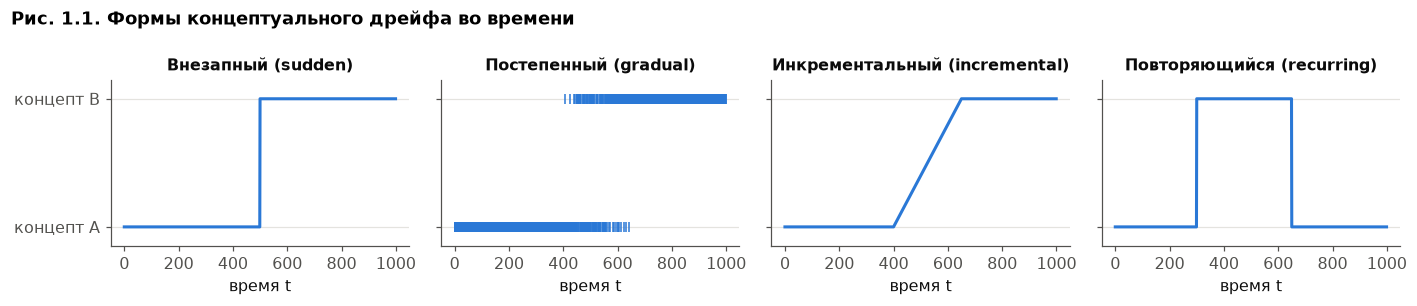

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from scendrift.reporting.style import CATEGORICAL, apply_style

apply_style()
t = np.arange(1000)
illus_rng = np.random.default_rng(GLOBAL_SEED)
ramp = np.clip((t - 400) / 250, 0, 1)
panels = {
    "Внезапный (sudden)": (t >= 500).astype(float),
    "Постепенный (gradual)": (illus_rng.random(t.size) < ramp).astype(float),
    "Инкрементальный (incremental)": ramp,
    "Повторяющийся (recurring)": ((t >= 300) & (t < 650)).astype(float),
}
fig, axes = plt.subplots(1, 4, figsize=(13, 2.8), sharey=True)
for ax, (title, signal) in zip(axes, panels.items()):
    style = {"linestyle": "none", "marker": "|", "markersize": 6} if "gradual" in title else {}
    ax.plot(t, signal, color=CATEGORICAL[0], **style)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel("время t")
    ax.set_yticks([0, 1], ["концепт A", "концепт B"])
    ax.set_ylim(-0.15, 1.15)
    ax.grid(axis="x", visible=False)
fig.suptitle("Рис. 1.1. Формы концептуального дрейфа во времени", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("docs/figures/fig_1_1_drift_forms.png")
plt.show()

### 1.3. Методы обнаружения дрейфа [Т]

Детекторы с учителем получают поток индикаторов ошибки $e_t = \mathbb{1}[\hat y_t \neq y_t]$ базового классификатора и сигнализируют о существенном росте ошибки [1; 2]. Семь детекторов, сравниваемых в работе, относятся к трём группам.

**1. Статистический контроль частоты ошибок.**
* **DDM** (Drift Detection Method) [16] моделирует число ошибок биномиальным законом. Он отслеживает минимум величины $p_t + s_t$, где $p_t$ — частота ошибок, $s_t = \sqrt{p_t(1 - p_t)/t}$. Предупреждение выдаётся при $p_t + s_t \ge p_{\min} + 2s_{\min}$, дрейф — при $p_t + s_t \ge p_{\min} + 3s_{\min}$.
* **EDDM** (Early DDM) [17] отслеживает расстояние между соседними ошибками. Это повышает чувствительность к медленному, постепенному дрейфу.
* **HDDM_A** и **HDDM_W** [18] сравнивают средние на двух участках потока, используя неравенство Хёффдинга. Вариант A сравнивает обычные средние, вариант W — экспоненциально взвешенные. Оценка не требует предположений о распределении.

**2. Адаптивные окна и сравнение распределений.**
* **ADWIN** (ADaptive WINdowing) [19] хранит окно переменной длины. Если найдено разбиение окна на две части со статистически различными средними (граница Хёффдинга с уровнем $\delta$), устаревшая часть отбрасывается. Даёт гарантии на долю ложных срабатываний и на задержку обнаружения.
* **KSWIN** (Kolmogorov–Smirnov WINdowing) [20] сравнивает критерием Колмогорова–Смирнова последние $r$ значений со случайной выборкой из более раннего окна.

**3. Последовательный анализ.**
* **Page–Hinkley** [21] — вариант кумулятивных сумм (CUSUM). Накапливается отклонение значений от их среднего с допуском $\delta$, и дрейф фиксируется, когда накопленная сумма превышает порог $\lambda$.

Гиперпараметры по умолчанию в river 0.26.1 [3] (используются в основном эксперименте):

| Детектор | Группа | Вход | Гиперпараметры по умолчанию (river 0.26.1) | Источник |
|---|---|---|---|---|
| ADWIN | окно | вещественный | `delta=0.002`, `clock=32`, `grace_period=10` | [19] |
| DDM | контроль ошибок | бинарный | `warm_start=30`, `warning_threshold=2.0`, `drift_threshold=3.0` | [16] |
| EDDM | контроль ошибок | бинарный | `warm_start=30`, `alpha=0.95`, `beta=0.9` | [17] |
| KSWIN | окно | вещественный | `alpha=0.005`, `window_size=100`, `stat_size=30` | [20] |
| Page–Hinkley | последов. анализ | вещественный | `min_instances=30`, `delta=0.005`, `threshold=50`, `alpha=0.9999` | [21] |
| HDDM_A | контроль ошибок | ограниченный | `drift_confidence=0.001`, `warning_confidence=0.005` | [18] |
| HDDM_W | контроль ошибок | ограниченный | `drift_confidence=0.001`, `warning_confidence=0.005`, `lambda_val=0.05` | [18] |

Известно, что результаты сравнения детекторов существенно зависят от свойств тестовых потоков и от протокола оценки [12; 13; 22]. В частности:
- Barros и Santos сравнили 14 детекторов на большом числе вручную сконфигурированных синтетических потоков [12];
- Bifet показал, что популярный протокол «accuracy при перезапуске классификатора» может создавать «иллюзию прогресса» [22].

Для оценки качества обнаружения относительно истинных моментов изменения в CD-MOA предложены метрики [5]:
- MTFA — среднее время между ложными тревогами;
- MTD — среднее время до обнаружения;
- MDR — доля пропущенных изменений;
- MTR — их сводное отношение.

Эти наблюдения мотивируют главное требование к бенчмарку: систематически варьировать свойства сценария и знать истинную разметку.

### 1.4. Бенчмарки и генераторы потоков с дрейфом [Т]

> Раздел дополняется по итогам анализа аналогов (см. ниже).

### 1.5. Анализ пробелов и постановка задачи [К+Т]

> Раздел дополняется по итогам анализа аналогов.

## 2. Формальная модель сценария [К] (п. 2.6 — [Т])

В разделе вводится формальное определение сценария дрейфа. Задаются семантика его параметров, пространство параметров, таксономия и ограничения валидности. Протокол оценки и метрики формализованы в п. 2.6. Утверждения раздела проверяются численно методом Монте-Карло. Проверочные ячейки используют только numpy и scipy и не зависят от реализации фреймворка из раздела 4, поэтому служат независимой проверкой формул.

### 2.1. Поток данных и концептуальный дрейф

**Поток данных** — последовательность $(x_t, y_t)$, $t = 1, \dots, n$, где $x_t \in \mathbb{R}^d$, $y_t \in \{0, 1\}$, а пара $(x_t, y_t)$ порождается распределением $P_t(X, y)$.

**Концепт** — совместное распределение $P_t(X, y)$ [1]. **Концептуальный дрейф** между моментами $t$ и $u$ — неравенство $P_t(X, y) \neq P_u(X, y)$.

Используются два разложения совместного распределения:
$$P(X, y) = P(X)\,P(y \mid X) = P(y)\,P(X \mid y).$$
От того, какая компонента меняется, зависит вид дрейфа [15; 14]:
- реальный дрейф (real) — меняется $P(y \mid X)$;
- виртуальный (virtual, covariate shift) — меняется только $P(X)$;
- дрейф априорных вероятностей (prior, label shift) — меняется $P(y)$ при неизменном $P(X \mid y)$.

### 2.2. Определение сценария

**Определение 1 (сценарий дрейфа).** Сценарий — кортеж
$$S = \langle B, E, \Omega, s \rangle,$$
где:

* $B = (f, n, d, \pi_0, \eta, c)$ — базовая конфигурация потока:
  - $f$ — семейство генератора;
  - $n$ — длина потока;
  - $d$ — размерность;
  - $\pi_0 \in [0{,}01;\,0{,}5]$ — исходная доля положительного (миноритарного) класса;
  - $\eta \in [0;\,0{,}5)$ — вероятность инверсии метки;
  - $c$ — **структурный seed**.
* $E = (e_1, \dots, e_K)$ — упорядоченный список событий дрейфа. Событие $e_k = (\tau_k, w_k, \varphi_k, \kappa_k, m_k, \alpha_k, \rho_k)$:
  - $\tau_k$ — центр перехода;
  - $w_k$ — ширина перехода;
  - $\varphi_k \in \{\text{sudden}, \text{gradual}, \text{incremental}\}$ — форма перехода;
  - $\kappa_k \in \{\text{real}, \text{virtual}, \text{prior}\}$ — вид;
  - $m_k \in (0, 1]$ — величина;
  - $\alpha_k \in (0, 1]$ — доля затронутых признаков;
  - $\rho_k$ — номер концепта, к которому поток возвращается (повторяющийся дрейф).
* $\Omega$ — протокол оценки (п. 2.6).
* $s$ — **seed реализации**.

Интервал перехода события — полуинтервал $[\mathrm{onset}_k, \mathrm{end}_k)$, где $\mathrm{onset}_k = \tau_k - \lfloor w_k/2 \rfloor$ и $\mathrm{end}_k = \mathrm{onset}_k + w_k$. Положение объекта внутри перехода задаёт функция перехода $p_k(t)$: она растёт от 0 до 1, бывает линейной или сигмоидной.

Формы перехода различаются так:
- **внезапный** дрейф (sudden, $w_k = 0$) — концепт меняется мгновенно;
- **постепенный** (gradual) — объект порождается новым концептом с вероятностью $p_k(t)$, иначе старым;
- **инкрементальный** (incremental) — параметры концепта непрерывно интерполируются, $\theta(t) = p_k(t)\,\theta_k$.

**Повторяющийся** дрейф (recurring) не считается отдельной формой. Это событие с заданным $\rho_k$, то есть возврат к ранее встречавшемуся концепту, а сам возврат может быть внезапным или постепенным. Так виды дрейфа во времени [1] раскладываются на две независимые оси: форма перехода и повторяемость.

**Определение 2 (генератор).** Генератор семейства $f$ — детерминированное отображение
$$\Gamma_f : (S, s) \mapsto (X_{1..n},\ y_{1..n},\ G),$$
где $G$ — истинная разметка дрейфа (ground truth, п. 2.5).

**Два seed вместо одного.** Структурный seed $c$ задаёт геометрию концептов: какие признаки затронуты, направления поворота и сдвига, случайное расписание. Seed реализации $s$ задаёт выборку объектов и шум. Отсюда два следствия:
1. повторы сценария с разными $s$ имеют одни и те же концепты, а значит, одну и ту же истинную величину дрейфа;
2. проверку допустимости можно выполнить заранее, не порождая данных.

### 2.3. Семантика величины дрейфа: единая шкала

Параметр «величина дрейфа» в существующих генераторах обычно не имеет общей семантики. Это число функций, сдвинутых в SEA или Agrawal, скорость вращения гиперплоскости [23] или иной внутренний параметр генератора. Поэтому нельзя сказать, что дрейф величины 0,2 в одном потоке «такой же», как в другом. Ниже величина определяется через измеримое расстояние между концептами и калибруется аналитически.

**Семейство `hyperplane_gauss`.** Концепт $k$ задаётся состоянием $(w_k, \mu_k, \pi_k)$:
- $w_k$ — единичная нормаль, $\|w_k\| = 1$;
- $\mu_k$ — центр распределения признаков $\mathcal{N}(\mu_k, I)$;
- $\pi_k$ — текущая доля положительного класса.

Метка задаётся правилом
$$c_k(x) = \mathbb{1}\left[w_k^\top (x - \mu_k) > z\right], \qquad z = \Phi^{-1}(1 - \pi_0).$$
Объекты порождаются по схеме label shift: сначала $y \sim \mathrm{Bernoulli}(\pi_k)$, затем $x \mid y$ из $\mathcal{N}(\mu_k, I)$, усечённого на полупространство класса $y$. Затем метка с вероятностью $\eta$ инвертируется. В исходном концепте $w_0 = \mathbf{1}/\sqrt{d}$ (все признаки одинаково информативны), $\mu_0 = 0$.

Каждый вид дрейфа меняет **ровно одну** компоненту распределения $P(X, y)$:

| Вид | Преобразование | Меняется | Сохраняется |
|---|---|---|---|
| real | поворот $w$ внутри подпространства затронутых признаков $A$ | $P(y \mid X)$ | $P(X)$, $P(y)$ |
| virtual | сдвиг $\mu \to \mu + \delta v$, $v \perp w$, $\operatorname{supp} v \subseteq A$ | $P(X)$ | $P(y \mid X)$, $P(y)$ |
| prior | $\pi_k \to \pi_{k+1}$ | $P(y)$ | $P(X \mid y)$, $P(y \mid X)$ |

**Определение 3 (величина реального дрейфа, severity).** Величина реального дрейфа — доля входного пространства, на которой меняется метка [4]:
$$m_{\text{real}} = P_{x \sim P_k(X)}\big(c_k(x) \neq c_{k+1}(x)\big).$$

**Утверждение 1.** При $\pi_0 = \pi_k = 1/2$ и повороте нормали на угол $\theta$ выполняется $m_{\text{real}} = \theta/\pi$.

*Набросок доказательства.* Метки зависят только от проекции $x$ на плоскость, натянутую на $w_k$ и $w_{k+1}$. Эта проекция — изотропная двумерная гауссиана. Области несовпадения меток — два угла раствора $\theta$, поэтому их вероятность равна $2\theta/2\pi$. Это тот же геометрический факт, что и вероятность разделения двух векторов случайной гиперплоскостью [24]. $\square$

**Утверждение 2 (общий случай).** При произвольных $\pi_0$ и $\pi_k$
$$m_{\text{real}}(\theta) = \big(\pi_0 - \Phi_2(-z, -z;\, \cos\theta)\big)\left(\frac{\pi_k}{\pi_0} + \frac{1 - \pi_k}{1 - \pi_0}\right),$$
где $\Phi_2(\cdot,\cdot;\rho)$ — функция распределения стандартного двумерного нормального закона с корреляцией $\rho$.

*Набросок доказательства.* Величины $u = w_k^\top(x - \mu)$ и $v = w_{k+1}^\top(x - \mu)$ имеют стандартное двумерное нормальное распределение с корреляцией $\cos\theta$. Тогда $P(u > z,\ v \le z) = \pi_0 - \Phi_2(-z, -z; \cos\theta)$. Перевзвешивание классов по схеме label shift даёт множитель в скобках. $\Phi_2$ вычисляется точно, через T-функцию Оуэна [25]. $\square$

**Утверждение 3 (обратимость).** Функция $m_{\text{real}}(\theta)$ строго возрастает на $[0, \pi]$, потому что $\partial \Phi_2 / \partial \rho = \varphi_2 > 0$ (формула Плакетта [26]). Следовательно, для любой достижимой величины $m$ угол $\theta$ единствен и находится методом Брента.

**Утверждение 4 (ограничение доли затронутых признаков).** При повороте на угол $\varphi$ внутри подпространства $A$
$$\cos\theta = 1 - s\,(1 - \cos\varphi), \qquad s = \|w_A\|^2.$$
Отсюда наибольший угол $\theta_{\max} = \arccos(1 - 2s)$ и наибольшая достижимая величина $m_{\max} = m_{\text{real}}(\theta_{\max})$. Для исходного концепта $s = |A|/d \approx \alpha$. Например, при $\alpha = 0{,}3$ и балансе классов $m_{\max} = \arccos(0{,}4)/\pi \approx 0{,}369$. Это и есть ограничение валидности C10.

**Определение 4 (величина виртуального дрейфа).** Величина виртуального дрейфа — расстояние Хеллингера $m_{\text{virtual}} = H\big(P_k(X), P_{k+1}(X)\big)$.

**Утверждение 5.** При сдвиге $\delta v$, где $v \perp w$ и $\|v\| = 1$,
$$H = \sqrt{1 - e^{-\delta^2/8}}, \qquad \delta = \sqrt{-8\ln(1 - m^2)}.$$
Равенство точное и при перевзвешивании классов. Плотность раскладывается в произведение компоненты вдоль $w$ (от неё зависит класс) и компоненты в $w^\perp$ (гауссиана). Сдвиг затрагивает только вторую, а коэффициент Бхаттачарьи мультипликативен.

**Определение 5 (величина prior-дрейфа).** Величина prior-дрейфа — $m_{\text{prior}} = |\pi_{k+1} - \pi_k|$.

**Утверждение 6 (влияние шума меток).** Классификатор, оптимальный для концепта $k$, на зашумлённых метках концепта $k+1$ ошибается с вероятностью $\eta + m(1 - 2\eta)$. Значит, наблюдаемый прирост ошибки равен $m_{\text{eff}} = m\,(1 - 2\eta)$. Это используется в предупреждении W1 и при анализе результатов.

Для повторяющегося события величина не задаётся, а вычисляется. Переход $a \to b$ раскладывается по трём компонентам $(m_{\text{real}}, m_{\text{virtual}}, m_{\text{prior}})$, причём $m_{\text{real}}$ считается по общей формуле для произвольных состояний $a$ и $b$.

#### Численная проверка утверждений 1–6 (Монте-Карло, независимо от кода фреймворка)

Каждая проверка строит выборку напрямую из определения модели и сравнивает оценку с формулой. Допуск — четыре стандартные ошибки оценки доли.

In [6]:
import math

import numpy as np
import pandas as pd
from scipy.special import ndtri
from scipy.stats import multivariate_normal

rng = np.random.default_rng(GLOBAL_SEED)


def phi2(h: float, k: float, rho: float) -> float:
    """Φ₂(h, k; ρ) средствами scipy (независимо от реализации фреймворка)."""
    rho = min(1 - 1e-7, max(-1 + 1e-7, rho))  # scipy требует невырожденную ковариацию
    return float(multivariate_normal(mean=[0, 0], cov=[[1, rho], [rho, 1]]).cdf([h, k]))


def formula_real(theta: float, pi0: float, prior: float) -> float:
    z = ndtri(1 - pi0)
    return (pi0 - phi2(-z, -z, math.cos(theta))) * (prior / pi0 + (1 - prior) / (1 - pi0))


def sample_label_shift(w, z, prior, n, d):
    """x | y по схеме label shift через отбор из N(0, I) (без формул модели)."""
    out, labels = [], []
    need = {1: int(rng.binomial(n, prior))}
    need[0] = n - need[1]
    for cls, count in need.items():
        got = []
        while sum(len(g) for g in got) < count:
            x = rng.standard_normal((4 * count + 1000, d))
            got.append(x[((x @ w) > z) == bool(cls)])
        xs = np.vstack(got)[:count]
        out.append(xs)
        labels.append(np.full(count, cls))
    return np.vstack(out), np.concatenate(labels)


def rotate_in_plane(w, theta, d):
    u = rng.standard_normal(d)
    u -= (u @ w) * w
    u /= np.linalg.norm(u)
    return math.cos(theta) * w + math.sin(theta) * u


rows, n_mc, d = [], 200_000, 8
w = np.ones(d) / math.sqrt(d)
for pi0, prior, theta in [(0.5, 0.5, 0.6), (0.5, 0.5, 2.0), (0.2, 0.2, 0.8), (0.1, 0.4, 1.2)]:
    z = ndtri(1 - pi0)
    x, _ = sample_label_shift(w, z, prior, n_mc, d)
    w2 = rotate_in_plane(w, theta, d)
    est = np.mean(((x @ w) > z) != ((x @ w2) > z))
    ref = theta / math.pi if pi0 == prior == 0.5 else formula_real(theta, pi0, prior)
    rows.append(("Утв. 1–2: m_real(θ)", f"π₀={pi0}, π={prior}, θ={theta}", est, ref))

# Утверждение 4: поворот внутри A, |A| = 3 из 10, φ = π (предельный)
d4, k4 = 10, 3
w4 = np.ones(d4) / math.sqrt(d4)
A = np.arange(k4)
s = k4 / d4
w4_rot = w4.copy()
w4_rot[A] = -w4[A]  # поворот на φ = π внутри A
theta_emp = math.acos(w4 @ w4_rot)
rows.append(("Утв. 4: θ_max", "α=0,3, φ=π", theta_emp, math.acos(1 - 2 * s)))
x = rng.standard_normal((n_mc, d4))
est = np.mean(((x @ w4) > 0) != ((x @ w4_rot) > 0))
rows.append(("Утв. 4: m_max", "α=0,3, баланс", est, math.acos(1 - 2 * s) / math.pi))

# Утверждение 5: расстояние Хеллингера через коэффициент Бхаттачарьи при перевзвешивании классов
for m_target, prior in [(0.3, 0.5), (0.6, 0.2)]:
    delta = math.sqrt(-8 * math.log(1 - m_target**2))
    z = 0.0
    x, y = sample_label_shift(w, z, prior, n_mc, d)
    v = rng.standard_normal(d)
    v -= (v @ w) * w
    v /= np.linalg.norm(v)
    # отношение плотностей q/p: множители класса совпадают, т.к. сдвиг ⊥ w
    log_ratio = -0.5 * (((x - delta * v) ** 2).sum(1) - (x**2).sum(1))
    bc = np.mean(np.exp(0.5 * log_ratio))
    rows.append(("Утв. 5: H", f"m={m_target}, π={prior}", math.sqrt(max(0, 1 - bc)), m_target))

# Утверждение 6: прирост ошибки старого концепта на зашумлённых метках нового
eta, theta = 0.15, 0.9
x = rng.standard_normal((n_mc, d))
w6 = rotate_in_plane(w, theta, d)
y_new = ((x @ w6) > 0).astype(int)
flip = rng.random(n_mc) < eta
y_noisy = np.where(flip, 1 - y_new, y_new)
err = np.mean(((x @ w) > 0).astype(int) != y_noisy)
rows.append(("Утв. 6: m_eff", f"η={eta}, m={theta / math.pi:.3f}", err - eta,
             theta / math.pi * (1 - 2 * eta)))

check = pd.DataFrame(rows, columns=["утверждение", "условия", "Монте-Карло", "формула"])
check["|разность|"] = (check["Монте-Карло"] - check["формула"]).abs()
check["допуск (4σ)"] = 4 * np.sqrt(0.25 / n_mc)
check.loc[check["утверждение"].str.contains("θ_max"), "допуск (4σ)"] = 1e-12
check["ок"] = check["|разность|"] <= check["допуск (4σ)"]
assert check["ок"].all(), check
check.round(5)

,утверждение,условия,Монте-Карло,формула,|разность|,допуск (4σ),ок
0,Утв. 1–2: m_real(θ),"π₀=0.5, π=0.5, θ=0.6",0.19132,0.19099,0.00034,0.00447,True
1,Утв. 1–2: m_real(θ),"π₀=0.5, π=0.5, θ=2.0",0.63674,0.63662,0.00012,0.00447,True
2,Утв. 1–2: m_real(θ),"π₀=0.2, π=0.2, θ=0.8",0.17564,0.17516,0.00048,0.00447,True
3,Утв. 1–2: m_real(θ),"π₀=0.1, π=0.4, θ=1.2",0.35210,0.35149,0.00060,0.00447,True
4,Утв. 4: θ_max,"α=0,3, φ=π",1.15928,1.15928,0.00000,0.00000,True
5,Утв. 4: m_max,"α=0,3, баланс",0.36945,0.36901,0.00044,0.00447,True
6,Утв. 5: H,"m=0.3, π=0.5",0.29941,0.30000,0.00059,0.00447,True
7,Утв. 5: H,"m=0.6, π=0.2",0.59925,0.60000,0.00075,0.00447,True
8,Утв. 6: m_eff,"η=0.15, m=0.286",0.20063,0.20054,0.00010,0.00447,True


Все утверждения подтверждаются в пределах статистической погрешности. Ниже показана калибровочная кривая $m_{\text{real}}(\theta)$ и область достижимых величин $m_{\max}(\alpha)$ при разной доле положительного класса $\pi_0$.

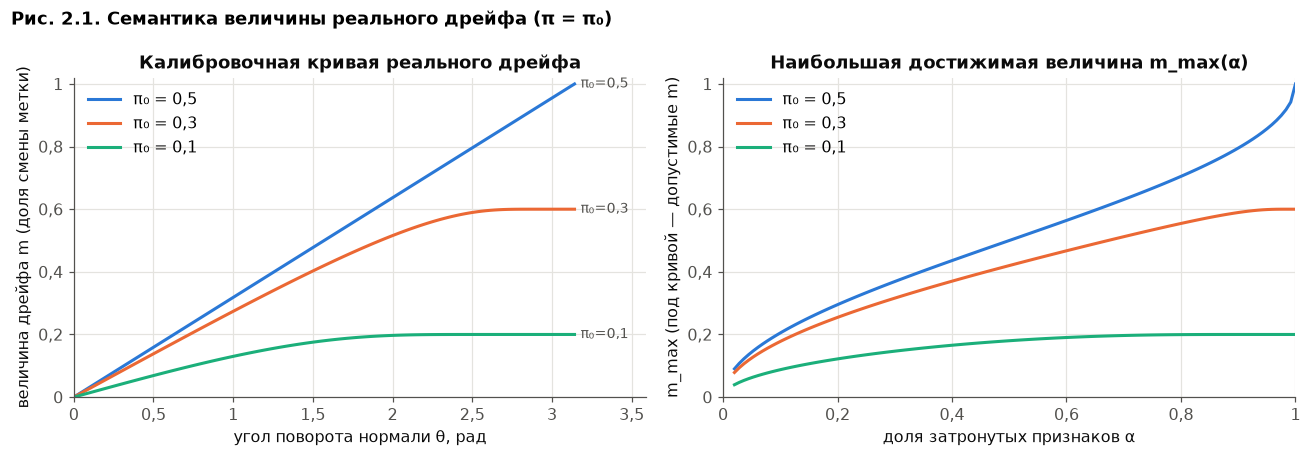

In [7]:
import matplotlib.pyplot as plt

from scendrift.reporting.style import CATEGORICAL, TEXT_SECONDARY, apply_style, decimal_comma

apply_style()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
thetas = np.linspace(0, math.pi, 120)
alphas = np.linspace(0.02, 1.0, 120)
for color, pi0 in zip(CATEGORICAL, [0.5, 0.3, 0.1]):
    curve = [formula_real(t, pi0, pi0) for t in thetas]
    axes[0].plot(thetas, curve, color=color, label=f"π₀ = {pi0}".replace(".", ","))
    axes[0].annotate(f"π₀={pi0}".replace(".", ","), (thetas[-1], curve[-1]), xytext=(4, 0),
                     textcoords="offset points", va="center", fontsize=9, color=TEXT_SECONDARY)
    m_max = [formula_real(math.acos(1 - 2 * a), pi0, pi0) for a in alphas]
    axes[1].plot(alphas, m_max, color=color, label=f"π₀ = {pi0}".replace(".", ","))
axes[0].set(title="Калибровочная кривая реального дрейфа",
            xlabel="угол поворота нормали θ, рад", ylabel="величина дрейфа m (доля смены метки)",
            xlim=(0, math.pi + 0.45), ylim=(0, 1.02))
axes[1].set(title="Наибольшая достижимая величина m_max(α)",
            xlabel="доля затронутых признаков α", ylabel="m_max (под кривой — допустимые m)",
            xlim=(0, 1), ylim=(0, 1.02))
for ax in axes:
    ax.legend(loc="upper left")
decimal_comma(*axes)
fig.suptitle("Рис. 2.1. Семантика величины реального дрейфа (π = π₀)", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig("docs/figures/fig_2_1_severity.png")
plt.show()

Из рис. 2.1 следуют два вывода, существенных для формирования сценариев:

1. При дисбалансе классов (малое $\pi_0$) та же величина требует большего угла поворота, а наибольшая величина ограничена: при полном развороте $m_{\max} = 2\pi_0$ для $\pi = \pi_0$. Поэтому дисбаланс и величину нельзя выбирать независимо, если не делать проверку.
2. Чем меньше доля затронутых признаков, тем меньше $m_{\max}$. «Локальный» дрейф большой величины невозможен. Генератор без проверки молча выдал бы дрейф меньшей величины, чем заявлено, а в нашем фреймворке это нарушение C10.

### 2.4. Пространство параметров и таксономия сценариев

Параметризованное семейство сценариев задаётся отображением $\theta \mapsto S(\theta)$ точек пространства параметров
$$\Theta = \Theta_1 \times \dots \times \Theta_D$$
в сценарии. Оно реализуется на этапе 3. Пространство по умолчанию для семейства `hyperplane_gauss`:

| Параметр | Обозн. | Часть | Домен | По умолч. | Условие активности |
|---|---|---|---|---|---|
| длина потока | $n$ | B | $\{10^4, \dots, 5\cdot 10^4\}$ | 20 000 | всегда |
| размерность | $d$ | B | $\{2, \dots, 50\}$, лог. шкала | 10 | всегда |
| доля положительного класса | $\pi_0$ | B | $[0{,}05;\,0{,}5]$ | 0,5 | всегда |
| шум меток | $\eta$ | B | $[0;\,0{,}3]$ | 0 | всегда |
| число событий | $K$ | E | $\{1, \dots, 5\}$ | 1 | всегда |
| чередование концептов | $r$ | E | {нет, да} | нет | $K \ge 2$ |
| форма перехода | $\varphi$ | E | {sudden, gradual, incremental} | sudden | всегда |
| ширина перехода | $w$ | E | $\{100, \dots, 4000\}$, лог. шкала | 1 000 | $\varphi \ne$ sudden |
| вид дрейфа | $\kappa$ | E | {real, virtual, prior} | real | всегда |
| величина | $m$ | E | $[0{,}02;\,0{,}5]$ | 0,2 | всегда |
| доля затронутых признаков | $\alpha$ | E | $[0{,}2;\,1]$ | 1 | $\kappa \in$ {real, virtual} |
| разогрев | $W$ | Ω | фиксирован | 1 000 | — |
| окно допуска | $\Delta$ | Ω | фиксировано | 2 000 | — |

Условные параметры (например, $w$ при внезапном дрейфе) в неактивном состоянии получают значение по умолчанию. Их координата плана при этом сохраняется, чтобы не нарушить стратификацию LHS и равномерность последовательности Соболя по остальным координатам.

**Таксономия.** Каждый сценарий относится к классам по восьми осям. По этим классам группируются результаты бенчмарка.

| Ось | Классы |
|---|---|
| вид | real / virtual / prior (и их сочетания) |
| форма | sudden / gradual / incremental |
| повторяемость | есть возврат / нет |
| величина | low ($m < 0{,}1$) / medium ($0{,}1 \le m < 0{,}3$) / high ($m \ge 0{,}3$) |
| скорость | abrupt ($w = 0$) / fast ($w < \Delta/2$) / slow ($w \ge \Delta/2$) |
| охват | global ($\alpha = 1$) / partial |
| баланс | balanced ($\pi_0 \ge 0{,}4$) / imbalanced |
| шум | clean ($\eta = 0$) / noisy |

Пороги — договорённость авторов; они вынесены в константы модуля `taxonomy`.

### 2.5. Ограничения валидности и ground truth

Сценарий **допустим**, если выполнены все ограничения уровня «ошибка». Ограничения C1–C3 проверяются при создании объекта, остальные — валидатором. Предупреждения W1 и W2 сценарий не отклоняют, но учитываются при интерпретации результатов.

| Код | Уровень | Ограничение |
|---|---|---|
| C1 | событие | $\varphi = \text{sudden} \Leftrightarrow w = 0$; иначе $w \ge 2$; $\mathrm{onset} \ge 0$ |
| C2 | событие | для обычного события задана $m \in (0, 1]$ |
| C3 | событие | для повторяющегося события ($\rho$ задано) $\kappa$ и $m$ не задаются |
| C4 | сценарий | $\mathrm{onset}_1 \ge W$: дрейф не начинается во время разогрева |
| C5 | сценарий | $\mathrm{end}_K + \Delta \le n$: после последнего перехода есть окно допуска |
| C6 | сценарий | $\mathrm{onset}_{k+1} \ge \mathrm{end}_k + \Delta$: следы событий не пересекаются |
| C7 | сценарий | $\rho_k \le k$, и концепт $\rho_k$ отличается от текущего |
| C8 | семейство | вид, форма и повторение поддерживаются семейством $f$ |
| C9 | семейство | $\lfloor \alpha d \rceil \ge 2$ для real/virtual: существует направление в $A$, ортогональное $w$ |
| C10 | семейство | real: $m \le m_{\max}$ (утверждение 4) |
| C11 | семейство | virtual: $m \le 0{,}99$ (конечный сдвиг) |
| C12 | семейство | prior: новая доля $\pi_{k+1} \in [0{,}01;\,0{,}99]$ |
| C13 | семейство | семейство $f$ зарегистрировано |
| W1 | предупреждение | $m(1 - 2\eta) < 0{,}02$: дрейф почти не наблюдаем |
| W2 | предупреждение | virtual: детекторы по потоку ошибок не обязаны его видеть |

Ограничение C6 гарантирует, что **окна допуска** $[\mathrm{onset}_k, \mathrm{end}_k + \Delta)$ разных событий не пересекаются. Поэтому любое срабатывание детектора однозначно относится не более чем к одному событию.

Если ограничения C9–C12 нарушены, валидатор предлагает ближайшее допустимое значение (например, $m := m_{\max}$). Если нарушены C4–C6, события переносятся по равномерному расписанию. Эту процедуру исправления (repair) использует модуль формирования сценариев: недопустимые точки плана не теряются, а проецируются на допустимую область.

**Ground truth** сценария — набор записей
$$G = \{(\mathrm{onset}_k, \tau_k, \mathrm{end}_k, \varphi_k, \kappa_k, m_k, \tilde m_k)\}_{k=1}^{K},$$
где $\tilde m_k = (m_{\text{real}}, m_{\text{virtual}}, m_{\text{prior}})$ — **фактическая** величина события по трём компонентам. Для обычного события она совпадает с заданной (проверяется в п. 4.1 и в эксперименте Э1), для повторяющегося вычисляется.

### 2.6. Протокол оценки и формализация метрик [Т]

**Протокол оценки** $\Omega = (h, a, W, \Delta, r)$:
- $h$ — базовая онлайн-модель (по умолчанию гауссовский наивный байесовский классификатор из river [3]);
- $a \in \{\text{reset}, \text{none}\}$ — реакция на срабатывание детектора;
- $W$ — разогрев;
- $\Delta$ — окно допуска;
- $r \in \{\text{onset}, \text{center}\}$ — точка отсчёта задержки.

Оценка ведётся по схеме prequential (test-then-train) [27]. Сначала модель предсказывает $\hat y_t$, затем обучается на $(x_t, y_t)$. Детектор получает индикатор ошибки $e_t = \mathbb{1}[\hat y_t \ne y_t]$.

Пусть $D = \{d_1 < d_2 < \dots\}$ — моменты срабатываний после разогрева, а $A_k = [\mathrm{onset}_k, \mathrm{end}_k + \Delta)$ — окно допуска события $k$.

**Правило сопоставления.**
- Событие $k$ **обнаружено** (TP), если $D \cap A_k \neq \varnothing$. Его момент обнаружения $d_k^* = \min (D \cap A_k)$, задержка $\delta_k = d_k^* - \mathrm{ref}_k$, где $\mathrm{ref}_k$ — onset или центр $\tau_k$.
- Иначе событие **пропущено** (FN).
- Срабатывания вне всех окон — **ложные тревоги** $FP_{\text{out}}$; повторные срабатывания внутри окна — **избыточные** $FP_{\text{red}}$.

Окна не пересекаются (C6), поэтому правило однозначно.

**Метрики** (по CD-MOA [5] с обобщением на несколько событий):

| Метрика | Определение |
|---|---|
| Precision / Recall / F1 | $P = TP / \lvert D\rvert$, $R = TP / K$, $F_1 = 2PR/(P + R)$ |
| MDR (missed detection rate) | $FN / K = 1 - R$ |
| MTD (mean time to detection) | $\frac{1}{TP}\sum_{k \in TP} \delta_k$ |
| MTFA (mean time between false alarms) | $T_{\text{stable}} / FP_{\text{out}}$, где $T_{\text{stable}} = (n - W) - \sum_k \lvert A_k \rvert$ |
| MTR (mean time ratio) | $\dfrac{\text{MTFA}}{\text{MTD}}\,(1 - \text{MDR})$ |
| FAR | $1000 \cdot FP_{\text{out}} / T_{\text{stable}}$ — ложные тревоги на 1000 объектов |
| Accuracy | prequential accuracy на $t \ge W$; $\Delta\mathrm{acc}$ относительно базовой линии без детектора и разрыв до «оракула», сбрасывающего модель в истинные моменты дрейфа |

Если ложных тревог нет, MTFA и MTR равны $+\infty$; при агрегировании используется ограничение сверху $T_{\text{stable}}$. Если не обнаружено ни одного события, MTD не определена (NaN).

Bifet показал, что оценка детектора по accuracy классификатора, который перезапускается при каждом срабатывании, вводит в заблуждение [22]. Из-за временной зависимости данных даже «детектор», не обнаруживающий изменений, может повышать accuracy. Отсюда три решения:
- основные метрики считаются относительно ground truth;
- accuracy используется как дополнительная характеристика;
- в число сравниваемых методов включаются базовые линии «без детектора» и «периодический сброс».

Детектор, срабатывающий слишком часто, может также получить высокий recall за счёт окон допуска. Это выявляют precision, MTFA и периодическая базовая линия. Метрики реализуются на этапе 4 (п. 4.9).

## 3. Проектирование фреймворка [К+Т]

### 3.1. Требования

**Функциональные требования**

| № | Требование | Где реализуется |
|---|---|---|
| Ф1 | Описывать сценарий декларативно (YAML/JSON) и программно (Python API) | п. 3.3, 4.1, 4.6 |
| Ф2 | Проверять допустимость сценария и исправлять недопустимые параметры | п. 4.1 |
| Ф3 | Порождать поток с контролируемым дрейфом: тип, позиция, ширина, величина, число и расписание дрейфов, шум, дисбаланс, размерность, доля затронутых признаков | п. 4.2 (этап 2) |
| Ф4 | Внедрять дрейф в реальные наборы данных | п. 4.4 (этап 2) |
| Ф5 | Строить ground truth автоматически: точки, интервалы и фактические величины дрейфа | п. 4.3 (этап 2) |
| Ф6 | Формировать наборы сценариев автоматически: сетка, случайная выборка, LHS, Sobol, шаблоны, композиция, шкала сложности | п. 4.5 (этап 3) |
| Ф7 | Подключать детекторы через единый интерфейс (river: ADWIN, DDM, EDDM, KSWIN, PH, HDDM_A/W) | п. 4.7 (этап 4) |
| Ф8 | Выполнять бенчмарк по схеме prequential с повторами по seed и параллельно | п. 4.8 (этап 4) |
| Ф9 | Вычислять метрики обнаружения и влияние на accuracy, проводить статистическое сравнение | п. 4.9–4.10 (этап 4) |
| Ф10 | Формировать отчёты: таблицы, графики, экспорт в HTML/CSV/Markdown | п. 4.11 (этап 4) |

**Нефункциональные требования**

| № | Требование | Как обеспечивается |
|---|---|---|
| Н1 | Воспроизводимость | детерминированный генератор по $(S, s)$; идентификатор сценария по содержимому; зафиксированные версии библиотек |
| Н2 | Проверяемость | семантика величины с аналитической калибровкой; тесты pytest; численная проверка утверждений |
| Н3 | Расширяемость | реестр семейств генераторов и детекторов; интерфейсы на `typing.Protocol` |
| Н4 | Производительность | параллельные прогоны (joblib); кэш результатов по идентификатору; режимы FAST и FULL |
| Н5 | Документированность | type hints, docstrings, JSON Schema сценария, ноутбук как документация |
| Н6 | Разделение авторства | у каждого модуля указан ответственный; цвет на схемах архитектуры |

### 3.2. Архитектура

Фреймворк состоит из шести подпакетов. Цвет на схемах обозначает ответственного исполнителя.

**Сценарии и данные** (Будаев К. В.):
- `scenario` — формальная модель;
- `formation` — формирование наборов сценариев;
- `generators` — генерация потоков.

**Оценка и анализ** (Гарифзянов Т. Р.):
- `detectors` — детекторы;
- `evaluation` — протокол, раннер, метрики, статистика;
- `reporting` — отчёты.

Внешние библиотеки показаны отдельно: они не являются вкладом авторов. Схемы строит скрипт `tools/diagrams.py` средствами matplotlib, без внешних программ.

In [8]:
%%writefile tools/diagrams.py
"""Схемы архитектуры фреймворка: компоненты, поток данных, диаграмма классов.

Ответственные: Будаев К. В., Гарифзянов Т. Р.

Схемы рисуются средствами matplotlib, поэтому ноутбук и записка не зависят
от внешних программ вроде graphviz. Цвет блока обозначает ответственного
исполнителя: синий — Будаев К. В., зелёный — Гарифзянов Т. Р., серый —
совместная зона или внешние библиотеки.

Запуск: ``python tools/diagrams.py [каталог]`` (по умолчанию docs/figures).
"""

from __future__ import annotations

import sys
from collections.abc import Sequence
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt  # noqa: E402
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch  # noqa: E402

COLORS = {
    "K": ("#dbe7f5", "#2f5d8a"),  # Будаев К. В.
    "T": ("#dcefe2", "#2e7d4f"),  # Гарифзянов Т. Р.
    "J": ("#eeeeee", "#6b6b6b"),  # совместно
    "X": ("#ffffff", "#9a9a9a"),  # внешние библиотеки
}
TEXT = "#1f1f1f"


def _box(ax, x, y, w, h, title, lines=(), who="J", title_size=11, body_size=9):
    face, edge = COLORS[who]
    ax.add_patch(
        FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.008,rounding_size=0.012",
            linewidth=1.4, edgecolor=edge, facecolor=face,
            linestyle="--" if who == "X" else "-",
        )
    )
    ax.text(x + w / 2, y + h - 0.012, title, ha="center", va="top",
            fontsize=title_size, fontweight="bold", color=edge)
    for i, line in enumerate(lines):
        ax.text(x + 0.012, y + h - 0.045 - i * 0.03, line, ha="left", va="top",
                fontsize=body_size, color=TEXT)


def _arrow(ax, start, end, text="", rad=0.0, color="#444444", style="-|>"):
    ax.add_patch(
        FancyArrowPatch(start, end, arrowstyle=style, mutation_scale=13,
                        linewidth=1.2, color=color,
                        connectionstyle=f"arc3,rad={rad}")
    )
    if text:
        mx, my = (start[0] + end[0]) / 2, (start[1] + end[1]) / 2
        horizontal = abs(end[1] - start[1]) < 1e-9
        ax.text(mx if horizontal else mx + 0.008, my + (0.01 if horizontal else 0.0), text,
                fontsize=8, color=color, ha="center" if horizontal else "left",
                va="bottom" if horizontal else "center", style="italic")


def _legend(ax, y=0.02):
    items = [("K", "Будаев К. В."), ("T", "Гарифзянов Т. Р."), ("J", "совместно"),
             ("X", "внешние библиотеки")]
    x = 0.02
    for who, label in items:
        face, edge = COLORS[who]
        ax.add_patch(FancyBboxPatch((x, y), 0.02, 0.022, boxstyle="round,pad=0.002",
                                    facecolor=face, edgecolor=edge,
                                    linestyle="--" if who == "X" else "-"))
        ax.text(x + 0.027, y + 0.011, label, va="center", fontsize=9, color=TEXT)
        x += 0.17


def _canvas(title: str, size=(15, 9.5)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=14, fontweight="bold", color=TEXT, loc="left", pad=8)
    return fig, ax


def component_diagram(path: Path) -> Path:
    """Компонентная схема фреймворка scendrift."""
    fig, ax = _canvas("Рис. А. Компоненты фреймворка scendrift и зоны ответственности")
    xs, w = (0.02, 0.35, 0.68), 0.30
    _box(ax, 0.30, 0.86, 0.40, 0.09, "Вход: описание сценария",
         ["YAML / JSON (JSON Schema) или Python API", "компактная форма: расписание + defaults"],
         who="J")
    _box(ax, xs[0], 0.55, w, 0.27, "scenario — формальная модель",
         ["schema: ScenarioSpec = ⟨B, E, Ω, s⟩", "semantics: цепочка концептов,",
          "   калибровка величины m", "validation: C1–C13, W1–W2, repair",
          "io: канонический JSON, id, схема", "space, taxonomy"], who="K")
    _box(ax, xs[1], 0.55, w, 0.27, "formation — формирование",
         ["samplers: grid, random, LHS, Sobol", "catalog: easy / medium / hard",
          "наследование extends + overrides", "композиция из блоков",
          "шкала сложности λ ∈ [0, 1]", "манифест набора (версия, хэши)"], who="K")
    _box(ax, xs[2], 0.55, w, 0.27, "generators — генерация",
         ["hyperplane_gauss (калиброванное)", "river:* — классические потоки",
          "real:* — внедрение в реальные данные", "переходы: linear / sigmoid",
          "ground truth: интервалы, величины", "StreamData(X, y, GT)"], who="K")
    _box(ax, xs[0], 0.21, w, 0.27, "detectors — детекторы",
         ["единый интерфейс DriftDetector", "ADWIN, DDM, EDDM, KSWIN,",
          "PageHinkley, HDDM_A, HDDM_W", "базовые линии: NoDrift,",
          "Periodic, Oracle", "реестр + гиперпараметры"], who="T")
    _box(ax, xs[1], 0.21, w, 0.27, "evaluation — оценка",
         ["protocol: Ω = (h, a, W, Δ, r)", "runner: prequential, seeds,",
          "   joblib, кэш по id", "metrics: delay, MTD, MDR, MTFA,",
          "   MTR, P/R/F1, Δaccuracy", "stats: Friedman, Nemenyi, Wilcoxon"], who="T")
    _box(ax, xs[2], 0.21, w, 0.27, "reporting — отчёты",
         ["сводные таблицы и ранги", "тепловые карты, CD-диаграммы",
          "области отказа (дерево решений)", "экспорт HTML / CSV / Markdown"], who="T")
    _box(ax, 0.02, 0.06, 0.96, 0.11, "Внешние библиотеки (не являются вкладом авторов)",
         ["river 0.26: детекторы, GaussianNB, генераторы SEA/Agrawal/…   ·   "
          "scipy: qmc (LHS/Sobol), stats, special.owens_t",
          "pydantic   ·   PyYAML   ·   joblib   ·   numpy / pandas / matplotlib   ·   "
          "scikit-learn"], who="X")
    _arrow(ax, (0.36, 0.86), (0.17, 0.825))
    _arrow(ax, (0.50, 0.86), (0.50, 0.825))
    _arrow(ax, (xs[0] + w, 0.685), (xs[1], 0.685))
    _arrow(ax, (xs[1] + w, 0.685), (xs[2], 0.685))
    _arrow(ax, (0.83, 0.55), (0.60, 0.485), "StreamData", rad=-0.15)
    _arrow(ax, (0.17, 0.55), (0.40, 0.485), "ScenarioSpec, id", rad=0.15)
    _arrow(ax, (xs[0] + w, 0.345), (xs[1], 0.345))
    _arrow(ax, (xs[1] + w, 0.345), (xs[2], 0.345))
    _legend(ax, y=0.005)
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def dataflow_diagram(path: Path) -> Path:
    """Конвейер: от пространства параметров до отчёта (змейкой в две строки)."""
    fig, ax = _canvas("Рис. Б. Конвейер автоматического формирования и исполнения бенчмарка",
                      size=(15, 7.5))
    row1: Sequence[tuple[str, list[str], str]] = [
        ("1. Пространство Θ", ["домены параметров,", "условия активности"], "K"),
        ("2. План эксперимента", ["grid / random /", "LHS / Sobol / шкала λ"], "K"),
        ("3. Сборка S(θ)", ["точка θ → сценарий", "(шаблоны, композиция)"], "K"),
        ("4. Проверка", ["ограничения C1–C13:", "отклонить / исправить"], "K"),
        ("5. Набор сценариев", ["ScenarioSpec + id,", "манифест YAML"], "K"),
    ]
    row2: Sequence[tuple[str, list[str], str]] = [
        ("6. Генерация Γ(S, s)", ["StreamData:", "X, y, ground truth"], "K"),
        ("7. Раннер", ["prequential,", "seeds × детекторы"], "T"),
        ("8. Метрики", ["сопоставление", "срабатываний по окну Δ"], "T"),
        ("9. Анализ", ["ранги, тесты Фридмана", "и Неменьи, области отказа"], "T"),
        ("10. Отчёт", ["HTML / CSV / Markdown,", "графики"], "T"),
    ]
    w, h = 0.17, 0.20
    gap = (0.96 - 5 * w) / 4
    y1, y2 = 0.60, 0.22
    for i, (title, lines, who) in enumerate(row1):
        x = 0.02 + i * (w + gap)
        _box(ax, x, y1, w, h, title, lines, who=who, title_size=10.5, body_size=9)
        if i < 4:
            _arrow(ax, (x + w, y1 + h / 2), (x + w + gap, y1 + h / 2))
    for i, (title, lines, who) in enumerate(row2):
        x = 0.02 + (4 - i) * (w + gap)
        _box(ax, x, y2, w, h, title, lines, who=who, title_size=10.5, body_size=9)
        if i < 4:
            _arrow(ax, (x, y2 + h / 2), (x - gap, y2 + h / 2))
    x_last = 0.02 + 4 * (w + gap) + w / 2
    _arrow(ax, (x_last, y1), (x_last, y2 + h))
    ax.text(0.02, 0.86, "Формирование бенчмарка (сценарии и данные)", fontsize=11,
            color=COLORS["K"][1], fontweight="bold")
    ax.text(0.02, 0.47, "Исполнение и анализ (детекторы и метрики)", fontsize=11,
            color=COLORS["T"][1], fontweight="bold")
    ax.text(0.02, 0.10,
            "Идентификатор сценария — SHA-256 канонического JSON ⟨B, E, Ω, s⟩: по нему "
            "кэшируются результаты.\nSeed реализации s (выборка X, y, шум) отделён "
            "от структурного seed c (геометрия концептов, расписание).",
            fontsize=9.5, color=TEXT, va="center")
    _legend(ax, y=-0.03)
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def class_diagram(path: Path) -> Path:
    """Упрощённая UML-диаграмма основных классов и интерфейсов."""
    fig, ax = _canvas("Рис. В. Основные классы и интерфейсы (упрощённая UML-диаграмма)",
                      size=(15, 10))
    _box(ax, 0.36, 0.72, 0.28, 0.22, "ScenarioSpec",
         ["schema_version, name, tags", "stream: StreamSpec", "events: tuple[DriftEvent]",
          "evaluation: EvaluationSpec", "seed: int", "with_seed(s)"], who="K")
    _box(ax, 0.02, 0.76, 0.27, 0.18, "StreamSpec  (B)",
         ["family, n_samples, n_features", "minority_share π, label_noise η",
          "concept_seed c, family_params"], who="K")
    _box(ax, 0.71, 0.74, 0.27, 0.20, "DriftEvent  (e_k)",
         ["position τ, width w, form φ", "kind κ, magnitude m", "affected_share α",
          "returns_to ρ, shape", "onset / end / is_recurring"], who="K")
    _box(ax, 0.71, 0.50, 0.27, 0.17, "EvaluationSpec  (Ω)",
         ["base_model h, on_detection a", "warmup W, acceptance_window Δ",
          "delay_reference r"], who="T")
    _box(ax, 0.02, 0.48, 0.27, 0.22, "ConceptChain",
         ["states: list[ConceptState]", "  (w, μ, π, π₀, concept_id)",
          "geometry: list[EventGeometry]", "  (A, u/v, φ, θ, δ, realized)",
          "violations: list[Violation]"], who="K")
    _box(ax, 0.36, 0.45, 0.28, 0.20, "ValidationReport",
         ["violations: list[Violation]", "  (code, path, level, suggestion)",
          "ok, errors, warnings", "check(S) · repair(S) · ensure_valid(S)"], who="K")
    _box(ax, 0.02, 0.17, 0.27, 0.23, "«protocol» StreamGenerator",
         ["family: str", "generate(S, seed) → StreamData", "",
          "StreamData: X, y, y_clean,", "concept, ground_truth"], who="K")
    _box(ax, 0.36, 0.17, 0.28, 0.21, "GroundTruth",
         ["intervals: tuple[DriftInterval]", "  (onset, center, end, form,",
          "   kind, magnitude, realized)", "drift_mask(), onsets, to_records()"], who="K")
    _box(ax, 0.71, 0.17, 0.27, 0.27, "«protocol» DriftDetector / Metric",
         ["DriftDetector:", "  update(x) → bool, reset(), clone()", "Metric:",
          "  (detections, GT, Ω) → float", "DetectionRun:",
          "  detections, accuracy, runtime"], who="T")
    _box(ax, 0.36, 0.02, 0.28, 0.10, "«protocol» ScenarioSampler",
         ["sample(Θ, n, seed) → list[θ]"], who="K")
    _arrow(ax, (0.36, 0.88), (0.29, 0.88), "1", style="-|>")
    _arrow(ax, (0.64, 0.88), (0.71, 0.88), "0..K", style="-|>")
    _arrow(ax, (0.64, 0.75), (0.71, 0.62), "1", style="-|>")
    _arrow(ax, (0.36, 0.745), (0.16, 0.705), "build_chain(S)", rad=0.08)
    _arrow(ax, (0.50, 0.72), (0.50, 0.65), "check(S)")
    _arrow(ax, (0.15, 0.48), (0.15, 0.40), "используется Γ")
    _arrow(ax, (0.29, 0.28), (0.36, 0.28), "1")
    _arrow(ax, (0.64, 0.28), (0.71, 0.28), "вход")
    _legend(ax, y=-0.045)
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path


def make_all(out_dir: str | Path = "docs/figures") -> list[Path]:
    """Строит все схемы и возвращает пути к PNG."""
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    return [
        component_diagram(out / "arch_components.png"),
        dataflow_diagram(out / "arch_dataflow.png"),
        class_diagram(out / "arch_classes.png"),
    ]


if __name__ == "__main__":
    for p in make_all(sys.argv[1] if len(sys.argv) > 1 else "docs/figures"):
        print(p)

Overwriting tools/diagrams.py


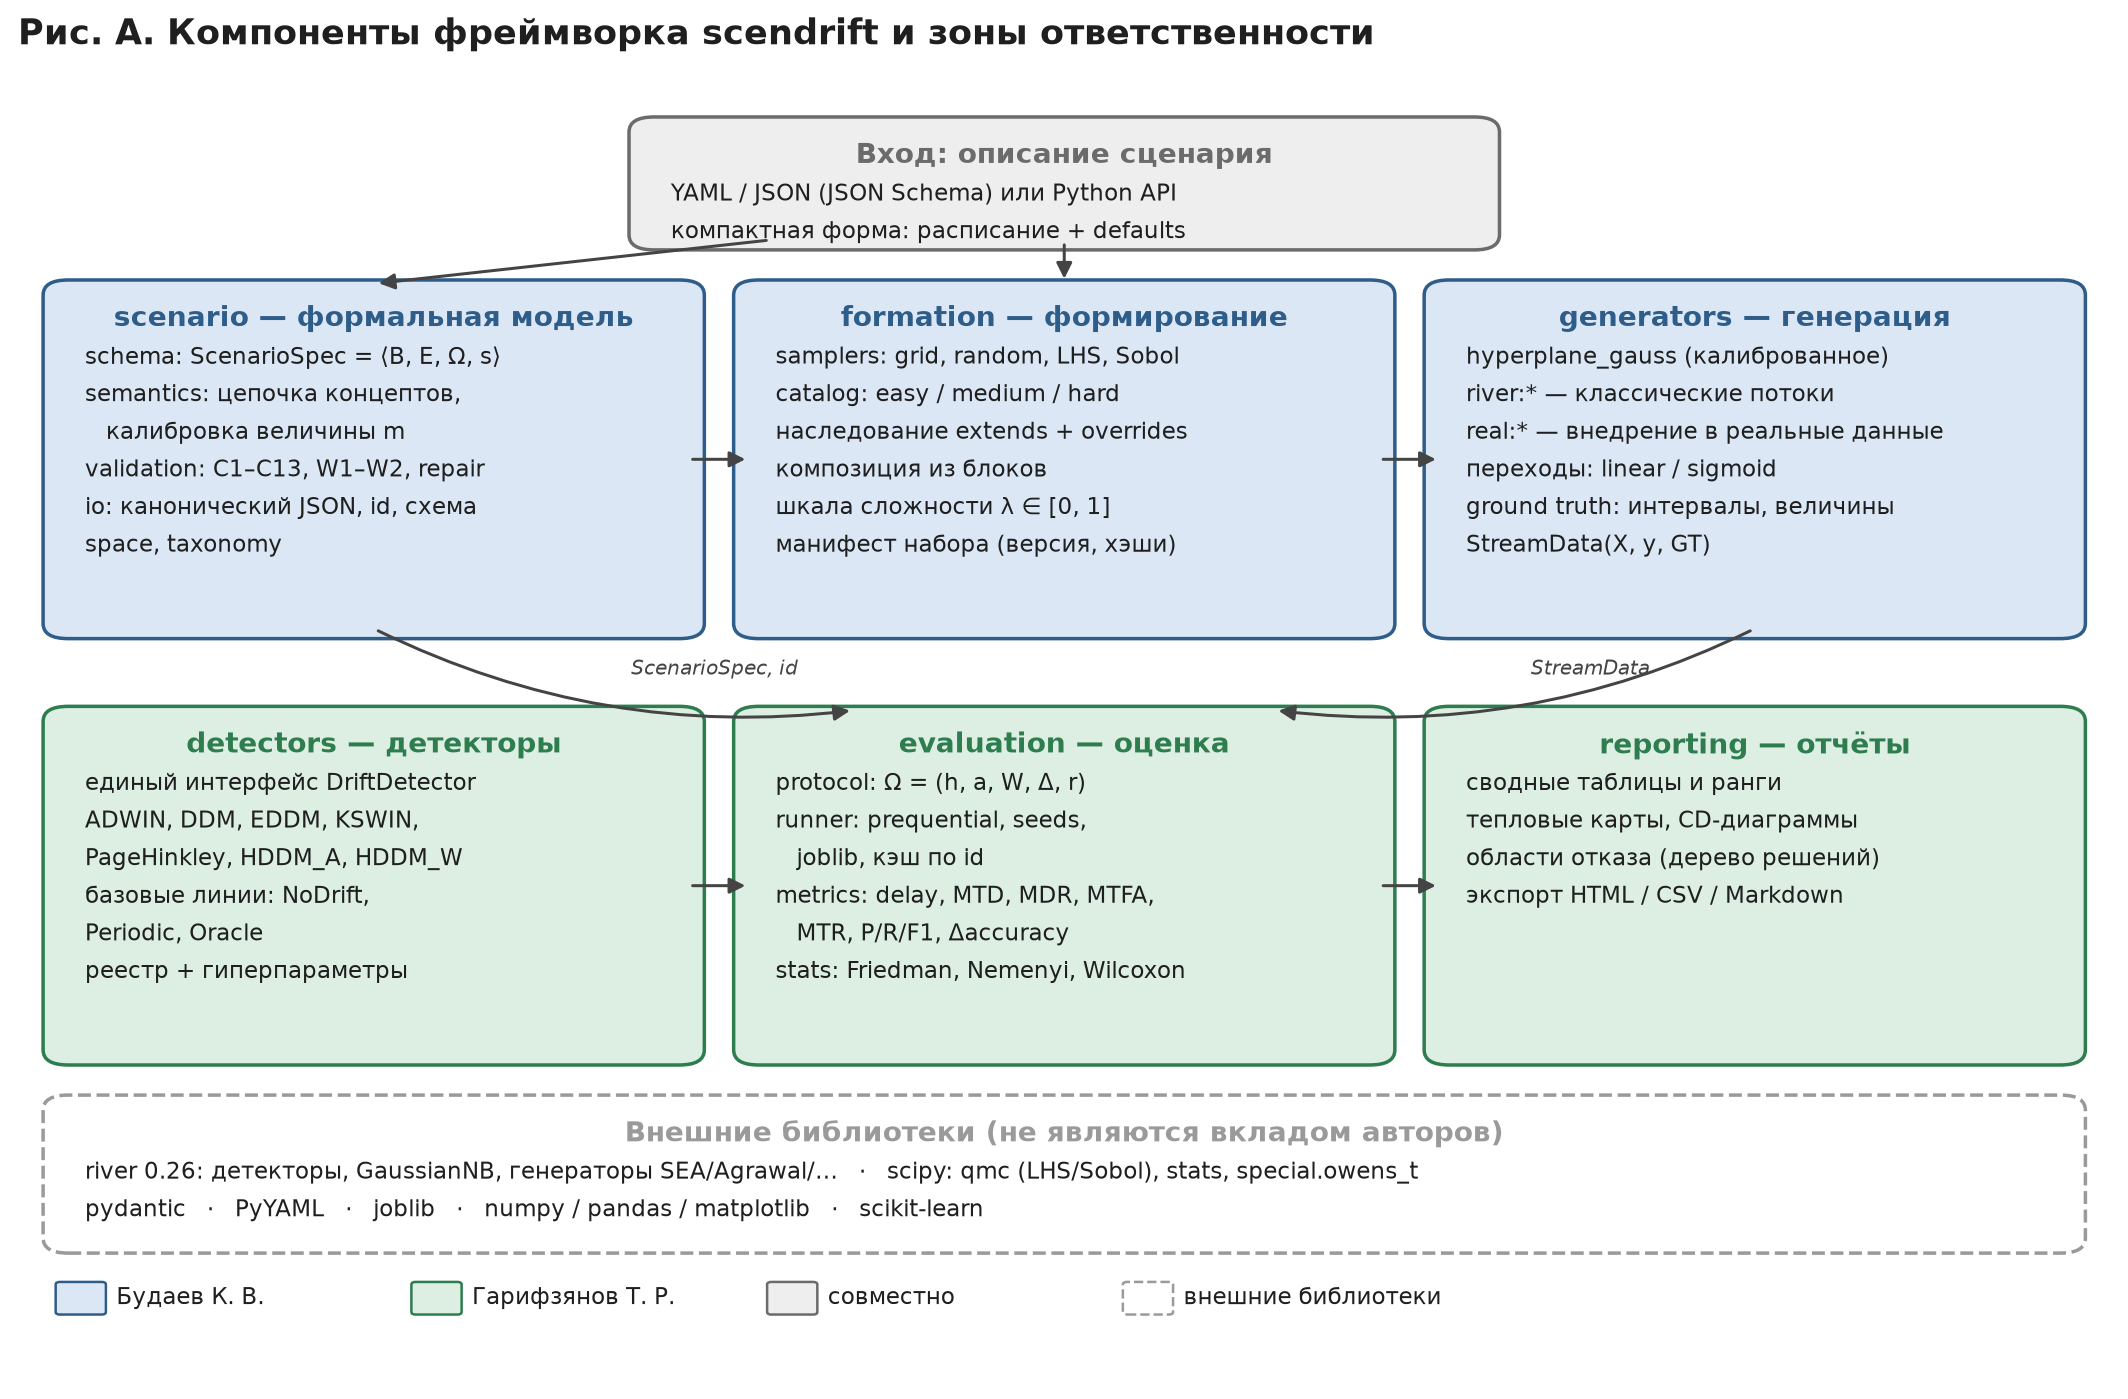

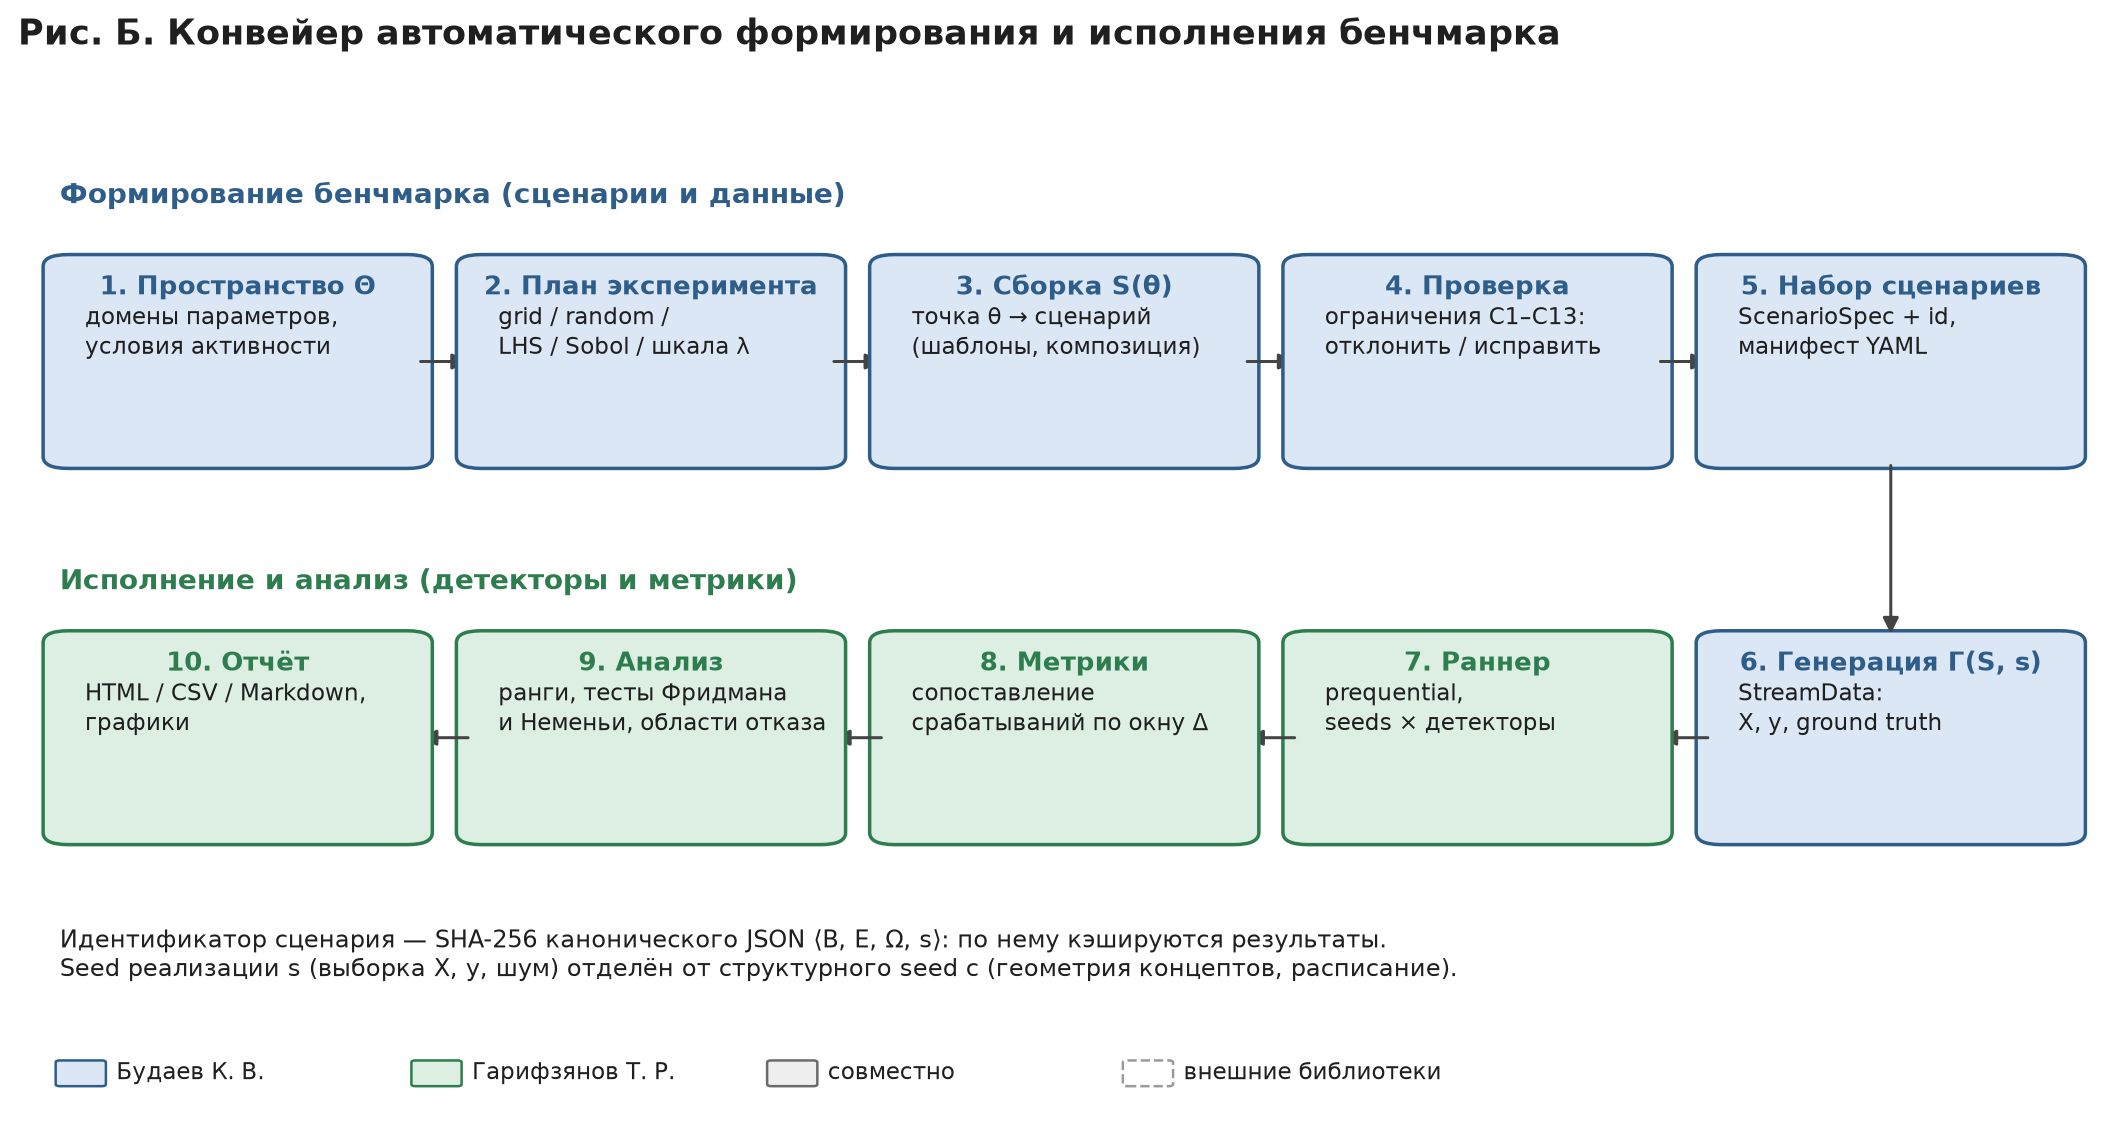

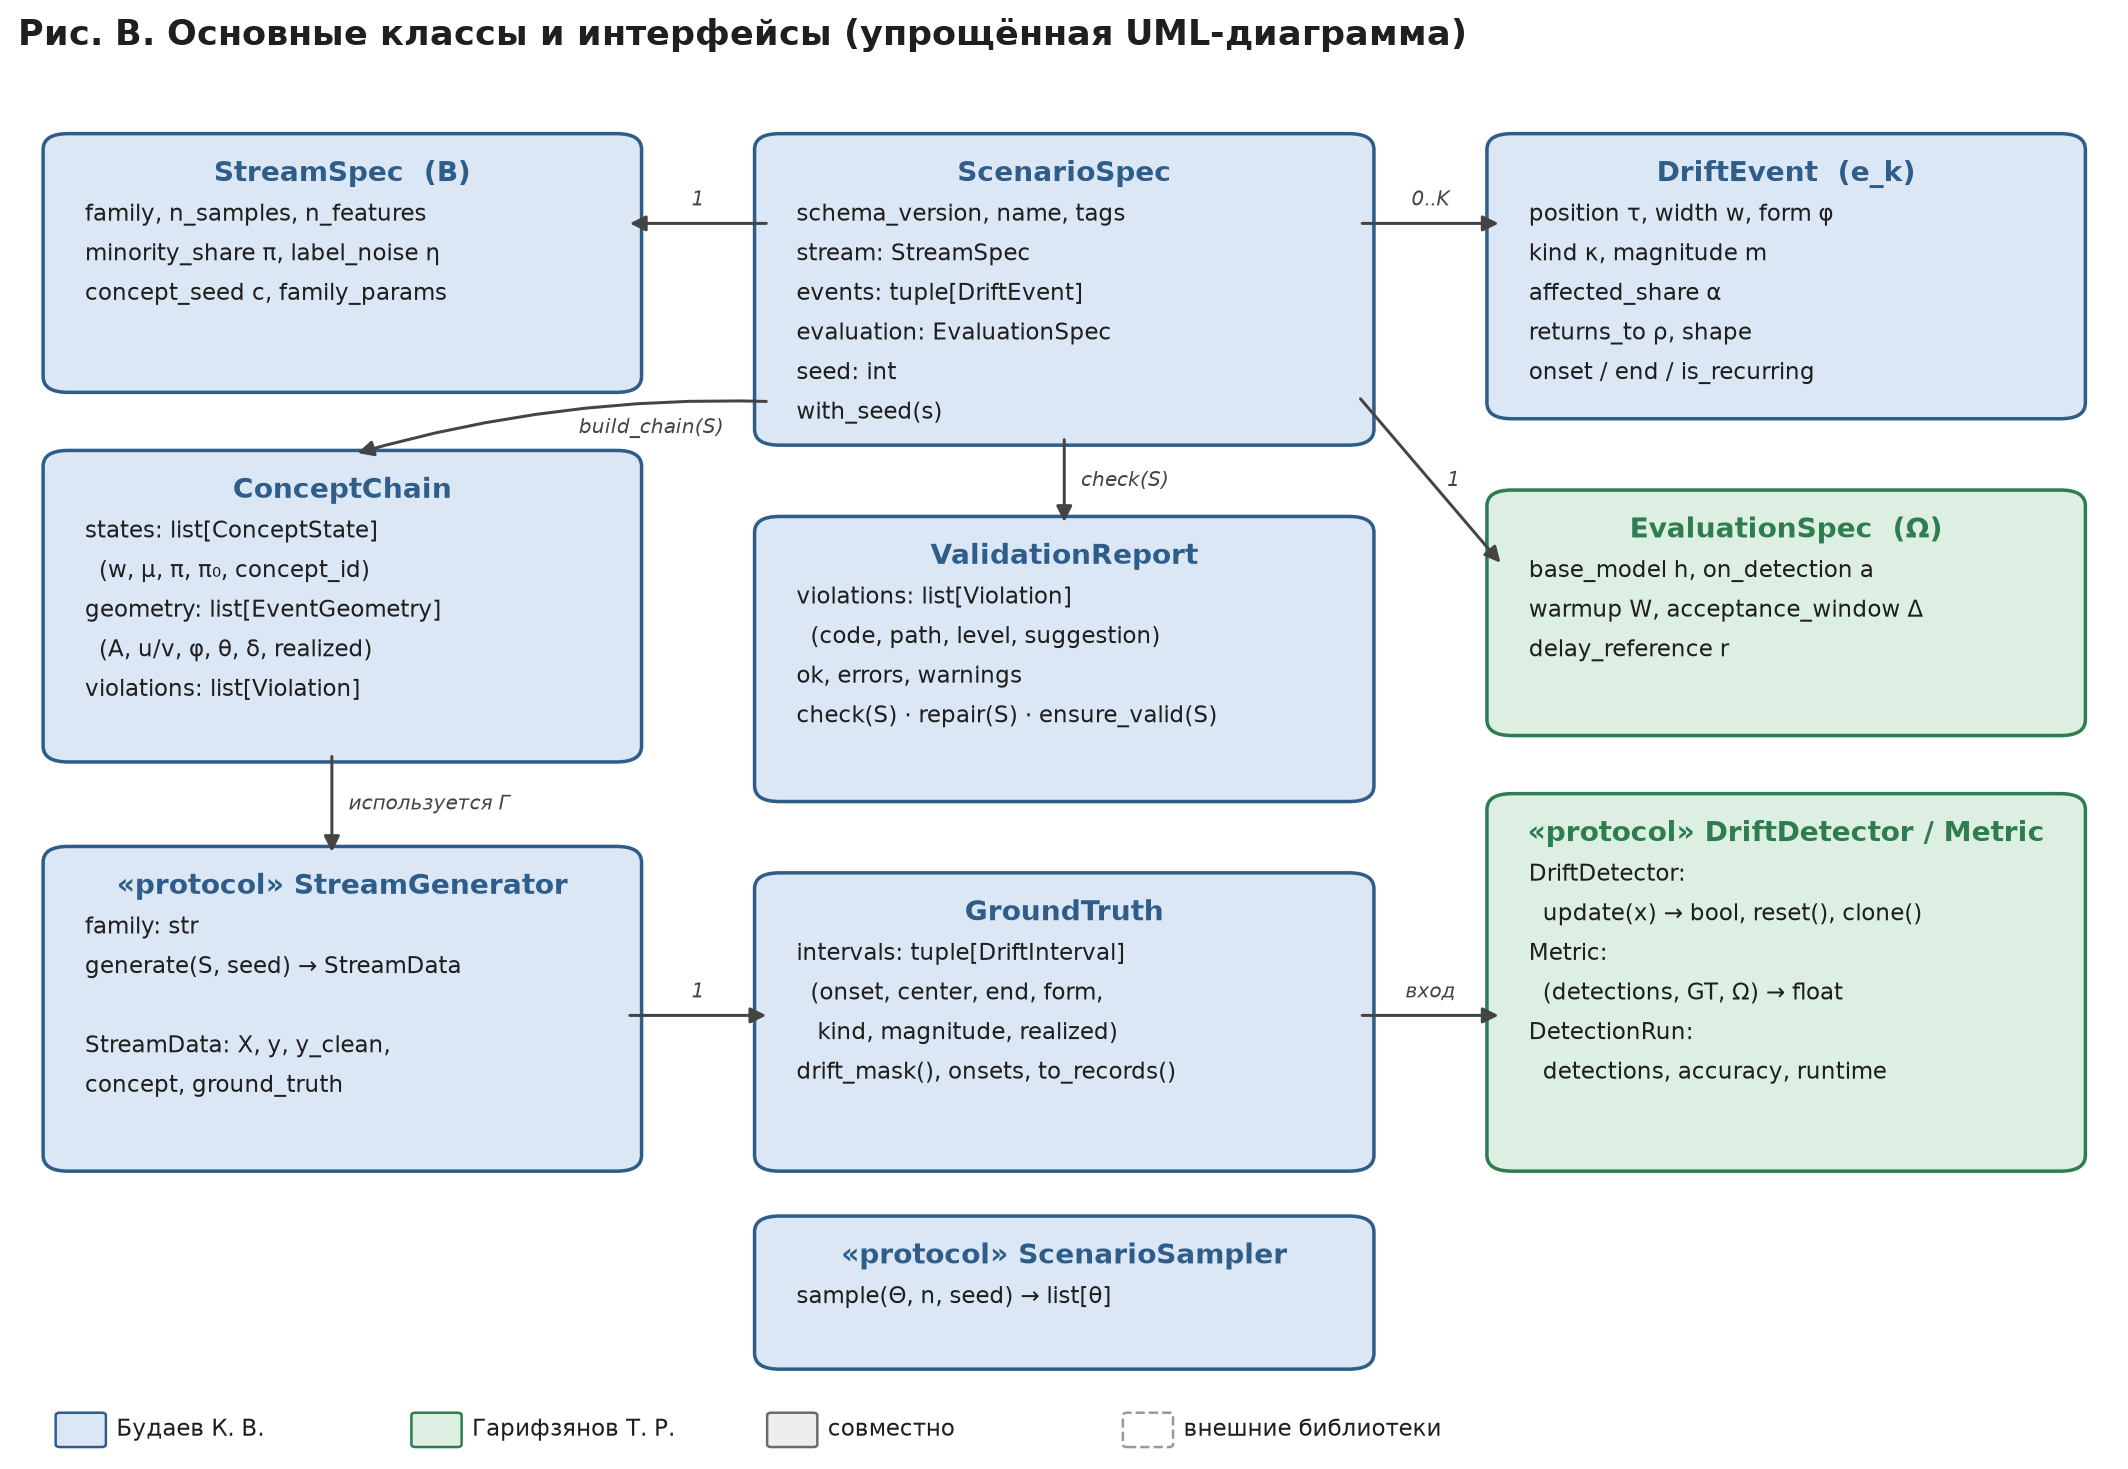

In [9]:
import importlib.util

from IPython.display import Image, display

spec_diagrams = importlib.util.spec_from_file_location("diagrams", "tools/diagrams.py")
diagrams = importlib.util.module_from_spec(spec_diagrams)
spec_diagrams.loader.exec_module(diagrams)
for path in diagrams.make_all("docs/figures"):
    display(Image(filename=str(path), width=980))

Принятые архитектурные решения:

1. **Сценарий — неизменяемый объект-значение** (pydantic, `frozen=True`). Любая модификация (наследование, переопределение, исправление) создаёт новый сценарий с новым идентификатором. Поэтому результаты не могут «перепутаться» со сценарием.
2. **Проверка отделена от схемы.** Pydantic проверяет домены полей и согласованность полей одного события (C1–C3). Межполевые ограничения и ограничения семейства (C4–C13) вынесены в валидатор. Так модуль формирования может построить недопустимого кандидата и исправить его, не теряя точку плана эксперимента.
3. **Семантика вынесена из генератора.** Цепочка концептов (`semantics.build_chain`) вычисляется без порождения данных. Генератор (этап 2) только реализует выборку из уже рассчитанных концептов, поэтому валидатор и генератор используют один и тот же расчёт и не расходятся.
4. **Расширение через реестры и интерфейсы.** Новое семейство генераторов регистрируется вместе со своими ограничениями. Новый детектор подключается адаптером, реализующим `DriftDetector`, без наследования.

### 3.3. Декларативное описание сценариев

Сценарий описывается в YAML или JSON в одной из двух форм:

* **каноническая** — явный список событий `events`. Именно она хранится, хэшируется и подаётся генератору;
* **компактная** — блок `drifts`: расписание (`uniform`, `random`, `explicit`), параметры по умолчанию и переопределения отдельных событий. При загрузке она разворачивается в каноническую форму.

Наследование шаблонов (`extends`) и каталог профилей «лёгкий / средний / тяжёлый» добавляются на этапе 3.

Ниже пять примеров, которые входят в репозиторий и проверяются тестами:
1. каноническая форма;
2. компактная форма с дисбалансом и шумом;
3. смешанный сценарий с возвратом к исходному концепту;
4. инкрементальный дрейф со случайным расписанием;
5. дрейф априорных вероятностей.

In [10]:
%%writefile configs/examples/01_sudden_real.yaml
# Пример 1. Один внезапный реальный дрейф: каноническая (явная) форма сценария.
# Нормаль гиперплоскости поворачивается так, что метка меняется на 25 % пространства признаков.
schema_version: "1.0"
name: sudden_real_single
description: Один внезапный реальный дрейф средней величины в середине потока
tags: [example, sudden, real]
stream:
  family: hyperplane_gauss
  n_samples: 20000
  n_features: 10
  minority_share: 0.5
  label_noise: 0.0
  concept_seed: 0
events:
  - {position: 10000, form: sudden, kind: real, magnitude: 0.25, affected_share: 1.0}
evaluation:
  base_model: gaussian_nb
  on_detection: reset
  warmup: 1000
  acceptance_window: 2000
seed: 1

Overwriting configs/examples/01_sudden_real.yaml


In [11]:
%%writefile configs/examples/02_gradual_imbalanced_noisy.yaml
# Пример 2. Компактная форма: расписание + параметры по умолчанию.
# Три постепенных реальных дрейфа на несбалансированном потоке с шумом меток.
schema_version: "1.0"
name: gradual_imbalanced_noisy
tags: [example, gradual, imbalanced, noisy]
stream:
  n_samples: 30000
  n_features: 20
  minority_share: 0.2      # π: доля положительного класса
  label_noise: 0.1         # η: эффективная величина m·(1 − 2η) = 0,12
  concept_seed: 11
drifts:
  schedule: {mode: uniform, count: 3}
  defaults: {form: gradual, kind: real, width: 2000, magnitude: 0.15, affected_share: 0.5}
seed: 2

Overwriting configs/examples/02_gradual_imbalanced_noisy.yaml


In [12]:
%%writefile configs/examples/03_recurring_mixed.yaml
# Пример 3. Смешанный сценарий с возвратом: real → virtual → возврат к исходному концепту.
# Третий дрейф (returns_to: 0) отменяет и поворот, и сдвиг: вид и величина вычисляются.
schema_version: "1.0"
name: recurring_mixed
tags: [example, recurring, mixed]
stream:
  n_samples: 20000
  n_features: 10
  minority_share: 0.3
  label_noise: 0.05
  concept_seed: 7
drifts:
  schedule: {mode: uniform, count: 3}
  defaults: {form: gradual, kind: real, width: 1000, magnitude: 0.2, affected_share: 0.5}
  overrides:
    - {index: 1, kind: virtual, magnitude: 0.4}
    - {index: 2, returns_to: 0}
seed: 42

Overwriting configs/examples/03_recurring_mixed.yaml


In [13]:
%%writefile configs/examples/04_incremental_random_schedule.yaml
# Пример 4. Инкрементальные дрейфы со случайным расписанием (позиции задаёт concept_seed).
# Затронута только часть признаков, поэтому m ограничена сверху (ограничение C10).
schema_version: "1.0"
name: incremental_random_partial
tags: [example, incremental, partial]
stream:
  n_samples: 40000
  n_features: 15
  minority_share: 0.5
  concept_seed: 5
drifts:
  schedule: {mode: random, count: 4, min_gap: 500}
  defaults: {form: incremental, kind: real, width: 3000, magnitude: 0.1, affected_share: 0.3}
  overrides:
    - {index: 3, shape: sigmoid}
seed: 3

Overwriting configs/examples/04_incremental_random_schedule.yaml


In [14]:
%%writefile configs/examples/05_prior_shift.yaml
# Пример 5. Дрейф априорных вероятностей (label shift): P(y) меняется, P(X|y) сохраняется.
schema_version: "1.0"
name: prior_shift_two_steps
tags: [example, prior]
stream:
  n_samples: 20000
  n_features: 5
  minority_share: 0.3
drifts:
  schedule: {mode: explicit, count: 2, positions: [7000, 14000]}
  defaults: {form: sudden, kind: prior, magnitude: 0.2}
seed: 4

Overwriting configs/examples/05_prior_shift.yaml


JSON Schema канонической формы генерируется из pydantic-моделей автоматически (п. 4.6). Поэтому схема всегда соответствует коду. Её можно подключить в редакторе (VS Code, PyCharm) для автодополнения и проверки YAML-файлов сценариев.

### 3.4. Интерфейсы модулей [К+Т]

Контракты между модулями заданы через `typing.Protocol` (структурная типизация). Детектор из любой библиотеки достаточно обернуть адаптером с методами `update`, `reset` и `clone`, а наследоваться от классов фреймворка не нужно.

Модуль также определяет общие структуры данных:
- `GroundTruth` и `DriftInterval` — истинная разметка дрейфа;
- `StreamData` — реализация потока;
- `DetectionRun` — результат одного прогона детектора.

In [15]:
%%writefile scendrift/interfaces.py
"""Общие типы данных и интерфейсы модулей фреймворка.

Ответственные: Будаев К. В. (данные, генераторы, формирование сценариев) и
Гарифзянов Т. Р. (детекторы, метрики, раннер).

Контракты между модулями заданы через :class:`typing.Protocol`
(структурная типизация). Поэтому, например, детектор из любой библиотеки
подключается адаптером, без наследования от классов фреймворка.

Поток данных между модулями::

    ScenarioSpec ──generate──▶ StreamData(X, y, GroundTruth)
         │                          │
         └──────── Runner ◀─────────┘ ── DriftDetector, Metric ──▶ DetectionRun
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from dataclasses import dataclass, field
from typing import TYPE_CHECKING, Any, Protocol, runtime_checkable

import numpy as np

if TYPE_CHECKING:
    from scendrift.evaluation.protocol import EvaluationSpec
    from scendrift.scenario.schema import ScenarioSpec
    from scendrift.scenario.space import ParameterSpace

__all__ = [
    "DriftInterval",
    "GroundTruth",
    "StreamData",
    "StreamGenerator",
    "ScenarioSampler",
    "DriftDetector",
    "Metric",
    "DetectionRun",
]


# ---------------------------------------------------------------------------
# Данные (Будаев К. В.)
# ---------------------------------------------------------------------------


@dataclass(frozen=True)
class DriftInterval:
    """Истинное событие дрейфа в ground truth.

    Attributes:
        index: номер события (с нуля).
        onset: начало перехода (индекс первого объекта, затронутого дрейфом).
        center: центр перехода τ.
        end: конец перехода (исключительно); при внезапном дрейфе end = onset.
        form: форма перехода.
        kind: вид события или ``"recurring"``.
        magnitude: заданная величина (None для повторяющегося события).
        realized: фактическая величина по компонентам real/virtual/prior.
        returns_to: номер концепта возврата.
    """

    index: int
    onset: int
    center: int
    end: int
    form: str
    kind: str
    magnitude: float | None
    realized: Mapping[str, float] = field(default_factory=dict)
    returns_to: int | None = None

    def acceptance_window(self, delta: int) -> tuple[int, int]:
        """Полуинтервал [onset, end + Δ), на котором срабатывание засчитывается."""
        return self.onset, self.end + delta


@dataclass(frozen=True)
class GroundTruth:
    """Истинная разметка дрейфа потока: упорядоченный набор интервалов."""

    intervals: tuple[DriftInterval, ...]
    n_samples: int

    def __len__(self) -> int:
        return len(self.intervals)

    @property
    def onsets(self) -> np.ndarray:
        """Начала переходов."""
        return np.array([iv.onset for iv in self.intervals], dtype=np.int64)

    def drift_mask(self) -> np.ndarray:
        """Булев вектор длины n: объект находится внутри интервала перехода.

        При внезапном дрейфе отмечается ровно один объект (onset).
        """
        mask = np.zeros(self.n_samples, dtype=bool)
        for iv in self.intervals:
            mask[iv.onset : max(iv.end, iv.onset + 1)] = True
        return mask

    def to_records(self) -> list[dict[str, Any]]:
        """Список словарей (для pandas.DataFrame и экспорта в CSV)."""
        rows = []
        for iv in self.intervals:
            row = {
                "index": iv.index,
                "onset": iv.onset,
                "center": iv.center,
                "end": iv.end,
                "form": iv.form,
                "kind": iv.kind,
                "magnitude": iv.magnitude,
                "returns_to": iv.returns_to,
            }
            row.update({f"realized_{k}": v for k, v in iv.realized.items()})
            rows.append(row)
        return rows


@dataclass(frozen=True)
class StreamData:
    """Реализация потока по сценарию.

    Attributes:
        X: матрица признаков n × d.
        y: метки (с шумом), n.
        ground_truth: истинная разметка дрейфа.
        concept: номер концепта, породившего объект (латентная переменная), n.
        y_clean: метки без шума (для валидации генератора), n.
        scenario_id: идентификатор сценария.
        seed: seed реализации.
    """

    X: np.ndarray
    y: np.ndarray
    ground_truth: GroundTruth
    concept: np.ndarray
    y_clean: np.ndarray
    scenario_id: str
    seed: int

    @property
    def n_samples(self) -> int:
        return int(self.X.shape[0])

    @property
    def n_features(self) -> int:
        return int(self.X.shape[1])


@runtime_checkable
class StreamGenerator(Protocol):
    """Генератор потока семейства ``family``: детерминирован при фиксированных (S, seed)."""

    family: str

    def generate(self, spec: ScenarioSpec, seed: int | None = None) -> StreamData:
        """Порождает поток. Если seed не задан, берётся ``spec.seed``."""
        ...


@runtime_checkable
class ScenarioSampler(Protocol):
    """План эксперимента над пространством параметров (этап 3)."""

    def sample(self, space: ParameterSpace, n: int, seed: int) -> list[dict[str, Any]]:
        """Возвращает n точек пространства параметров."""
        ...


# ---------------------------------------------------------------------------
# Оценка (Гарифзянов Т. Р.)
# ---------------------------------------------------------------------------


@runtime_checkable
class DriftDetector(Protocol):
    """Детектор дрейфа: получает поток значений (обычно индикатор ошибки 0/1)."""

    name: str

    def update(self, value: float) -> bool:
        """Обрабатывает очередное значение и возвращает True при срабатывании."""
        ...

    def reset(self) -> None:
        """Возвращает детектор в исходное состояние."""
        ...

    def clone(self) -> DriftDetector:
        """Новый экземпляр с теми же гиперпараметрами в исходном состоянии."""
        ...


@dataclass(frozen=True)
class DetectionRun:
    """Результат одного прогона: сценарий × seed × детектор.

    Attributes:
        scenario_id: идентификатор сценария.
        seed: seed реализации.
        detector: имя детектора (с гиперпараметрами).
        detections: моменты срабатываний (индексы объектов).
        n_samples: длина потока.
        accuracy: prequential accuracy базовой модели.
        runtime_s: время прогона, с.
        extra: дополнительные измерения.
    """

    scenario_id: str
    seed: int
    detector: str
    detections: tuple[int, ...]
    n_samples: int
    accuracy: float
    runtime_s: float
    extra: Mapping[str, Any] = field(default_factory=dict)


@runtime_checkable
class Metric(Protocol):
    """Метрика качества обнаружения по срабатываниям и ground truth."""

    name: str

    def __call__(
        self,
        detections: Sequence[int],
        ground_truth: GroundTruth,
        protocol: EvaluationSpec,
    ) -> float:
        """Значение метрики (NaN, если метрика не определена)."""
        ...

Overwriting scendrift/interfaces.py


## 4. Реализация

Каждый модуль приводится полностью в ячейке `%%writefile`, которая создаёт файл пакета. Перед ячейкой объясняется назначение модуля, после неё идёт демонстрация. Оформление кода соответствует PEP 8 (проверяется `ruff`), у функций есть аннотации типов и docstrings.

### 4.1. Формальная модель сценария: схема, семантика, проверка [К]

#### 4.1.1. Перечисления

Формы перехода, виды дрейфа и профили функции перехода. Повторяющийся дрейф — не форма, а отдельное поле события (см. п. 2.2).

In [16]:
%%writefile scendrift/scenario/enums.py
"""Перечисления формальной модели сценария дрейфа.

Ответственный: Будаев К. В.

Повторяющийся дрейф (recurring) здесь сознательно не является формой
перехода. Возврат к ранее встречавшемуся концепту может быть как внезапным,
так и постепенным, поэтому он задаётся отдельно, полем ``returns_to``
события дрейфа (см. :class:`scendrift.scenario.schema.DriftEvent`).
"""

from __future__ import annotations

from enum import StrEnum

__all__ = ["DriftForm", "DriftKind", "TransitionShape"]


class DriftForm(StrEnum):
    """Форма дрейфа во времени: как новый концепт замещает старый.

    * ``SUDDEN`` — внезапный дрейф (sudden/abrupt): мгновенная смена концепта, ширина 0.
    * ``GRADUAL`` — постепенный дрейф (gradual): на интервале перехода объекты
      порождаются то старым, то новым концептом, причём вероятность нового растёт.
    * ``INCREMENTAL`` — инкрементальный дрейф (incremental): параметры концепта
      непрерывно меняются, проходя через промежуточные концепты.
    """

    SUDDEN = "sudden"
    GRADUAL = "gradual"
    INCREMENTAL = "incremental"


class DriftKind(StrEnum):
    """Вид дрейфа: какая компонента совместного распределения P(X, y) меняется.

    * ``REAL`` — реальный дрейф (real drift): меняется P(y|X), а P(X) и P(y)
      сохраняются.
    * ``VIRTUAL`` — виртуальный дрейф (virtual drift, covariate shift): меняется
      P(X), а P(y|X) и P(y) сохраняются.
    * ``PRIOR`` — дрейф априорных вероятностей (prior/label shift): меняется P(y),
      а P(X|y) сохраняется.
    """

    REAL = "real"
    VIRTUAL = "virtual"
    PRIOR = "prior"


class TransitionShape(StrEnum):
    """Профиль функции перехода p(t) на интервале [onset, end).

    * ``LINEAR`` — линейный рост от 0 до 1.
    * ``SIGMOID`` — сигмоида как в MOA (ConceptDriftStream), отнормированная
      так, что p(onset) = 0 и p(end) = 1 ровно на границах интервала.
    """

    LINEAR = "linear"
    SIGMOID = "sigmoid"

Overwriting scendrift/scenario/enums.py


#### 4.1.2. Протокол оценки Ω [Т]

Протокол оценки входит в сценарий и в его идентификатор: от выбора $W$ и $\Delta$ зависят результаты. На данные протокол не влияет.

In [17]:
%%writefile scendrift/evaluation/__init__.py
"""Оценка детекторов: протокол, раннер, метрики, статистика.

Ответственный: Гарифзянов Т. Р.
"""

from scendrift.evaluation.protocol import AdaptationPolicy, DelayReference, EvaluationSpec

__all__ = ["AdaptationPolicy", "DelayReference", "EvaluationSpec"]

Overwriting scendrift/evaluation/__init__.py


In [18]:
%%writefile scendrift/evaluation/protocol.py
"""Протокол оценки Ω — составная часть формальной модели сценария.

Ответственный: Гарифзянов Т. Р.

Сценарий S = ⟨B, E, Ω, s⟩ включает протокол оценки Ω = (h, a, W, Δ, r):

* h — базовая (онлайн) модель, ошибки которой отслеживает детектор;
* a — политика адаптации при срабатывании детектора;
* W — длина разогрева (warm-up), в течение которого дрейф не допускается;
* Δ — окно допуска: срабатывание засчитывается как обнаружение события,
  если оно произошло на отрезке [onset, end + Δ);
* r — от какой точки отсчитывается задержка обнаружения: начало или центр перехода.

Правила сопоставления срабатываний с событиями и определения метрик
(TP/FP/FN, MTD, MDR, MTFA, MTR) формализованы в разделе 2.6 ноутбука,
реализация вынесена в модуль ``scendrift.evaluation.metrics`` (этап 4).
"""

from __future__ import annotations

from enum import StrEnum

from pydantic import BaseModel, ConfigDict, Field

__all__ = ["AdaptationPolicy", "DelayReference", "EvaluationSpec"]


class AdaptationPolicy(StrEnum):
    """Реакция на срабатывание детектора.

    * ``RESET`` — базовая модель сбрасывается и обучается заново
      (стандартная схема detect-and-reset).
    * ``NONE`` — модель продолжает обучаться, срабатывания только фиксируются.
    """

    RESET = "reset"
    NONE = "none"


class DelayReference(StrEnum):
    """Точка отсчёта задержки обнаружения."""

    ONSET = "onset"
    CENTER = "center"


class EvaluationSpec(BaseModel):
    """Протокол оценки Ω (часть сценария, учитывается в его идентификаторе)."""

    model_config = ConfigDict(extra="forbid", frozen=True)

    base_model: str = Field(
        "gaussian_nb",
        description="h — идентификатор базовой онлайн-модели в реестре моделей.",
    )
    on_detection: AdaptationPolicy = Field(
        AdaptationPolicy.RESET, description="a — политика адаптации при срабатывании."
    )
    warmup: int = Field(
        1_000, ge=0, description="W — длина разогрева: дрейф не начинается раньше W."
    )
    acceptance_window: int = Field(
        2_000,
        ge=1,
        description="Δ — окно допуска: обнаружение засчитывается на [onset, end + Δ).",
    )
    delay_reference: DelayReference = Field(
        DelayReference.ONSET, description="r — точка отсчёта задержки."
    )

Overwriting scendrift/evaluation/protocol.py


#### 4.1.3. Схема сценария

Pydantic-модели `StreamSpec` (B), `DriftEvent` ($e_k$) и `ScenarioSpec` (S), а также компактная форма `DriftPlan` с функцией развёртывания `expand_plan`. Модели неизменяемы (`frozen=True`) и запрещают неизвестные поля (`extra="forbid"`): опечатка в YAML-файле даёт ошибку, а не молча игнорируется.

In [19]:
%%writefile scendrift/scenario/schema.py
"""Декларативная схема сценария дрейфа (pydantic).

Ответственный: Будаев К. В. (протокол оценки Ω — Гарифзянов Т. Р.,
см. :mod:`scendrift.evaluation.protocol`).

Формальная модель: сценарий S = ⟨B, E, Ω, s⟩, где

* B = (f, n, d, π, η, c) — базовая конфигурация потока
  (:class:`StreamSpec`): семейство генератора, длина, размерность, доля
  положительного (миноритарного) класса, шум меток, структурный seed c;
* E = (e₁, …, e_K) — упорядоченные события дрейфа (:class:`DriftEvent`),
  e_k = (τ_k, w_k, φ_k, κ_k, m_k, α_k, ρ_k);
* Ω — протокол оценки (:class:`~scendrift.evaluation.protocol.EvaluationSpec`);
* s — seed реализации.

Здесь проверяются только *локальные* ограничения: домены полей и
согласованность полей одного события. Ограничения между полями разных
частей сценария и ограничения конкретного семейства генераторов проверяет
:mod:`scendrift.scenario.validation`. Благодаря такому разделению модули
формирования сценариев (этап 3) могут сначала построить недопустимого
кандидата, а затем отклонить или исправить его.

Кроме канонической формы (явный список событий) поддерживается компактная
форма :class:`DriftPlan`: расписание, параметры по умолчанию и
переопределения. Функция :func:`expand_plan` разворачивает её в явный список.
"""

from __future__ import annotations

import math
from typing import Any, Literal

import numpy as np
from pydantic import BaseModel, ConfigDict, Field, model_validator

from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario.enums import DriftForm, DriftKind, TransitionShape

__all__ = [
    "SCHEMA_VERSION",
    "MIN_CLASS_SHARE",
    "StreamSpec",
    "DriftEvent",
    "ScenarioSpec",
    "SchedulePlan",
    "EventTemplate",
    "EventOverride",
    "DriftPlan",
    "expand_plan",
    "layout_uniform",
]

#: Версия схемы сценария. Меняется при несовместимом изменении полей.
SCHEMA_VERSION = "1.0"

#: Минимально допустимая доля любого класса (для π и для prior-дрейфа).
MIN_CLASS_SHARE = 0.01

#: Метка подпотока генератора случайных чисел для расписания (см. expand_plan).
_SCHEDULE_STREAM_TAG = 1_000_003


class _Frozen(BaseModel):
    """Базовый класс: неизменяемые модели без лишних полей."""

    model_config = ConfigDict(extra="forbid", frozen=True)


class StreamSpec(_Frozen):
    """Базовая конфигурация потока B = (f, n, d, π, η, c)."""

    family: str = Field(
        "hyperplane_gauss", min_length=1, description="f — семейство генератора потока."
    )
    n_samples: int = Field(20_000, ge=1_000, le=10_000_000, description="n — длина потока.")
    n_features: int = Field(10, ge=2, le=500, description="d — число признаков.")
    minority_share: float = Field(
        0.5,
        ge=MIN_CLASS_SHARE,
        le=0.5,
        description="π — исходная доля положительного (миноритарного) класса P(y=1).",
    )
    label_noise: float = Field(
        0.0, ge=0.0, lt=0.5, description="η — вероятность инверсии метки (шум меток)."
    )
    concept_seed: int = Field(
        0,
        ge=0,
        description=(
            "c — структурный seed: задаёт геометрию концептов (затронутые признаки, "
            "направления поворота и сдвига) и случайное расписание. От seed "
            "реализации не зависит, поэтому повторы сценария имеют одинаковые концепты."
        ),
    )
    family_params: dict[str, Any] = Field(
        default_factory=dict, description="Параметры, специфичные для семейства."
    )


class DriftEvent(_Frozen):
    """Событие дрейфа e = (τ, w, φ, κ, m, α, ρ).

    Интервал перехода — полуинтервал [onset, end), где
    onset = τ − ⌊w/2⌋ и end = onset + w. При внезапном дрейфе onset = end = τ,
    и объект с индексом τ — первый объект нового концепта.

    Если задано ``returns_to`` (ρ), событие считается *повторяющимся*: поток
    возвращается к концепту с номером ρ. Концепт 0 — исходный, концепт k
    возникает после k-го события. Вид и величина такого события не задаются,
    а вычисляются по разности концептов.
    """

    position: int = Field(ge=0, description="τ — центр интервала перехода (индекс объекта).")
    width: int = Field(0, ge=0, description="w — ширина перехода (в объектах).")
    form: DriftForm = Field(DriftForm.SUDDEN, description="φ — форма перехода.")
    kind: DriftKind | None = Field(None, description="κ — вид дрейфа (None для повторяющегося).")
    magnitude: float | None = Field(
        None, gt=0.0, le=1.0, description="m — величина дрейфа на единой шкале (0, 1]."
    )
    affected_share: float = Field(
        1.0, gt=0.0, le=1.0, description="α — доля признаков, затронутых дрейфом."
    )
    returns_to: int | None = Field(
        None, ge=0, description="ρ — номер концепта, к которому возвращается поток."
    )
    shape: TransitionShape = Field(
        TransitionShape.LINEAR, description="Профиль функции перехода p(t)."
    )

    @model_validator(mode="before")
    @classmethod
    def _default_kind(cls, data: Any) -> Any:
        """Подставляет вид ``real`` для обычного (неповторяющегося) события."""
        if isinstance(data, dict) and data.get("returns_to") is None and data.get("kind") is None:
            data = {**data, "kind": DriftKind.REAL}
        return data

    @model_validator(mode="after")
    def _check_local(self) -> DriftEvent:
        """Локальные ограничения события (C1–C3 каталога ограничений)."""
        if self.form is DriftForm.SUDDEN and self.width != 0:
            raise ValueError("C1: у внезапного дрейфа ширина перехода должна быть 0")
        if self.form is not DriftForm.SUDDEN and self.width < 2:
            raise ValueError("C1: у постепенного/инкрементального дрейфа ширина ≥ 2")
        if self.position - self.width // 2 < 0:
            raise ValueError("C1: интервал перехода начинается до начала потока")
        if self.returns_to is None:
            if self.magnitude is None:
                raise ValueError("C2: для обычного события обязательна величина magnitude")
        else:
            if self.kind is not None or self.magnitude is not None:
                raise ValueError(
                    "C3: у повторяющегося события (returns_to) вид и величина "
                    "не задаются — они вычисляются по разности концептов"
                )
        return self

    @property
    def onset(self) -> int:
        """Начало интервала перехода."""
        return self.position - self.width // 2

    @property
    def end(self) -> int:
        """Конец (исключительно) интервала перехода."""
        return self.onset + self.width

    @property
    def is_recurring(self) -> bool:
        """Признак повторяющегося события."""
        return self.returns_to is not None


class ScenarioSpec(_Frozen):
    """Сценарий дрейфа S = ⟨B, E, Ω, s⟩ в канонической (явной) форме.

    Поля ``name``, ``description``, ``tags`` и ``meta`` описательные: на
    порождаемые данные они не влияют и в идентификатор сценария не входят
    (см. :func:`scendrift.scenario.io.scenario_id`).
    """

    schema_version: Literal["1.0"] = SCHEMA_VERSION
    name: str = Field("unnamed", min_length=1, max_length=200)
    description: str = ""
    tags: tuple[str, ...] = ()
    stream: StreamSpec = Field(default_factory=StreamSpec)
    events: tuple[DriftEvent, ...] = ()
    evaluation: EvaluationSpec = Field(default_factory=EvaluationSpec)
    seed: int = Field(0, ge=0, description="s — seed реализации (выборка X, y, шум).")
    meta: dict[str, Any] = Field(
        default_factory=dict, description="Происхождение сценария (в хэш не входит)."
    )

    @property
    def n_events(self) -> int:
        """Число событий дрейфа K."""
        return len(self.events)

    def with_seed(self, seed: int) -> ScenarioSpec:
        """Копия сценария с другим seed реализации (для повторов)."""
        return self.model_copy(update={"seed": int(seed)})


# ---------------------------------------------------------------------------
# Компактная форма: расписание + значения по умолчанию + переопределения
# ---------------------------------------------------------------------------


class SchedulePlan(_Frozen):
    """Расписание дрейфов.

    * ``uniform`` — поток после разогрева делится на K равных блоков, и
      «след» события [onset, end + Δ) ставится в центр своего блока;
    * ``random`` — следы событий случайно размещаются без перекрытий
      (используется структурный seed c);
    * ``explicit`` — центры τ_k заданы явно.
    """

    mode: Literal["uniform", "random", "explicit"] = "uniform"
    count: int = Field(1, ge=0, le=100, description="K — число событий дрейфа.")
    positions: tuple[int, ...] | None = Field(
        None, description="Явные центры τ_k (только для mode=explicit)."
    )
    min_gap: int = Field(
        0, ge=0, description="Дополнительный зазор между следами событий (mode=random)."
    )

    @model_validator(mode="after")
    def _check(self) -> SchedulePlan:
        if self.mode == "explicit":
            if self.positions is None or len(self.positions) != self.count:
                raise ValueError("для mode=explicit нужно ровно count позиций")
        elif self.positions is not None:
            raise ValueError("positions допустимы только при mode=explicit")
        return self


class EventTemplate(_Frozen):
    """Параметры события по умолчанию: всё, кроме позиции."""

    width: int | None = Field(None, ge=0)
    form: DriftForm | None = None
    kind: DriftKind | None = None
    magnitude: float | None = Field(None, gt=0.0, le=1.0)
    affected_share: float | None = Field(None, gt=0.0, le=1.0)
    shape: TransitionShape | None = None


class EventOverride(EventTemplate):
    """Переопределение параметров события с номером ``index`` (с нуля)."""

    index: int = Field(ge=0)
    returns_to: int | None = Field(None, ge=0)
    position: int | None = Field(None, ge=0)


class DriftPlan(_Frozen):
    """Компактное описание событий дрейфа: расписание и параметры."""

    schedule: SchedulePlan = Field(default_factory=SchedulePlan)
    defaults: EventTemplate = Field(default_factory=EventTemplate)
    overrides: tuple[EventOverride, ...] = ()


def _event_params(plan: DriftPlan, index: int) -> dict[str, Any]:
    """Собирает параметры события: значения по умолчанию плюс переопределения."""
    params: dict[str, Any] = {k: v for k, v in plan.defaults.model_dump().items() if v is not None}
    for ov in plan.overrides:
        if ov.index == index:
            params.update(
                {k: v for k, v in ov.model_dump(exclude={"index"}).items() if v is not None}
            )
            if ov.returns_to is not None:
                # Повторяющееся событие: вид и величина вычисляются, а не задаются.
                params.pop("kind", None)
                params.pop("magnitude", None)
    params.setdefault("form", DriftForm.SUDDEN)
    if params["form"] == DriftForm.SUDDEN:
        params["width"] = 0
    params.setdefault("width", 0)
    return params


def layout_uniform(widths: list[int], start: int, stop: int, delta: int) -> list[int]:
    """Центры событий при равномерном расписании.

    Отрезок [start, stop) делится на K равных блоков, и след события
    [onset, end + Δ) ставится в центр своего блока. Если блок длиннее следа,
    все ограничения C4–C6 выполняются.

    Args:
        widths: ширины переходов w_k.
        start: начало допустимой области (обычно W).
        stop: конец потока n.
        delta: окно допуска Δ.

    Returns:
        Список центров τ_k.
    """
    k_events = len(widths)
    if k_events == 0:
        return []
    block = (stop - start) / k_events
    centers = []
    for i, w in enumerate(widths):
        onset = start + i * block + max(0.0, (block - (w + delta)) / 2.0)
        centers.append(int(math.floor(onset)) + w // 2)
    return centers


def expand_plan(
    plan: DriftPlan,
    stream: StreamSpec,
    evaluation: EvaluationSpec,
) -> tuple[DriftEvent, ...]:
    """Разворачивает компактный план в явный упорядоченный список событий.

    Позиции рассчитываются так, чтобы при достаточной длине потока
    выполнялись ограничения C4–C6 (разогрев, хвост Δ после последнего
    перехода, непересечение следов [onset, end + Δ)). Если поток слишком
    короток, события всё равно строятся, а нарушения выявит валидатор
    (:func:`scendrift.scenario.validation.check`).

    Args:
        plan: компактное описание событий.
        stream: базовая конфигурация потока (нужны n и структурный seed).
        evaluation: протокол оценки (нужны W и Δ).

    Returns:
        Кортеж событий, упорядоченный по позиции.
    """
    k_events = plan.schedule.count
    if k_events == 0:
        return ()
    for ov in plan.overrides:
        if ov.index >= k_events:
            raise ValueError(f"переопределение для несуществующего события {ov.index}")
    params = [_event_params(plan, i) for i in range(k_events)]
    widths = [int(p["width"]) for p in params]
    delta = evaluation.acceptance_window
    start, stop = evaluation.warmup, stream.n_samples
    footprints = [w + delta for w in widths]

    mode = plan.schedule.mode
    if mode == "explicit":
        assert plan.schedule.positions is not None
        centers = [int(t) for t in plan.schedule.positions]
    elif mode == "uniform":
        centers = layout_uniform(widths, start, stop, delta)
    else:  # random
        gap = plan.schedule.min_gap
        free = (stop - start) - sum(footprints) - gap * (k_events - 1)
        rng = np.random.default_rng([stream.concept_seed, _SCHEDULE_STREAM_TAG])
        cuts = np.sort(rng.uniform(0.0, max(free, 0), size=k_events))
        centers, cursor, prev = [], float(start), 0.0
        for i, (w, fp) in enumerate(zip(widths, footprints, strict=True)):
            cursor += cuts[i] - prev
            prev = cuts[i]
            centers.append(int(round(cursor)) + w // 2)
            cursor += fp + gap

    for i, p in enumerate(params):
        if "position" in p:  # явная позиция из переопределения имеет приоритет
            centers[i] = int(p.pop("position"))
    events = [DriftEvent(position=c, **p) for c, p in zip(centers, params, strict=True)]
    return tuple(events)

Overwriting scendrift/scenario/schema.py


#### 4.1.4. Отчёт о проверке и каталог ограничений

`CONSTRAINTS` — единый справочник ограничений: из него строятся таблицы в ноутбуке и в пояснительной записке.

In [20]:
%%writefile scendrift/scenario/report.py
"""Отчёт о проверке сценария: нарушения ограничений валидности.

Ответственный: Будаев К. В.

Каталог ограничений :data:`CONSTRAINTS` — это единый справочник. Из него
строятся таблица ограничений в ноутбуке и в пояснительной записке, поэтому
формулировки в коде и в тексте не расходятся.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Any, Literal

__all__ = ["CONSTRAINTS", "Violation", "ValidationReport", "ScenarioValidationError"]

#: Каталог ограничений валидности: код → (уровень проверки, формулировка).
CONSTRAINTS: dict[str, tuple[str, str]] = {
    "C1": ("событие", "φ = sudden ⇔ w = 0; при φ ∈ {gradual, incremental} w ≥ 2; onset ≥ 0"),
    "C2": ("событие", "для обычного события задана величина m ∈ (0, 1]"),
    "C3": ("событие", "для повторяющегося события (ρ задано) κ и m не задаются"),
    "C4": ("сценарий", "onset₁ ≥ W: дрейф не начинается во время разогрева"),
    "C5": ("сценарий", "end_K + Δ ≤ n: после последнего перехода есть окно допуска"),
    "C6": ("сценарий", "onset_{k+1} ≥ end_k + Δ: следы событий [onset, end + Δ) не пересекаются"),
    "C7": ("сценарий", "ρ_k ≤ k и концепт ρ_k отличается от текущего концепта k"),
    "C8": ("семейство", "вид κ, форма φ и повторение поддерживаются семейством f"),
    "C9": ("семейство", "число затронутых признаков ⌊α·d⌉ ≥ 2 (для κ ∈ {real, virtual})"),
    "C10": ("семейство", "real: m ≤ m_max(состояние, A) — величина достижима поворотом в A"),
    "C11": ("семейство", "virtual: m ≤ 0,99 (расстояние Хеллингера < 1 при конечном сдвиге)"),
    "C12": ("семейство", "prior: новая доля P(y=1) лежит в [0,01; 0,99]"),
    "C13": ("семейство", "семейство f зарегистрировано в реестре"),
    "W1": ("предупреждение", "m·(1 − 2η) < 0,02: дрейф почти не наблюдаем на фоне шума меток"),
    "W2": (
        "предупреждение",
        "virtual: P(y|X) не меняется, детекторы по ошибке могут его не видеть",
    ),
}


@dataclass(frozen=True)
class Violation:
    """Нарушение ограничения валидности.

    Attributes:
        code: код ограничения из :data:`CONSTRAINTS`.
        message: пояснение на русском языке.
        path: путь к полю сценария, например ``events[2].magnitude``.
        level: ``error`` делает сценарий недопустимым, ``warning`` нет.
        suggestion: допустимое значение для исправления, если оно известно.
    """

    code: str
    message: str
    path: str = ""
    level: Literal["error", "warning"] = "error"
    suggestion: Any = None


@dataclass
class ValidationReport:
    """Результат проверки сценария."""

    violations: list[Violation] = field(default_factory=list)

    @property
    def errors(self) -> list[Violation]:
        """Нарушения уровня ``error``."""
        return [v for v in self.violations if v.level == "error"]

    @property
    def warnings(self) -> list[Violation]:
        """Нарушения уровня ``warning``."""
        return [v for v in self.violations if v.level == "warning"]

    @property
    def ok(self) -> bool:
        """Сценарий допустим, если нет ни одной ошибки."""
        return not self.errors

    def codes(self) -> set[str]:
        """Множество кодов нарушенных ограничений."""
        return {v.code for v in self.violations}

    def raise_if_invalid(self) -> None:
        """Выбрасывает :class:`ScenarioValidationError` при наличии ошибок."""
        if not self.ok:
            raise ScenarioValidationError(self)

    def __str__(self) -> str:
        if not self.violations:
            return "Сценарий допустим, нарушений нет."
        lines = [f"[{v.level}] {v.code} {v.path}: {v.message}" for v in self.violations]
        return "\n".join(lines)


class ScenarioValidationError(ValueError):
    """Сценарий нарушает ограничения валидности."""

    def __init__(self, report: ValidationReport) -> None:
        self.report = report
        super().__init__("Недопустимый сценарий:\n" + str(report))

Overwriting scendrift/scenario/report.py


In [21]:
%%writefile scendrift/scenario/__init__.py
"""Формальная модель сценария дрейфа: схема, семантика, ограничения, сериализация.

Ответственный: Будаев К. В.
"""

from scendrift.scenario.enums import DriftForm, DriftKind, TransitionShape
from scendrift.scenario.report import (
    CONSTRAINTS,
    ScenarioValidationError,
    ValidationReport,
    Violation,
)
from scendrift.scenario.schema import (
    SCHEMA_VERSION,
    DriftEvent,
    DriftPlan,
    EventOverride,
    EventTemplate,
    ScenarioSpec,
    SchedulePlan,
    StreamSpec,
    expand_plan,
)

__all__ = [
    "CONSTRAINTS",
    "SCHEMA_VERSION",
    "DriftEvent",
    "DriftForm",
    "DriftKind",
    "DriftPlan",
    "EventOverride",
    "EventTemplate",
    "ScenarioSpec",
    "ScenarioValidationError",
    "SchedulePlan",
    "StreamSpec",
    "TransitionShape",
    "ValidationReport",
    "Violation",
    "expand_plan",
]

Overwriting scendrift/scenario/__init__.py


#### 4.1.5. Семантика величины дрейфа и цепочка концептов

Модуль реализует утверждения 1–6 из п. 2.3:
- $\Phi_2$ через T-функцию Оуэна (`scipy.special.owens_t`), точно до машинной точности;
- калибровку угла поворота методом Брента;
- сдвиг по расстоянию Хеллингера;
- правило prior-дрейфа.

Функция `build_chain` вычисляет цепочку концептов $c_0 \to c_1 \to \dots \to c_K$ и разложение каждого перехода по трём компонентам единой шкалы, не порождая данных.

In [22]:
%%writefile scendrift/scenario/semantics.py
r"""Семантика величины дрейфа и цепочка концептов семейства ``hyperplane_gauss``.

Ответственный: Будаев К. В.

**Модель семейства.** Концепт k задаётся состоянием (w_k, μ_k, π_k):

* w_k ∈ ℝᵈ, ‖w_k‖ = 1 — нормаль разделяющей гиперплоскости;
* μ_k ∈ ℝᵈ — центр распределения признаков N(μ_k, I);
* π_k — текущая доля положительного класса P(y = 1).

Метка задаётся правилом y = 1[w_kᵀ(x − μ_k) > z], где z = Φ⁻¹(1 − π₀), а π₀ —
исходная доля класса (``minority_share``). Объекты порождаются по схеме
label shift: сначала y ~ Bernoulli(π_k), затем x | y из N(μ_k, I),
усечённого на соответствующее полупространство. В итоге каждый вид дрейфа
меняет ровно одну компоненту P(X, y):

* **real** — поворот w в подпространстве затронутых признаков A: меняется
  P(y|X), а P(X) и P(y) сохраняются (порог отсчитывается от μ_k);
* **virtual** — сдвиг μ вдоль направления v ⊥ w внутри A: меняется P(X),
  а P(y|X) и P(y) сохраняются;
* **prior** — изменение π_k: меняется P(y), а P(X|y) сохраняется.

**Единая шкала величины m ∈ (0, 1].**

* real: m = P_{x∼P_k}(c_k(x) ≠ c_{k+1}(x)) — доля пространства, на которой
  меняется метка (severity по Minku et al., 2010). Для угла θ между нормалями

  .. math:: m(θ) = (π₀ − Φ₂(−z, −z; \cos θ))\,(π_k/π₀ + (1 − π_k)/(1 − π₀)),

  что при π₀ = π_k = 0,5 даёт известное тождество m = θ/π.
  При повороте в A наибольший угол θ_max = arccos(1 − 2s), где s = ‖w_A‖².
  Отсюда m_max = m(θ_max) (ограничение C10).
* virtual: m = H(N(μ, I), N(μ + δv, I)) = √(1 − exp(−δ²/8)) — расстояние
  Хеллингера, откуда δ = √(−8 ln(1 − m²)). Так как сдвиг ортогонален w, а
  x раскладывается на независимые компоненты вдоль w и в w⊥, равенство
  точно выполняется и при перевзвешивании классов.
* prior: m = |π_{k+1} − π_k|.

Вся случайность геометрии (выбор A, направления u и v) определяется
структурным seed c и номером события. Поэтому цепочка концептов не
зависит от seed реализации, и проверку допустимости
(:func:`build_chain`) можно провести без порождения данных.
"""

from __future__ import annotations

import math
from dataclasses import dataclass, field

import numpy as np
from scipy.optimize import brentq
from scipy.special import ndtr, ndtri, owens_t

from scendrift.scenario.enums import DriftKind
from scendrift.scenario.report import Violation
from scendrift.scenario.schema import MIN_CLASS_SHARE, DriftEvent, ScenarioSpec

__all__ = [
    "FAMILY",
    "MAX_VIRTUAL_MAGNITUDE",
    "bvn_cdf",
    "real_severity_from_angle",
    "max_real_severity",
    "angle_for_severity",
    "rotation_for_angle",
    "angle_for_rotation",
    "hellinger_shift",
    "hellinger_gauss",
    "prior_target",
    "affected_count",
    "ConceptState",
    "initial_state",
    "drift_components",
    "EventGeometry",
    "ConceptChain",
    "build_chain",
]

FAMILY = "hyperplane_gauss"

#: Верхняя граница величины виртуального дрейфа (H = 1 недостижимо).
MAX_VIRTUAL_MAGNITUDE = 0.99

#: Метка подпотока ГСЧ для геометрии события (см. :func:`_event_rng`).
_EVENT_STREAM_TAG = 2_000_003

_RHO_EPS = 1e-15
_TOL = 1e-9


# ---------------------------------------------------------------------------
# Двумерное нормальное распределение
# ---------------------------------------------------------------------------


def bvn_cdf(h: float, k: float, rho: float) -> float:
    """Φ₂(h, k; ρ) = P(U ≤ h, V ≤ k) для стандартной двумерной нормали.

    Используется представление через T-функцию Оуэна (Owen, 1956), точное
    до машинной точности, с явной обработкой вырожденных случаев.
    """
    h, k, rho = float(h), float(k), float(rho)
    if rho >= 1.0 - _RHO_EPS:
        return float(ndtr(min(h, k)))
    if rho <= -1.0 + _RHO_EPS:
        return float(max(0.0, ndtr(h) - ndtr(-k)))
    s = math.sqrt(1.0 - rho * rho)
    if h == 0.0 and k == 0.0:
        return 0.25 + math.asin(rho) / (2.0 * math.pi)
    if h == 0.0:
        return float(0.5 * ndtr(k) - owens_t(k, -rho / s))
    if k == 0.0:
        return float(0.5 * ndtr(h) - owens_t(h, -rho / s))
    a_h = (k - rho * h) / (h * s)
    a_k = (h - rho * k) / (k * s)
    beta = 0.0 if h * k > 0 else 0.5
    value = 0.5 * ndtr(h) + 0.5 * ndtr(k) - owens_t(h, a_h) - owens_t(k, a_k) - beta
    return float(min(1.0, max(0.0, value)))


# ---------------------------------------------------------------------------
# Величина реального дрейфа
# ---------------------------------------------------------------------------


def _class_weight(pi0: float, prior: float) -> float:
    """Множитель π/π₀ + (1 − π)/(1 − π₀) из перевзвешивания классов."""
    return prior / pi0 + (1.0 - prior) / (1.0 - pi0)


def real_severity_from_angle(theta: float, pi0: float, prior: float) -> float:
    """Величина реального дрейфа m(θ) при повороте нормали на угол θ.

    Args:
        theta: угол между старой и новой нормалью, θ ∈ [0, π].
        pi0: исходная доля положительного класса π₀ (задаёт порог z).
        prior: текущая доля положительного класса π_k.
    """
    z = float(ndtri(1.0 - pi0))
    joint = bvn_cdf(-z, -z, math.cos(theta))
    return float((pi0 - joint) * _class_weight(pi0, prior))


def max_real_severity(s: float, pi0: float, prior: float) -> float:
    """Наибольшая величина, достижимая поворотом в A при s = ‖w_A‖²."""
    if s <= 0.0:
        return 0.0
    theta_max = math.acos(min(1.0, max(-1.0, 1.0 - 2.0 * s)))
    return real_severity_from_angle(theta_max, pi0, prior)


def angle_for_severity(m: float, s: float, pi0: float, prior: float) -> float:
    """Угол θ, при котором величина реального дрейфа равна m.

    m(θ) строго возрастает на [0, π], поскольку Φ₂(−z, −z; ρ) возрастает
    по ρ (тождество Плакетта). Поэтому корень единственный и ищется
    методом Брента.

    Raises:
        ValueError: если m > m_max(s).
    """
    theta_max = math.acos(min(1.0, max(-1.0, 1.0 - 2.0 * s)))
    m_max = real_severity_from_angle(theta_max, pi0, prior)
    if m > m_max * (1.0 + _TOL) + _TOL:
        raise ValueError(f"величина {m:.6g} недостижима: m_max = {m_max:.6g}")
    if m >= m_max:
        return theta_max
    return float(
        brentq(
            lambda t: real_severity_from_angle(t, pi0, prior) - m,
            0.0,
            theta_max,
            xtol=1e-14,
            rtol=1e-13,
        )
    )


def rotation_for_angle(theta: float, s: float) -> float:
    """Угол поворота φ внутри A, дающий угол θ между нормалями.

    Из cos θ = 1 − s(1 − cos φ) следует cos φ = 1 − (1 − cos θ)/s.
    """
    cos_phi = 1.0 - (1.0 - math.cos(theta)) / s
    return math.acos(min(1.0, max(-1.0, cos_phi)))


def angle_for_rotation(phi: float, s: float) -> float:
    """Угол θ между нормалями при повороте на φ внутри A (‖w_A‖² = s)."""
    return math.acos(min(1.0, max(-1.0, 1.0 - s * (1.0 - math.cos(phi)))))


# ---------------------------------------------------------------------------
# Виртуальный и prior-дрейф
# ---------------------------------------------------------------------------


def hellinger_shift(m: float) -> float:
    """Норма сдвига среднего δ, при которой H(N(μ, I), N(μ + δv, I)) = m."""
    if not 0.0 <= m < 1.0:
        raise ValueError("величина виртуального дрейфа должна лежать в [0, 1)")
    return math.sqrt(-8.0 * math.log1p(-m * m))


def hellinger_gauss(delta: float) -> float:
    """Расстояние Хеллингера между N(μ, I) и N(μ + δv, I), где ‖v‖ = 1."""
    return math.sqrt(-math.expm1(-delta * delta / 8.0))


def prior_target(prior: float, m: float) -> float | None:
    """Новая доля P(y=1) при prior-дрейфе величины m.

    Правило: доля увеличивается на m, если остаётся ≤ 1 − MIN_CLASS_SHARE,
    иначе уменьшается на m. Возвращает None, если оба варианта недопустимы.
    """
    up, down = prior + m, prior - m
    if up <= 1.0 - MIN_CLASS_SHARE + _TOL:
        return up
    if down >= MIN_CLASS_SHARE - _TOL:
        return down
    return None


def affected_count(alpha: float, n_features: int) -> int:
    """Число затронутых признаков ⌊α·d⌉ (округление половины вверх)."""
    return int(min(n_features, math.floor(alpha * n_features + 0.5)))


# ---------------------------------------------------------------------------
# Состояния концептов
# ---------------------------------------------------------------------------


@dataclass(frozen=True, eq=False)
class ConceptState:
    """Состояние концепта (w, μ, π) семейства ``hyperplane_gauss``.

    Attributes:
        w: единичная нормаль гиперплоскости.
        mu: центр распределения признаков.
        prior: текущая доля положительного класса P(y = 1).
        pi0: исходная доля класса π₀, задающая порог z = Φ⁻¹(1 − π₀).
        concept_id: идентификатор концепта; при возврате к концепту ρ берётся его id.
    """

    w: np.ndarray
    mu: np.ndarray
    prior: float
    pi0: float
    concept_id: int

    @property
    def z(self) -> float:
        """Стандартизованный порог z = Φ⁻¹(1 − π₀)."""
        return float(ndtri(1.0 - self.pi0))

    def label(self, x: np.ndarray) -> np.ndarray:
        """Чистая (без шума) метка: 1[wᵀ(x − μ) > z]."""
        return ((np.asarray(x) - self.mu) @ self.w > self.z).astype(np.int8)


def initial_state(n_features: int, pi0: float) -> ConceptState:
    """Исходный концепт: равные веса признаков w = 1/√d · 1, μ = 0, π = π₀."""
    w = np.full(n_features, 1.0 / math.sqrt(n_features))
    return ConceptState(w=w, mu=np.zeros(n_features), prior=pi0, pi0=pi0, concept_id=0)


def _real_component(a: ConceptState, b: ConceptState) -> float:
    """P_{x∼P_a}(c_a(x) ≠ c_b(x)) для произвольных состояний a и b."""
    rho = float(np.clip(a.w @ b.w, -1.0, 1.0))
    z = a.z
    z_b = z + float(b.w @ (b.mu - a.mu))
    p_u = float(ndtr(-z))  # P(c_a = 1) по базовой гауссиане
    p_v = float(ndtr(-z_b))  # P(c_b = 1) по базовой гауссиане P_a
    p_uv = bvn_cdf(-z, -z_b, rho)  # P(c_a = 1, c_b = 1)
    flip_pos = (p_u - p_uv) / p_u  # P(c_b = 0 | c_a = 1)
    flip_neg = (p_v - p_uv) / (1.0 - p_u)  # P(c_b = 1 | c_a = 0)
    return float(max(0.0, a.prior * flip_pos + (1.0 - a.prior) * flip_neg))


def drift_components(a: ConceptState, b: ConceptState) -> dict[str, float]:
    """Разложение перехода a → b по трём компонентам единой шкалы.

    Returns:
        Словарь ``{"real": D, "virtual": H, "prior": |Δπ|}``. Для обычного
        события одного вида ненулевой будет только его компонента.
    """
    return {
        DriftKind.REAL.value: _real_component(a, b),
        DriftKind.VIRTUAL.value: hellinger_gauss(float(np.linalg.norm(b.mu - a.mu))),
        DriftKind.PRIOR.value: abs(b.prior - a.prior),
    }


# ---------------------------------------------------------------------------
# Цепочка концептов
# ---------------------------------------------------------------------------


@dataclass(frozen=True, eq=False)
class EventGeometry:
    """Геометрия события: всё, что нужно генератору для перехода между концептами.

    Attributes:
        index: номер события (с нуля).
        kind: вид события (None — повторяющееся).
        target: номер состояния в цепочке, к которому ведёт событие (index + 1).
        returns_to: номер концепта возврата (для повторяющегося события).
        affected: индексы затронутых признаков A.
        direction: единичное направление u (real) или v (virtual) в A, ⊥ w.
        rotation: угол поворота φ внутри A (real).
        angle: угол θ между нормалями до и после (real).
        shift: норма сдвига среднего δ (virtual).
        realized: фактическая величина по компонентам (см. drift_components).
    """

    index: int
    kind: DriftKind | None
    target: int
    returns_to: int | None = None
    affected: np.ndarray = field(default_factory=lambda: np.zeros(0, dtype=int))
    direction: np.ndarray | None = None
    rotation: float = 0.0
    angle: float = 0.0
    shift: float = 0.0
    realized: dict[str, float] = field(default_factory=dict)


@dataclass
class ConceptChain:
    """Цепочка концептов c₀ → c₁ → … → c_K и нарушения, найденные при её построении."""

    states: list[ConceptState]
    geometry: list[EventGeometry]
    violations: list[Violation]

    @property
    def ok(self) -> bool:
        """Все события реализуемы."""
        return not any(v.level == "error" for v in self.violations)


def _event_rng(concept_seed: int, index: int) -> np.random.Generator:
    """Независимый подпоток ГСЧ для геометрии события ``index``."""
    return np.random.default_rng([concept_seed, _EVENT_STREAM_TAG, index])


def _orthogonal_direction(
    w: np.ndarray, subset: np.ndarray, rng: np.random.Generator
) -> np.ndarray | None:
    """Случайное единичное направление в span(A), ортогональное w.

    Возвращает None, если такого направления нет (|A| = 1 и w_A ≠ 0).
    """
    g = rng.standard_normal(len(subset))
    w_a = w[subset]
    norm_a = float(w_a @ w_a)
    if norm_a > 1e-24:
        g = g - (g @ w_a) / norm_a * w_a
    norm_g = float(np.linalg.norm(g))
    if norm_g < 1e-12:
        return None
    out = np.zeros_like(w)
    out[subset] = g / norm_g
    return out


def _apply_event(
    idx: int,
    event: DriftEvent,
    state: ConceptState,
    spec: ScenarioSpec,
    new_id: int,
) -> tuple[ConceptState, EventGeometry, list[Violation]]:
    """Применяет обычное (неповторяющееся) событие к состоянию."""
    path = f"events[{idx}]"
    d = spec.stream.n_features
    kind = DriftKind(event.kind)
    m = float(event.magnitude)  # type: ignore[arg-type]
    rng = _event_rng(spec.stream.concept_seed, idx)
    unchanged = ConceptState(state.w, state.mu, state.prior, state.pi0, new_id)

    if kind is DriftKind.PRIOR:
        target = prior_target(state.prior, m)
        if target is None:
            best = max(1.0 - MIN_CLASS_SHARE - state.prior, state.prior - MIN_CLASS_SHARE)
            v = Violation(
                "C12",
                f"prior-дрейф величины {m:.3g} выводит P(y=1) за [0,01; 0,99] "
                f"(текущая доля {state.prior:.3g})",
                f"{path}.magnitude",
                suggestion=max(0.0, best),
            )
            return unchanged, EventGeometry(idx, kind, idx + 1), [v]
        new = ConceptState(state.w, state.mu, target, state.pi0, new_id)
        geom = EventGeometry(idx, kind, idx + 1)
        return new, geom, []

    k = affected_count(event.affected_share, d)
    if k < 2:
        v = Violation(
            "C9",
            f"затронуто признаков ⌊α·d⌉ = {k} < 2: нельзя построить направление ⊥ w",
            f"{path}.affected_share",
            suggestion=2.0 / d,
        )
        return unchanged, EventGeometry(idx, kind, idx + 1), [v]
    subset = np.sort(rng.choice(d, size=k, replace=False))
    direction = _orthogonal_direction(state.w, subset, rng)
    if direction is None:  # pragma: no cover - при k ≥ 2 невозможно
        v = Violation("C9", "нет направления ⊥ w внутри A", f"{path}.affected_share")
        return unchanged, EventGeometry(idx, kind, idx + 1), [v]

    if kind is DriftKind.VIRTUAL:
        if m > MAX_VIRTUAL_MAGNITUDE:
            v = Violation(
                "C11",
                f"величина виртуального дрейфа {m:.3g} > {MAX_VIRTUAL_MAGNITUDE}",
                f"{path}.magnitude",
                suggestion=MAX_VIRTUAL_MAGNITUDE,
            )
            return unchanged, EventGeometry(idx, kind, idx + 1, affected=subset), [v]
        delta = hellinger_shift(m)
        new = ConceptState(state.w, state.mu + delta * direction, state.prior, state.pi0, new_id)
        geom = EventGeometry(idx, kind, idx + 1, affected=subset, direction=direction, shift=delta)
        return new, geom, []

    # Реальный дрейф: поворот w внутри A.
    s = float(state.w[subset] @ state.w[subset])
    m_max = max_real_severity(s, state.pi0, state.prior)
    if m > m_max * (1.0 + _TOL) + _TOL:
        v = Violation(
            "C10",
            f"величина реального дрейфа {m:.4g} недостижима поворотом в A: "
            f"m_max = {m_max:.4g} (‖w_A‖² = {s:.3g})",
            f"{path}.magnitude",
            suggestion=m_max,
        )
        return unchanged, EventGeometry(idx, kind, idx + 1, affected=subset), [v]
    theta = angle_for_severity(m, s, state.pi0, state.prior)
    phi = rotation_for_angle(theta, s)
    w_new = state.w.copy()
    w_new[subset] = (
        math.cos(phi) * state.w[subset] + math.sin(phi) * math.sqrt(s) * (direction[subset])
    )
    w_new /= np.linalg.norm(w_new)
    new = ConceptState(w_new, state.mu, state.prior, state.pi0, new_id)
    geom = EventGeometry(
        idx, kind, idx + 1, affected=subset, direction=direction, rotation=phi, angle=theta
    )
    return new, geom, []


def build_chain(spec: ScenarioSpec) -> ConceptChain:
    """Строит цепочку концептов сценария семейства ``hyperplane_gauss``.

    Данные при этом не порождаются: вычисляются только состояния концептов,
    геометрия событий и фактические величины. Если событие нереализуемо,
    в цепочку записывается неизменённый концепт и нарушение (C7, C9–C12).

    Args:
        spec: сценарий семейства ``hyperplane_gauss``.

    Returns:
        Цепочка из K + 1 состояний с геометрией и списком нарушений.
    """
    state = initial_state(spec.stream.n_features, spec.stream.minority_share)
    states, geometry, violations = [state], [], []
    next_id = 1
    for idx, event in enumerate(spec.events):
        if event.returns_to is not None:
            rho = event.returns_to
            if rho > idx or states[rho].concept_id == state.concept_id:
                violations.append(
                    Violation(
                        "C7",
                        f"возврат к концепту {rho} невозможен: он ещё не существует "
                        "или совпадает с текущим",
                        f"events[{idx}].returns_to",
                    )
                )
                new = ConceptState(state.w, state.mu, state.prior, state.pi0, next_id)
                next_id += 1
                geom = EventGeometry(idx, None, idx + 1, returns_to=rho)
            else:
                ref = states[rho]
                new = ConceptState(ref.w, ref.mu, ref.prior, ref.pi0, ref.concept_id)
                geom = EventGeometry(idx, None, idx + 1, returns_to=rho)
        else:
            new, geom, issues = _apply_event(idx, event, state, spec, next_id)
            next_id += 1
            violations.extend(issues)
        geom = EventGeometry(
            geom.index,
            geom.kind,
            geom.target,
            geom.returns_to,
            geom.affected,
            geom.direction,
            geom.rotation,
            geom.angle,
            geom.shift,
            drift_components(state, new),
        )
        states.append(new)
        geometry.append(geom)
        state = new
    return ConceptChain(states, geometry, violations)

Overwriting scendrift/scenario/semantics.py


#### 4.1.6. Реестр семейств генераторов

Семейство объявляет поддерживаемые виды и формы дрейфа и свою функцию проверки. На этапе 2 сюда добавятся обёртки классических генераторов river и внедрение дрейфа в реальные данные.

In [23]:
%%writefile scendrift/scenario/families.py
"""Реестр семейств генераторов потоков и их возможностей.

Ответственный: Будаев К. В.

Семейство объявляет, какие виды и формы дрейфа оно поддерживает, и даёт
функцию проверки ограничений, специфичных для семейства. На этапе 1
регистрируется собственное калиброванное семейство ``hyperplane_gauss``.
На этапе 2 добавляются обёртки классических генераторов river
(``river:*``) и внедрение дрейфа в реальные данные (``real:*``).
"""

from __future__ import annotations

from collections.abc import Callable
from dataclasses import dataclass

from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.report import Violation
from scendrift.scenario.schema import ScenarioSpec

__all__ = ["FamilyInfo", "register_family", "get_family", "registered_families"]

FamilyCheck = Callable[[ScenarioSpec], list[Violation]]


@dataclass(frozen=True)
class FamilyInfo:
    """Описание семейства генераторов.

    Attributes:
        name: идентификатор семейства (значение ``stream.family``).
        description: краткое описание.
        kinds: поддерживаемые виды дрейфа.
        forms: поддерживаемые формы перехода.
        supports_recurring: поддерживается ли возврат к прежнему концепту.
        calibrated: величина дрейфа имеет точную семантику единой шкалы.
        check: проверка ограничений семейства (возвращает нарушения).
    """

    name: str
    description: str
    kinds: frozenset[DriftKind]
    forms: frozenset[DriftForm]
    supports_recurring: bool
    calibrated: bool
    check: FamilyCheck | None = None


_REGISTRY: dict[str, FamilyInfo] = {}


def register_family(info: FamilyInfo, *, overwrite: bool = False) -> None:
    """Регистрирует семейство генераторов.

    Raises:
        KeyError: если семейство уже зарегистрировано и ``overwrite`` ложно.
    """
    if info.name in _REGISTRY and not overwrite:
        raise KeyError(f"семейство {info.name!r} уже зарегистрировано")
    _REGISTRY[info.name] = info


def get_family(name: str) -> FamilyInfo | None:
    """Возвращает описание семейства или None, если оно не зарегистрировано."""
    return _REGISTRY.get(name)


def registered_families() -> list[str]:
    """Имена зарегистрированных семейств в порядке регистрации."""
    return list(_REGISTRY)


def _check_hyperplane(spec: ScenarioSpec) -> list[Violation]:
    from scendrift.scenario.semantics import build_chain

    return build_chain(spec).violations


register_family(
    FamilyInfo(
        name="hyperplane_gauss",
        description=(
            "Калиброванное семейство: гиперплоскость над гауссовыми признаками, "
            "три вида дрейфа с точной семантикой величины"
        ),
        kinds=frozenset(DriftKind),
        forms=frozenset(DriftForm),
        supports_recurring=True,
        calibrated=True,
        check=_check_hyperplane,
    )
)

Overwriting scendrift/scenario/families.py


#### 4.1.7. Валидатор и исправление сценариев

`check` проверяет ограничения C4–C13 и выдаёт предупреждения W1–W2. `repair` делает сценарий допустимым минимальными изменениями.

Исправление идёт последовательно, от первого события к последнему, потому что каждое событие меняет состояние, от которого зависит допустимость следующих. Пример: после prior-дрейфа $0{,}5 \to 0{,}99$ следующий prior-дрейф величины 0,5 возможен только вниз.

In [24]:
%%writefile scendrift/scenario/validation.py
"""Проверка ограничений валидности сценария и автоматическое исправление.

Ответственный: Будаев К. В.

Локальные ограничения (C1–C3) проверяет pydantic при создании модели.
Модуль добавляет:

* ограничения временной разметки (C4–C6) и ссылок возврата (C7), общие для
  всех семейств;
* поддержку вида и формы дрейфа семейством (C8, C13);
* ограничения семейства (для ``hyperplane_gauss``: C9–C12);
* предупреждения W1, W2.

Функция :func:`repair` нужна модулю формирования сценариев (этап 3): она
переносит события так, чтобы выполнялись C4–C6, и применяет предложенные
валидатором допустимые значения (C9–C12).
"""

from __future__ import annotations

import re
from dataclasses import dataclass, field

from scendrift.scenario.enums import DriftKind
from scendrift.scenario.families import get_family
from scendrift.scenario.report import ScenarioValidationError, ValidationReport, Violation
from scendrift.scenario.schema import DriftEvent, ScenarioSpec, layout_uniform

__all__ = ["check", "ensure_valid", "is_valid", "repair", "RepairResult", "concept_ids"]

#: Порог наблюдаемости W1 для эффективной величины m·(1 − 2η).
OBSERVABILITY_THRESHOLD = 0.02

_EVENT_PATH = re.compile(r"^events\[(\d+)\]\.(\w+)$")


def concept_ids(spec: ScenarioSpec) -> list[int | None]:
    """Идентификаторы концептов c₀ … c_K без построения геометрии.

    Обычное событие создаёт новый концепт, а повторяющееся берёт
    идентификатор концепта ρ. Для недопустимой ссылки возвращается None.
    """
    ids: list[int | None] = [0]
    next_id = 1
    for k, event in enumerate(spec.events):
        if event.returns_to is None:
            ids.append(next_id)
            next_id += 1
        elif event.returns_to <= k:
            ids.append(ids[event.returns_to])
        else:
            ids.append(None)
    return ids


def _check_timeline(spec: ScenarioSpec) -> list[Violation]:
    """C4–C7: разогрев, хвост, непересечение следов, ссылки возврата."""
    out: list[Violation] = []
    ev, n = spec.events, spec.stream.n_samples
    delta, warmup = spec.evaluation.acceptance_window, spec.evaluation.warmup
    if not ev:
        return out
    if ev[0].onset < warmup:
        out.append(
            Violation(
                "C4",
                f"первый переход начинается в {ev[0].onset} < W = {warmup}",
                "events[0].position",
            )
        )
    if ev[-1].end + delta > n:
        out.append(
            Violation(
                "C5",
                f"end_K + Δ = {ev[-1].end + delta} > n = {n}: нет окна допуска",
                f"events[{len(ev) - 1}].position",
            )
        )
    for k in range(len(ev) - 1):
        if ev[k + 1].onset < ev[k].end + delta:
            out.append(
                Violation(
                    "C6",
                    f"событие {k + 1} начинается в {ev[k + 1].onset}, раньше "
                    f"end_{k} + Δ = {ev[k].end + delta}",
                    f"events[{k + 1}].position",
                )
            )
    ids = concept_ids(spec)
    for k, event in enumerate(ev):
        if event.returns_to is None:
            continue
        if ids[k + 1] is None or ids[k + 1] == ids[k]:
            out.append(
                Violation(
                    "C7",
                    f"возврат к концепту {event.returns_to} невозможен: он ещё не "
                    "существует или совпадает с текущим",
                    f"events[{k}].returns_to",
                )
            )
    return out


def _check_support(spec: ScenarioSpec) -> list[Violation]:
    """C8, C13: семейство зарегистрировано и поддерживает события."""
    fam = get_family(spec.stream.family)
    if fam is None:
        return [
            Violation(
                "C13",
                f"семейство {spec.stream.family!r} не зарегистрировано",
                "stream.family",
            )
        ]
    out: list[Violation] = []
    for k, event in enumerate(spec.events):
        path = f"events[{k}]"
        if event.returns_to is not None and not fam.supports_recurring:
            out.append(Violation("C8", "семейство не поддерживает возврат", f"{path}.returns_to"))
        if event.kind is not None and event.kind not in fam.kinds:
            out.append(Violation("C8", f"вид {event.kind} не поддерживается", f"{path}.kind"))
        if event.form not in fam.forms:
            out.append(Violation("C8", f"форма {event.form} не поддерживается", f"{path}.form"))
    return out


def _warnings(spec: ScenarioSpec) -> list[Violation]:
    """W1, W2: сценарий допустим, но результаты стоит интерпретировать осторожно."""
    out: list[Violation] = []
    eta = spec.stream.label_noise
    virtual = []
    for k, event in enumerate(spec.events):
        if event.magnitude is not None and event.kind is DriftKind.REAL:
            effective = event.magnitude * (1.0 - 2.0 * eta)
            if effective < OBSERVABILITY_THRESHOLD:
                out.append(
                    Violation(
                        "W1",
                        f"эффективная величина m·(1 − 2η) = {effective:.4f} "
                        f"< {OBSERVABILITY_THRESHOLD}",
                        f"events[{k}].magnitude",
                        level="warning",
                    )
                )
        if event.kind is DriftKind.VIRTUAL:
            virtual.append(k)
    if virtual:
        out.append(
            Violation(
                "W2",
                f"события {virtual} — виртуальный дрейф: P(y|X) не меняется, "
                "детекторы по потоку ошибок не обязаны его обнаруживать",
                "events",
                level="warning",
            )
        )
    return out


def check(spec: ScenarioSpec) -> ValidationReport:
    """Проверяет все ограничения валидности сценария.

    Args:
        spec: сценарий, уже прошедший локальную проверку pydantic.

    Returns:
        Отчёт со списком нарушений без повторов (по коду и пути).
    """
    violations = _check_timeline(spec)
    support = _check_support(spec)
    violations += support
    fam = get_family(spec.stream.family)
    if fam is not None and fam.check is not None and not support:
        violations += fam.check(spec)
    violations += _warnings(spec)
    seen: set[tuple[str, str]] = set()
    unique = []
    for v in violations:
        key = (v.code, v.path)
        if key not in seen:
            seen.add(key)
            unique.append(v)
    return ValidationReport(unique)


def is_valid(spec: ScenarioSpec) -> bool:
    """Сценарий удовлетворяет всем ограничениям (предупреждения допустимы)."""
    return check(spec).ok


def ensure_valid(spec: ScenarioSpec) -> ScenarioSpec:
    """Возвращает сценарий без изменений или выбрасывает ScenarioValidationError."""
    check(spec).raise_if_invalid()
    return spec


@dataclass
class RepairResult:
    """Результат исправления: допустимый сценарий и журнал действий."""

    spec: ScenarioSpec
    actions: list[str] = field(default_factory=list)
    report: ValidationReport = field(default_factory=ValidationReport)


def _relayout(spec: ScenarioSpec, actions: list[str]) -> ScenarioSpec:
    """Переносит события по равномерному расписанию; при нехватке места отбрасывает хвост."""
    events = list(spec.events)
    n, delta = spec.stream.n_samples, spec.evaluation.acceptance_window
    warmup = spec.evaluation.warmup
    while events and sum(e.width + delta for e in events) > n - warmup:
        events.pop()
        actions.append(f"C4–C6: событие {len(events)} отброшено — не хватает длины потока")
    centers = layout_uniform([e.width for e in events], warmup, n, delta)
    moved = [e.model_copy(update={"position": c}) for e, c in zip(events, centers, strict=True)]
    actions.append(f"C4–C6: события перенесены на позиции {centers}")
    return spec.model_copy(update={"events": tuple(moved)})


def repair(spec: ScenarioSpec, *, max_iter: int | None = None) -> RepairResult:
    """Делает сценарий допустимым минимальными изменениями.

    Порядок действий:

    1. При нарушении C4–C6 события переносятся по равномерному расписанию,
       а если их следы не помещаются в поток, последние события отбрасываются.
    2. Затем по одному событию, от первого к последнему, применяются
       допустимые значения, предложенные валидатором (C9–C12). Действовать
       приходится последовательно, потому что каждое событие меняет
       состояние, от которого зависит допустимость следующих.

    Raises:
        ScenarioValidationError: если сценарий невозможно исправить
            (например, C7, C8 или C13).
    """
    actions: list[str] = []
    report = check(spec)
    if report.codes() & {"C4", "C5", "C6"}:
        spec = _relayout(spec, actions)
        report = check(spec)
    limit = max_iter if max_iter is not None else 2 * len(spec.events) + 2
    for _ in range(limit):
        fixable: dict[int, list[Violation]] = {}
        for v in report.errors:
            match = _EVENT_PATH.match(v.path)
            if match and v.suggestion is not None and float(v.suggestion) > 0.0:
                fixable.setdefault(int(match.group(1)), []).append(v)
        if not fixable:
            break
        first = min(fixable)
        events = list(spec.events)
        update: dict[str, float] = {}
        for v in fixable[first]:
            fname = _EVENT_PATH.match(v.path).group(2)  # type: ignore[union-attr]
            update[fname] = float(v.suggestion)
            actions.append(f"{v.code}: events[{first}].{fname} → {float(v.suggestion):.6g}")
        events[first] = DriftEvent.model_validate({**events[first].model_dump(), **update})
        spec = spec.model_copy(update={"events": tuple(events)})
        report = check(spec)
    if not report.ok:
        raise ScenarioValidationError(report)
    return RepairResult(spec, actions, report)

Overwriting scendrift/scenario/validation.py


#### 4.1.8. Пространство параметров и таксономия

Домены (непрерывный, целочисленный, категориальный, в том числе с логарифмической шкалой) умеют отображать единичный куб $[0, 1)^D$ в значения параметров. Это общая основа для всех планов эксперимента этапа 3.

In [25]:
%%writefile scendrift/scenario/space.py
"""Пространство параметров сценариев: домены, параметры, условная активность.

Ответственный: Будаев К. В.

Пространство параметров Θ = Θ₁ × … × Θ_D задаёт параметризованное семейство
сценариев. Каждая точка θ ∈ Θ отображается в сценарий S(θ)
(отображение реализуется на этапе 3 в :mod:`scendrift.formation`).
Модуль отвечает за домены и их отображение из единичного куба [0, 1)ᴰ:
это общая основа для перебора по сетке, случайной выборки,
латинского гиперкуба (LHS) и последовательностей Соболя.

Некоторые параметры условные. Например, ширина перехода w имеет смысл
только при φ ∈ {gradual, incremental}. Неактивный параметр получает
значение по умолчанию и в план эксперимента не входит.
"""

from __future__ import annotations

import math
from collections.abc import Iterable, Iterator, Mapping, Sequence
from dataclasses import dataclass, replace
from typing import Any

__all__ = [
    "FloatDomain",
    "IntDomain",
    "Categorical",
    "Domain",
    "ParameterDef",
    "ParameterSpace",
    "DEFAULT_SPACE",
]


def _fmt(x: float) -> str:
    """Число в русской записи (десятичная запятая)."""
    return f"{x:g}".replace(".", ",")


@dataclass(frozen=True)
class FloatDomain:
    """Непрерывный отрезок [low, high], при ``log`` — логарифмическая шкала."""

    low: float
    high: float
    log: bool = False

    def __post_init__(self) -> None:
        if not self.low < self.high:
            raise ValueError("нужно low < high")
        if self.log and self.low <= 0:
            raise ValueError("для логарифмической шкалы нужно low > 0")

    def from_unit(self, u: float) -> float:
        """Отображение u ∈ [0, 1) → [low, high)."""
        if self.log:
            a, b = math.log(self.low), math.log(self.high)
            return math.exp(a + u * (b - a))
        return self.low + u * (self.high - self.low)

    def contains(self, value: Any) -> bool:
        return isinstance(value, int | float) and self.low <= float(value) <= self.high

    def levels(self, n: int) -> list[float]:
        """N равноотстоящих (на выбранной шкале) уровней, включая концы."""
        if n == 1:
            return [self.from_unit(0.5)]
        return [self.from_unit(i / (n - 1)) if i < n - 1 else self.high for i in range(n)]

    def describe(self) -> str:
        scale = ", лог." if self.log else ""
        return f"[{_fmt(self.low)}; {_fmt(self.high)}]{scale}"


@dataclass(frozen=True)
class IntDomain:
    """Целочисленный отрезок {low, …, high}, при ``log`` — логарифмическая шкала."""

    low: int
    high: int
    log: bool = False

    def __post_init__(self) -> None:
        if not self.low < self.high:
            raise ValueError("нужно low < high")
        if self.log and self.low <= 0:
            raise ValueError("для логарифмической шкалы нужно low > 0")

    def from_unit(self, u: float) -> int:
        """Отображение u ∈ [0, 1) → {low, …, high} (равномерно на выбранной шкале)."""
        if self.log:
            a, b = math.log(self.low), math.log(self.high + 1)
            value = math.floor(math.exp(a + u * (b - a)))
        else:
            value = math.floor(self.low + u * (self.high - self.low + 1))
        return int(min(self.high, max(self.low, value)))

    def contains(self, value: Any) -> bool:
        return (
            isinstance(value, int)
            and not isinstance(value, bool)
            and self.low <= value <= self.high
        )

    def levels(self, n: int) -> list[int]:
        """N уровней, включая концы (дубликаты при округлении удаляются)."""
        if n == 1:
            return [self.from_unit(0.5)]
        if self.log:
            a, b = math.log(self.low), math.log(self.high)
            raw = [round(math.exp(a + i / (n - 1) * (b - a))) for i in range(n)]
        else:
            raw = [round(self.low + i / (n - 1) * (self.high - self.low)) for i in range(n)]
        return sorted(set(int(v) for v in raw))

    def describe(self) -> str:
        scale = ", лог." if self.log else ""
        return f"{{{self.low}, …, {self.high}}}{scale}"


@dataclass(frozen=True)
class Categorical:
    """Конечное множество значений."""

    values: tuple[Any, ...]

    def __post_init__(self) -> None:
        if not self.values:
            raise ValueError("пустое множество значений")

    def from_unit(self, u: float) -> Any:
        """Отображение u ∈ [0, 1) → значение (равные доли отрезка на значение)."""
        return self.values[min(int(u * len(self.values)), len(self.values) - 1)]

    def contains(self, value: Any) -> bool:
        return value in self.values

    def levels(self, n: int | None = None) -> list[Any]:
        """Все значения (аргумент n игнорируется)."""
        return list(self.values)

    def describe(self) -> str:
        return "{" + ", ".join(str(v) for v in self.values) + "}"


Domain = FloatDomain | IntDomain | Categorical


@dataclass(frozen=True)
class ParameterDef:
    """Параметр пространства сценариев.

    Attributes:
        name: имя параметра (ключ в точке пространства).
        symbol: обозначение в формальной модели.
        group: часть сценария: stream, schedule, event или evaluation.
        domain: домен значений.
        default: значение по умолчанию (используется и для неактивного параметра).
        unit: единицы измерения.
        description: смысл параметра.
        active_if: условия активности: пары (имя другого параметра, допустимые значения).
    """

    name: str
    symbol: str
    group: str
    domain: Domain
    default: Any
    unit: str
    description: str
    active_if: tuple[tuple[str, tuple[Any, ...]], ...] = ()

    def is_active(self, values: Mapping[str, Any]) -> bool:
        """Активен ли параметр при заданных значениях остальных параметров."""
        return all(values.get(dep) in allowed for dep, allowed in self.active_if)


class ParameterSpace:
    """Упорядоченный набор параметров с операциями фиксации и сужения."""

    def __init__(self, params: Iterable[ParameterDef]) -> None:
        self._params: dict[str, ParameterDef] = {}
        for p in params:
            if p.name in self._params:
                raise ValueError(f"повтор параметра {p.name!r}")
            self._params[p.name] = p
        for p in self._params.values():
            for dep, _ in p.active_if:
                if dep not in self._params:
                    raise ValueError(f"{p.name}: условие ссылается на неизвестный {dep!r}")
                if list(self._params).index(dep) > list(self._params).index(p.name):
                    raise ValueError(f"{p.name}: параметр условия {dep!r} должен идти раньше")

    def __getitem__(self, name: str) -> ParameterDef:
        return self._params[name]

    def __iter__(self) -> Iterator[ParameterDef]:
        return iter(self._params.values())

    def __len__(self) -> int:
        return len(self._params)

    def __contains__(self, name: object) -> bool:
        return name in self._params

    @property
    def names(self) -> list[str]:
        """Имена параметров в порядке объявления."""
        return list(self._params)

    def subset(self, names: Sequence[str]) -> ParameterSpace:
        """Подпространство из указанных параметров (с сохранением порядка)."""
        keep = set(names)
        return ParameterSpace(p for p in self if p.name in keep)

    def with_domain(self, name: str, domain: Domain) -> ParameterSpace:
        """Копия пространства с другим доменом параметра ``name``."""
        if name not in self._params:
            raise KeyError(name)
        return ParameterSpace(replace(p, domain=domain) if p.name == name else p for p in self)

    def fix(self, **values: Any) -> ParameterSpace:
        """Фиксирует параметры: домен становится одноэлементным множеством."""
        space = self
        for name, value in values.items():
            space = space.with_domain(name, Categorical((value,)))
            space = ParameterSpace(
                replace(p, default=value) if p.name == name else p for p in space
            )
        return space

    def defaults(self) -> dict[str, Any]:
        """Точка пространства со значениями по умолчанию."""
        return {p.name: p.default for p in self}

    def free_names(self) -> list[str]:
        """Параметры, которые реально варьируются (домен из более чем одного значения)."""
        return [
            p.name
            for p in self
            if not (isinstance(p.domain, Categorical) and len(p.domain.values) == 1)
        ]

    def from_unit(self, u: Sequence[float]) -> dict[str, Any]:
        """Отображение точки единичного куба в точку пространства.

        Координаты u соответствуют :meth:`free_names` (по порядку). Каждый
        неактивный параметр получает значение по умолчанию, хотя его
        координата всё равно расходуется: так сохраняются свойства плана
        (стратификация LHS, равномерность последовательности Соболя) по
        остальным координатам.
        """
        free = self.free_names()
        if len(u) != len(free):
            raise ValueError(f"нужно {len(free)} координат, получено {len(u)}")
        coord = dict(zip(free, u, strict=True))
        values: dict[str, Any] = {}
        for p in self:
            if p.name in coord and p.is_active(values):
                values[p.name] = p.domain.from_unit(float(coord[p.name]))
            elif isinstance(p.domain, Categorical) and len(p.domain.values) == 1:
                values[p.name] = p.domain.values[0]
            else:
                values[p.name] = p.default
        return values

    def out_of_domain(self, values: Mapping[str, Any]) -> list[str]:
        """Имена активных параметров, значения которых вне домена."""
        bad = []
        for p in self:
            if p.name in values and p.is_active(values) and not p.domain.contains(values[p.name]):
                bad.append(p.name)
        return bad

    def table(self) -> list[dict[str, str]]:
        """Описание пространства для таблиц ноутбука и пояснительной записки."""
        rows = []
        for p in self:
            cond = "; ".join(
                f"{dep} ∈ {{{', '.join(map(str, allowed))}}}" for dep, allowed in p.active_if
            )
            rows.append(
                {
                    "параметр": p.name,
                    "обозначение": p.symbol,
                    "часть": p.group,
                    "домен": p.domain.describe(),
                    "по умолчанию": str(p.default).replace(".", ","),
                    "единицы": p.unit,
                    "активен, если": cond or "всегда",
                    "смысл": p.description,
                }
            )
        return rows


#: Пространство параметров по умолчанию для семейства ``hyperplane_gauss``.
DEFAULT_SPACE = ParameterSpace(
    [
        ParameterDef(
            "n_samples",
            "n",
            "stream",
            IntDomain(10_000, 50_000),
            20_000,
            "объектов",
            "длина потока",
        ),
        ParameterDef(
            "n_features",
            "d",
            "stream",
            IntDomain(2, 50, log=True),
            10,
            "признаков",
            "размерность пространства признаков",
        ),
        ParameterDef(
            "minority_share",
            "π",
            "stream",
            FloatDomain(0.05, 0.5),
            0.5,
            "доля",
            "исходная доля положительного класса P(y=1)",
        ),
        ParameterDef(
            "label_noise",
            "η",
            "stream",
            FloatDomain(0.0, 0.3),
            0.0,
            "вероятность",
            "вероятность инверсии метки",
        ),
        ParameterDef(
            "n_drifts", "K", "schedule", IntDomain(1, 5), 1, "событий", "число событий дрейфа"
        ),
        ParameterDef(
            "recurring",
            "r",
            "schedule",
            Categorical((False, True)),
            False,
            "флаг",
            "чередование концептов A → B → A → …",
            active_if=(("n_drifts", (2, 3, 4, 5)),),
        ),
        ParameterDef(
            "form",
            "φ",
            "event",
            Categorical(("sudden", "gradual", "incremental")),
            "sudden",
            "—",
            "форма перехода",
        ),
        ParameterDef(
            "width",
            "w",
            "event",
            IntDomain(100, 4_000, log=True),
            1_000,
            "объектов",
            "ширина перехода",
            active_if=(("form", ("gradual", "incremental")),),
        ),
        ParameterDef(
            "kind",
            "κ",
            "event",
            Categorical(("real", "virtual", "prior")),
            "real",
            "—",
            "вид дрейфа (какая компонента P(X, y) меняется)",
        ),
        ParameterDef(
            "magnitude",
            "m",
            "event",
            FloatDomain(0.02, 0.5),
            0.2,
            "единая шкала",
            "величина дрейфа",
        ),
        ParameterDef(
            "affected_share",
            "α",
            "event",
            FloatDomain(0.2, 1.0),
            1.0,
            "доля",
            "доля признаков, затронутых дрейфом",
            active_if=(("kind", ("real", "virtual")),),
        ),
        ParameterDef(
            "warmup", "W", "evaluation", IntDomain(0, 5_000), 1_000, "объектов", "длина разогрева"
        ),
        ParameterDef(
            "acceptance_window",
            "Δ",
            "evaluation",
            IntDomain(500, 5_000),
            2_000,
            "объектов",
            "окно допуска обнаружения",
        ),
    ]
).fix(warmup=1_000, acceptance_window=2_000)

Overwriting scendrift/scenario/space.py


In [26]:
%%writefile scendrift/scenario/taxonomy.py
"""Таксономия сценариев: отнесение сценария к классам по осям классификации.

Ответственный: Будаев К. В.

По таксономии группируются результаты бенчмарка: «на каких классах
сценариев детектор ошибается». Пороги — договорённость, зафиксированная в
константах. При изменении порогов меняются только границы классов,
сами сценарии остаются прежними.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass

from scendrift.scenario.schema import ScenarioSpec

__all__ = [
    "SEVERITY_BINS",
    "SPEED_RATIO",
    "BALANCED_SHARE",
    "ScenarioClass",
    "classify",
    "signature",
]

#: Границы классов величины: low < 0,1 ≤ medium < 0,3 ≤ high.
SEVERITY_BINS = (0.1, 0.3)

#: Переход считается медленным, если w ≥ SPEED_RATIO · Δ.
SPEED_RATIO = 0.5

#: Поток сбалансирован, если π ≥ BALANCED_SHARE.
BALANCED_SHARE = 0.4


@dataclass(frozen=True)
class ScenarioClass:
    """Класс сценария по осям таксономии.

    Attributes:
        n_drifts: число событий K.
        forms: формы переходов (отсортированы).
        kinds: виды обычных событий (отсортированы).
        recurring: есть ли возврат к прежнему концепту.
        severity: класс наибольшей заданной величины: none/low/medium/high.
        speed: abrupt (все w = 0), fast или slow (по наибольшей ширине).
        scope: global (α = 1 у всех событий) или partial.
        balance: balanced или imbalanced.
        noise: clean (η = 0) или noisy.
    """

    n_drifts: int
    forms: tuple[str, ...]
    kinds: tuple[str, ...]
    recurring: bool
    severity: str
    speed: str
    scope: str
    balance: str
    noise: str

    def as_dict(self) -> dict[str, object]:
        """Плоский словарь для таблиц pandas."""
        return asdict(self)


def _severity_class(m: float | None) -> str:
    if m is None:
        return "none"
    low, high = SEVERITY_BINS
    return "low" if m < low else ("medium" if m < high else "high")


def classify(spec: ScenarioSpec) -> ScenarioClass:
    """Относит сценарий к классам таксономии."""
    events = spec.events
    magnitudes = [e.magnitude for e in events if e.magnitude is not None]
    widths = [e.width for e in events]
    if not widths or max(widths) == 0:
        speed = "abrupt"
    elif max(widths) < SPEED_RATIO * spec.evaluation.acceptance_window:
        speed = "fast"
    else:
        speed = "slow"
    regular = [e for e in events if e.kind is not None]
    return ScenarioClass(
        n_drifts=len(events),
        forms=tuple(sorted({e.form.value for e in events})),
        kinds=tuple(sorted({e.kind.value for e in regular})),  # type: ignore[union-attr]
        recurring=any(e.returns_to is not None for e in events),
        severity=_severity_class(max(magnitudes) if magnitudes else None),
        speed=speed,
        scope="global" if all(e.affected_share == 1.0 for e in regular) else "partial",
        balance="balanced" if spec.stream.minority_share >= BALANCED_SHARE else "imbalanced",
        noise="clean" if spec.stream.label_noise == 0.0 else "noisy",
    )


def signature(spec: ScenarioSpec) -> str:
    """Краткая строковая сигнатура класса, например ``real/gradual/K=3/high/slow``."""
    c = classify(spec)
    parts = [
        "+".join(c.kinds) or "none",
        "+".join(c.forms) or "none",
        f"K={c.n_drifts}",
        c.severity,
        c.speed,
        c.scope,
        c.balance,
        c.noise,
    ]
    if c.recurring:
        parts.insert(3, "recurring")
    return "/".join(parts)

Overwriting scendrift/scenario/taxonomy.py


#### 4.1.9. Демонстрация: сценарий, проверка, цепочка концептов

Построим сценарий из примера 3 (п. 3.3) программно, в компактной форме. В нём три события:
1. постепенный реальный дрейф;
2. виртуальный дрейф;
3. возврат к исходному концепту.

Развернём сценарий в каноническую форму и проверим.

In [27]:
from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario import DriftPlan, ScenarioSpec, StreamSpec, expand_plan
from scendrift.scenario import semantics as sem
from scendrift.scenario.taxonomy import signature
from scendrift.scenario.validation import check, repair

stream = StreamSpec(n_samples=20_000, n_features=10, minority_share=0.3, label_noise=0.05,
                    concept_seed=7)
plan = DriftPlan.model_validate({
    "schedule": {"mode": "uniform", "count": 3},
    "defaults": {"form": "gradual", "kind": "real", "width": 1000, "magnitude": 0.2,
                 "affected_share": 0.5},
    "overrides": [{"index": 1, "kind": "virtual", "magnitude": 0.4},
                  {"index": 2, "returns_to": 0}],
})
evaluation = EvaluationSpec()
demo = ScenarioSpec(name="recurring_mixed", stream=stream,
                    events=expand_plan(plan, stream, evaluation), evaluation=evaluation, seed=42)

events_table = pd.DataFrame([
    {"k": k, "onset": e.onset, "τ": e.position, "end": e.end, "форма": e.form.value,
     "вид": e.kind.value if e.kind else "возврат", "m": e.magnitude,
     "α": e.affected_share, "ρ": e.returns_to}
    for k, e in enumerate(demo.events)
])
display(events_table)
print("Таксономия:", signature(demo))
print(check(demo))

,k,onset,τ,end,форма,вид,m,α,ρ
0,0,2666,3166,3666,gradual,real,0.2,0.5,NaN
1,1,9000,9500,10000,gradual,virtual,0.4,0.5,NaN
2,2,15333,15833,16333,gradual,возврат,NaN,0.5,0.0


Таксономия: real+virtual/gradual/K=3/recurring/high/slow/partial/imbalanced/noisy
[warning] W2 events: события [1] — виртуальный дрейф: P(y|X) не меняется, детекторы по потоку ошибок не обязаны его обнаруживать


Сценарий допустим. Предупреждение W2 напоминает, что событие 1 — виртуальный дрейф: детекторы, отслеживающие ошибку классификатора, не обязаны его замечать.

Цепочка концептов показывает фактическую величину каждого перехода по трём компонентам единой шкалы:
- у обычных событий ненулевой будет только «своя» компонента, равная заданной величине;
- возврат к $c_0$ отменяет и поворот, и сдвиг, поэтому у него две ненулевые компоненты.

In [28]:
chain = sem.build_chain(demo)
realized = pd.DataFrame([
    {"событие": k, "вид": g.kind.value if g.kind else f"возврат к c{g.returns_to}",
     "|A|": len(g.affected), "φ, рад": round(g.rotation, 4), "δ": round(g.shift, 4),
     **{f"m_{name}": round(value, 6) for name, value in g.realized.items()}}
    for k, g in enumerate(chain.geometry)
])
display(realized)
assert abs(chain.geometry[0].realized["real"] - 0.2) < 1e-9
assert abs(chain.geometry[1].realized["virtual"] - 0.4) < 1e-9
assert chain.states[3].concept_id == chain.states[0].concept_id

,событие,вид,|A|,"φ, рад",δ,m_real,m_virtual,m_prior
0,0,real,5,1.0515,0.000,0.200000,0.0,0.0
1,1,virtual,5,0.0000,1.181,0.000000,0.4,0.0
2,2,возврат к c0,0,0.0000,0.000,0.236127,0.4,0.0


#### 4.1.10. Точность калибровки на случайных сценариях

Проверим калибровку массово. Возьмём 2000 случайных одиночных событий: вид, доля класса, доля затронутых признаков и величина в пределах допустимой области. Затем сравним фактическую величину из цепочки концептов с заданной.

In [29]:
calib_rng = np.random.default_rng(GLOBAL_SEED)
errors = []
for i in range(2000):
    d_i = int(calib_rng.integers(4, 40))
    kind = calib_rng.choice(["real", "virtual", "prior"])
    pi0 = float(calib_rng.uniform(0.05, 0.5))
    alpha = float(calib_rng.uniform(2.5 / d_i, 1.0))
    if kind == "real":
        k_aff = sem.affected_count(alpha, d_i)
        upper = sem.max_real_severity(k_aff / d_i, pi0, pi0)
    elif kind == "virtual":
        upper = sem.MAX_VIRTUAL_MAGNITUDE
    else:
        upper = 1 - 0.01 - pi0
    m = float(calib_rng.uniform(0.01, 1.0) * upper)
    spec_i = ScenarioSpec(
        stream=StreamSpec(n_features=d_i, minority_share=pi0, concept_seed=i),
        events=({"position": 10_000, "kind": kind, "magnitude": m, "affected_share": alpha},),
    )
    g = sem.build_chain(spec_i).geometry[0]
    errors.append({"вид": kind, "ошибка": abs(g.realized[kind] - m),
                   "посторонние компоненты": sum(v for key, v in g.realized.items() if key != kind)})
calib = pd.DataFrame(errors)
summary = calib.groupby("вид").agg(событий=("ошибка", "size"), max_ошибка=("ошибка", "max"),
                                   max_посторонние=("посторонние компоненты", "max"))
display(summary)
assert calib["ошибка"].max() < 1e-8 and calib["посторонние компоненты"].max() < 1e-8

,событий,max_ошибка,max_посторонние
вид,,,
prior,648,1.110223e-16,0.000000e+00
real,637,9.658940e-15,0.000000e+00
virtual,715,2.220446e-16,7.216450e-16


Заданная величина воспроизводится с ошибкой порядка $10^{-10}$ и меньше, а «посторонние» компоненты равны нулю. Значит, каждый вид дрейфа действительно меняет только свою компоненту распределения.

Это свойство самой модели. На уровне порождённых данных его дополнительно проверит эксперимент Э1 (этап 2).

#### 4.1.11. Демонстрация исправления недопустимого сценария

Сценарий нарушает три ограничения:
- C4 — первое событие внутри разогрева;
- C6 — события перекрываются;
- C10 — величина реального дрейфа недостижима при доле затронутых признаков $\alpha = 0{,}2$.

`repair` переносит события и заменяет величину на наибольшую достижимую.

In [30]:
bad = ScenarioSpec(
    stream=StreamSpec(n_samples=15_000, n_features=10),
    events=(
        {"position": 500, "kind": "real", "magnitude": 0.5, "affected_share": 0.2},
        {"position": 2_000, "form": "gradual", "width": 800, "kind": "prior", "magnitude": 0.3},
    ),
)
print("До исправления:\n" + str(check(bad)))
fixed = repair(bad)
print("\nДействия:", *fixed.actions, sep="\n  ")
print("\nПосле исправления:", check(fixed.spec))
display(pd.DataFrame([{"k": k, "onset": e.onset, "end": e.end, "вид": e.kind.value,
                       "m": e.magnitude} for k, e in enumerate(fixed.spec.events)]))

До исправления:
[error] C4 events[0].position: первый переход начинается в 500 < W = 1000
[error] C6 events[1].position: событие 1 начинается в 1600, раньше end_0 + Δ = 2500
[error] C10 events[0].magnitude: величина реального дрейфа 0.5 недостижима поворотом в A: m_max = 0.2952 (‖w_A‖² = 0.2)

Действия:
  C4–C6: события перенесены на позиции [3500, 10500]
  C10: events[0].magnitude → 0.295167

После исправления: Сценарий допустим, нарушений нет.


,k,onset,end,вид,m
0,0,3500,3500,real,0.295167
1,1,10100,10900,prior,0.300000


#### 4.1.12. Каталог ограничений и пространство параметров из кода

Таблицы п. 2.4–2.5 строятся из кода. Проверим, что текст и код согласованы.

In [31]:
from scendrift.scenario.report import CONSTRAINTS
from scendrift.scenario.space import DEFAULT_SPACE

constraints_table = pd.DataFrame(
    [(code, level, text) for code, (level, text) in CONSTRAINTS.items()],
    columns=["код", "уровень", "ограничение"],
)
display(constraints_table)
assert list(CONSTRAINTS) == [f"C{i}" for i in range(1, 14)] + ["W1", "W2"]
space_table = pd.DataFrame(DEFAULT_SPACE.table())
display(space_table[["параметр", "обозначение", "часть", "домен", "по умолчанию", "активен, если"]])
print("Варьируемые параметры:", DEFAULT_SPACE.free_names())

,код,уровень,ограничение
0,C1,событие,"φ = sudden ⇔ w = 0; при φ ∈ {gradual, incremen..."
1,C2,событие,"для обычного события задана величина m ∈ (0, 1]"
2,C3,событие,для повторяющегося события (ρ задано) κ и m не...
3,C4,сценарий,onset₁ ≥ W: дрейф не начинается во время разог...
4,C5,сценарий,end_K + Δ ≤ n: после последнего перехода есть ...
5,C6,сценарий,"onset_{k+1} ≥ end_k + Δ: следы событий [onset,..."
6,C7,сценарий,ρ_k ≤ k и концепт ρ_k отличается от текущего к...
7,C8,семейство,"вид κ, форма φ и повторение поддерживаются сем..."
8,C9,семейство,число затронутых признаков ⌊α·d⌉ ≥ 2 (для κ ∈ ...
9,C10,семейство,"real: m ≤ m_max(состояние, A) — величина дости..."


,параметр,обозначение,часть,домен,по умолчанию,"активен, если"
0,n_samples,n,stream,"{10000, …, 50000}",20000,всегда
1,n_features,d,stream,"{2, …, 50}, лог.",10,всегда
2,minority_share,π,stream,"[0,05; 0,5]","0,5",всегда
3,label_noise,η,stream,"[0; 0,3]","0,0",всегда
4,n_drifts,K,schedule,"{1, …, 5}",1,всегда
5,recurring,r,schedule,"{False, True}",False,"n_drifts ∈ {2, 3, 4, 5}"
6,form,φ,event,"{sudden, gradual, incremental}",sudden,всегда
7,width,w,event,"{100, …, 4000}, лог.",1000,"form ∈ {gradual, incremental}"
8,kind,κ,event,"{real, virtual, prior}",real,всегда
9,magnitude,m,event,"[0,02; 0,5]","0,2",всегда


Варьируемые параметры: ['n_samples', 'n_features', 'minority_share', 'label_noise', 'n_drifts', 'recurring', 'form', 'width', 'kind', 'magnitude', 'affected_share']


### 4.2–4.5. Генераторы, ground truth, реальные данные, формирование сценариев [К]

> **Ожидает реализации.** Этап 2: генераторы, ground truth, обёртки river, внедрение дрейфа в реальные данные. Этап 3: планы эксперимента, каталог шаблонов, наследование, композиция, шкала сложности.

### 4.6. Сериализация и идентификация сценариев [К]

Сценарий сохраняется в YAML или JSON. Его идентификатор — первые 12 шестнадцатеричных знаков SHA-256 от канонического JSON смысловых полей ⟨B, E, Ω, s⟩. Описательные поля (имя, теги, метаданные происхождения) в хэш не входят. Отсюда два свойства:
1. переименование сценария не меняет его идентификатор;
2. любое смысловое изменение меняет.

Дополнительно вычисляется `stream_id` — хэш только того, что влияет на данные (без протокола оценки). Он нужен для кэширования потоков. Версионирование наборов сценариев (манифесты) добавляется на этапе 3.

In [32]:
%%writefile scendrift/scenario/io.py
"""Сериализация сценариев: YAML/JSON, каноническая форма, идентификаторы, JSON Schema.

Ответственный: Будаев К. В.

Идентификатор сценария вычисляется по содержимому. Берётся SHA-256 от
канонического JSON (ключи отсортированы, без пробелов) по смысловым полям
⟨B, E, Ω, s⟩ и версии схемы. Описательные поля (``name``, ``description``,
``tags``, ``meta``) в хэш не входят. Значит, два сценария с одинаковым
смыслом получают один идентификатор, а по идентификатору можно
кэшировать и связывать результаты.

Наследование шаблонов (``extends``) и манифесты наборов сценариев
реализуются на этапе 3 в модуле :mod:`scendrift.formation`.
"""

from __future__ import annotations

import hashlib
import json
from pathlib import Path
from typing import Any

import yaml

from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario.schema import (
    SCHEMA_VERSION,
    DriftPlan,
    ScenarioSpec,
    StreamSpec,
    expand_plan,
)

__all__ = [
    "semantic_dict",
    "canonical_json",
    "scenario_id",
    "stream_id",
    "to_dict",
    "from_dict",
    "dumps_yaml",
    "loads_yaml",
    "save",
    "load",
    "json_schema",
    "export_json_schema",
]

_DESCRIPTIVE = {"name", "description", "tags", "meta"}
_ID_LENGTH = 12


def semantic_dict(spec: ScenarioSpec, *, include_evaluation: bool = True) -> dict[str, Any]:
    """Смысловые поля сценария в JSON-совместимом виде."""
    exclude = set(_DESCRIPTIVE)
    if not include_evaluation:
        exclude.add("evaluation")
    return spec.model_dump(mode="json", exclude=exclude)


def canonical_json(spec: ScenarioSpec, *, include_evaluation: bool = True) -> str:
    """Каноническая JSON-строка: отсортированные ключи, компактные разделители."""
    return json.dumps(
        semantic_dict(spec, include_evaluation=include_evaluation),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=False,
        allow_nan=False,
    )


def _digest(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:_ID_LENGTH]


def scenario_id(spec: ScenarioSpec) -> str:
    """Идентификатор сценария ``scn-xxxxxxxxxxxx`` (данные и протокол оценки)."""
    return "scn-" + _digest(canonical_json(spec))


def stream_id(spec: ScenarioSpec) -> str:
    """Идентификатор потока ``str-xxxxxxxxxxxx``: только то, что влияет на данные."""
    return "str-" + _digest(canonical_json(spec, include_evaluation=False))


def to_dict(spec: ScenarioSpec) -> dict[str, Any]:
    """Полное представление сценария (включая описательные поля)."""
    return spec.model_dump(mode="json")


def from_dict(data: dict[str, Any]) -> ScenarioSpec:
    """Строит сценарий из словаря в канонической или компактной форме.

    В компактной форме вместо ``events`` задаётся ``drifts`` —
    объект :class:`~scendrift.scenario.schema.DriftPlan`. Он разворачивается
    в явный список событий с помощью
    :func:`~scendrift.scenario.schema.expand_plan`.

    Raises:
        NotImplementedError: если используется ``extends`` (этап 3).
        ValueError: если одновременно заданы ``events`` и ``drifts``.
    """
    data = dict(data)
    if "extends" in data:
        raise NotImplementedError(
            "наследование шаблонов (extends) реализуется в scendrift.formation (этап 3)"
        )
    data.setdefault("schema_version", SCHEMA_VERSION)
    if "drifts" in data:
        if "events" in data:
            raise ValueError("нужно задать либо events, либо drifts, но не оба")
        plan = DriftPlan.model_validate(data.pop("drifts"))
        stream = StreamSpec.model_validate(data.get("stream", {}))
        evaluation = EvaluationSpec.model_validate(data.get("evaluation", {}))
        data["events"] = [e.model_dump(mode="json") for e in expand_plan(plan, stream, evaluation)]
    return ScenarioSpec.model_validate(data)


def dumps_yaml(spec: ScenarioSpec) -> str:
    """YAML-представление сценария с идентификатором в комментарии-заголовке."""
    body = yaml.safe_dump(
        to_dict(spec), allow_unicode=True, sort_keys=False, default_flow_style=None
    )
    return f"# id: {scenario_id(spec)}\n# schema_version: {spec.schema_version}\n{body}"


def loads_yaml(text: str) -> ScenarioSpec:
    """Читает сценарий из YAML-строки (каноническая или компактная форма)."""
    data = yaml.safe_load(text)
    if not isinstance(data, dict):
        raise ValueError("YAML-описание сценария должно быть отображением")
    return from_dict(data)


def save(spec: ScenarioSpec, path: str | Path) -> Path:
    """Сохраняет сценарий в YAML (.yaml/.yml) или JSON (.json)."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.suffix in {".yaml", ".yml"}:
        path.write_text(dumps_yaml(spec), encoding="utf-8")
    elif path.suffix == ".json":
        path.write_text(
            json.dumps(to_dict(spec), ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
        )
    else:
        raise ValueError(f"неизвестный формат файла: {path.suffix}")
    return path


def load(path: str | Path) -> ScenarioSpec:
    """Загружает сценарий из YAML или JSON."""
    path = Path(path)
    text = path.read_text(encoding="utf-8")
    if path.suffix in {".yaml", ".yml"}:
        return loads_yaml(text)
    if path.suffix == ".json":
        return from_dict(json.loads(text))
    raise ValueError(f"неизвестный формат файла: {path.suffix}")


def json_schema() -> dict[str, Any]:
    """JSON Schema канонической формы сценария (генерируется из pydantic)."""
    schema = ScenarioSpec.model_json_schema()
    schema["$schema"] = "https://json-schema.org/draft/2020-12/schema"
    schema["title"] = "scendrift ScenarioSpec"
    schema["description"] = (
        f"Сценарий концептуального дрейфа S = <B, E, Omega, s>, версия схемы {SCHEMA_VERSION}"
    )
    return schema


def export_json_schema(path: str | Path) -> Path:
    """Сохраняет JSON Schema в файл."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(json_schema(), ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
    )
    return path

Overwriting scendrift/scenario/io.py


Загрузим все примеры из п. 3.3, проверим их и выведем идентификаторы. Затем проверим сохранение и загрузку без потерь (round-trip) и выгрузим JSON Schema.

In [33]:
import json

from scendrift.scenario import io as sio

rows = []
for path in sorted(Path("configs/examples").glob("*.yaml")):
    spec_ex = sio.load(path)
    report = check(spec_ex)
    assert report.ok, report
    assert sio.loads_yaml(sio.dumps_yaml(spec_ex)) == spec_ex  # round-trip без потерь
    rows.append({"файл": path.name, "id": sio.scenario_id(spec_ex),
                 "stream_id": sio.stream_id(spec_ex), "K": spec_ex.n_events,
                 "предупреждения": ", ".join(sorted(report.codes())) or "—",
                 "таксономия": signature(spec_ex)})
display(pd.DataFrame(rows))

renamed = demo.model_copy(update={"name": "другое имя", "tags": ("x",)})
assert sio.scenario_id(renamed) == sio.scenario_id(demo)
assert sio.scenario_id(demo.with_seed(43)) != sio.scenario_id(demo)

schema_path = sio.export_json_schema("configs/schema/scenario.schema.json")
schema = json.loads(schema_path.read_text(encoding="utf-8"))
print(f"JSON Schema: {schema_path}, определений: {len(schema['$defs'])}")
print(json.dumps(schema["$defs"]["DriftEvent"]["properties"]["magnitude"], ensure_ascii=False,
                 indent=2))

,файл,id,stream_id,K,предупреждения,таксономия
0,01_sudden_real.yaml,scn-ae6619434ff0,str-f2a5a79211b8,1,—,real/sudden/K=1/medium/abrupt/global/balanced/...
1,02_gradual_imbalanced_noisy.yaml,scn-3b5868314f26,str-09871b898522,3,—,real/gradual/K=3/medium/slow/partial/imbalance...
2,03_recurring_mixed.yaml,scn-dca40c19776e,str-a821d2e95a63,3,W2,real+virtual/gradual/K=3/recurring/high/slow/p...
3,04_incremental_random_schedule.yaml,scn-ca7a3cc31ef5,str-2d4c81bbcd9f,4,—,real/incremental/K=4/medium/slow/partial/balan...
4,05_prior_shift.yaml,scn-dc52caa7db80,str-ea9ef4bb18d6,2,—,prior/sudden/K=2/medium/abrupt/global/imbalanc...


JSON Schema: configs/schema/scenario.schema.json, определений: 8
{
  "anyOf": [
    {
      "exclusiveMinimum": 0.0,
      "maximum": 1.0,
      "type": "number"
    },
    {
      "type": "null"
    }
  ],
  "default": null,
  "description": "m — величина дрейфа на единой шкале (0, 1].",
  "title": "Magnitude"
}


### 4.7–4.11. Детекторы, раннер, метрики, статистика, отчёты [Т]

> **Ожидает реализации (этап 4).** Протокол оценки Ω (п. 4.1.2) и интерфейсы `DriftDetector`, `Metric`, `DetectionRun` (п. 3.4) уже зафиксированы. Формальные определения метрик даны в п. 2.6.

## 5. Экспериментальное исследование [К+Т]

> **Ожидает реализации (этап 5).** План экспериментов:
>
> - Э1 — валидация генератора [К];
> - Э2 — основной бенчмарк на автоматически сформированном наборе [Т];
> - Э3 — чувствительность и области отказа [Т];
> - Э4 — шкала сложности λ [К+Т];
> - Э5 — статистическое сравнение [Т];
> - Э6 — сравнение с ручным набором классических потоков [Т];
> - Э7 — реальные данные с внедрённым дрейфом [К];
> - Э8 — влияние на accuracy [Т].
>
> Все числа в этом разделе будут получены только запуском кода.

## 6. Тесты и воспроизводимость [К+Т]

Корректность проверяется на трёх уровнях:

1. **Assert-ячейки** в ноутбуке:
   - численная проверка утверждений (п. 2.3);
   - точность калибровки (п. 4.1.10);
   - согласованность текста и кода (п. 4.1.12);
   - round-trip сериализации (п. 4.6).
2. **Модульные тесты pytest** проверяют:
   - $\Phi_2$ — против `scipy.stats.multivariate_normal`;
   - формулы величины — против Монте-Карло;
   - каждое ограничение C1–C13 — на сценариях, которые его нарушают;
   - исправление сценариев;
   - сериализацию;
   - «золотой» идентификатор: он ловит случайное изменение канонической формы.
3. **Воспроизводимость:**
   - версии библиотек зафиксированы в `requirements.txt`;
   - глобальный seed задан в п. 0.5;
   - генерация детерминирована по паре (структурный seed, seed реализации);
   - идентификатор сценария строится по содержимому.

Ячейки ниже создают файлы тестов и запускают pytest.

In [34]:
%%writefile requirements.txt
# Точные версии, с которыми выполнены все эксперименты (Python 3.11).
numpy==2.4.6
scipy==1.17.1
pandas==3.0.6
matplotlib==3.11.2
pydantic==2.13.4
PyYAML==6.0.1
river==0.26.1
joblib==1.6.0
scikit-learn==1.9.1
tabulate==0.10.0
# Ноутбук и тесты
nbformat==5.11.1
nbclient==0.11.0
nbconvert==7.17.1
ipykernel==7.4.0
pytest==9.1.1
ruff==0.15.20

Overwriting requirements.txt


In [35]:
%%writefile tests/conftest.py
"""Общие фикстуры тестов."""

from __future__ import annotations

import sys
from pathlib import Path

import pytest

ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scendrift.scenario import io  # noqa: E402
from scendrift.scenario.schema import ScenarioSpec  # noqa: E402


@pytest.fixture()
def demo_spec() -> ScenarioSpec:
    """Сценарий из трёх событий: real (gradual), virtual, возврат к концепту 0."""
    return io.from_dict(
        {
            "name": "demo",
            "stream": {
                "n_samples": 20_000,
                "n_features": 10,
                "minority_share": 0.3,
                "label_noise": 0.05,
                "concept_seed": 7,
            },
            "drifts": {
                "schedule": {"mode": "uniform", "count": 3},
                "defaults": {
                    "form": "gradual",
                    "kind": "real",
                    "width": 1_000,
                    "magnitude": 0.2,
                    "affected_share": 0.5,
                },
                "overrides": [
                    {"index": 1, "kind": "virtual", "magnitude": 0.4},
                    {"index": 2, "returns_to": 0},
                ],
            },
            "seed": 42,
        }
    )


@pytest.fixture()
def examples_dir() -> Path:
    return ROOT / "configs" / "examples"

Overwriting tests/conftest.py


In [36]:
%%writefile tests/test_semantics.py
"""Тесты семантики величины дрейфа (формулы проверяются численно и методом Монте-Карло)."""

from __future__ import annotations

import math

import numpy as np
import pytest
from scipy.stats import multivariate_normal, truncnorm

from scendrift.scenario import io
from scendrift.scenario import semantics as S
from scendrift.scenario.schema import ScenarioSpec


def _sample(state: S.ConceptState, n: int, rng: np.random.Generator) -> np.ndarray:
    """Выборка X по схеме label shift (как будет в генераторе этапа 2)."""
    y = rng.random(n) < state.prior
    z = state.z
    s = np.where(
        y,
        truncnorm.rvs(z, np.inf, size=n, random_state=rng),
        truncnorm.rvs(-np.inf, z, size=n, random_state=rng),
    )
    g = rng.standard_normal((n, state.w.size))
    g -= np.outer(g @ state.w, state.w)
    return state.mu + g + np.outer(s, state.w)


@pytest.mark.parametrize("h", [-1.3, -0.4, 0.0, 0.7])
@pytest.mark.parametrize("k", [-0.9, 0.0, 0.25, 1.6])
@pytest.mark.parametrize("rho", [-0.95, -0.3, 0.0, 0.6, 0.99])
def test_bvn_cdf_matches_scipy(h: float, k: float, rho: float) -> None:
    ref = multivariate_normal(mean=[0, 0], cov=[[1, rho], [rho, 1]]).cdf([h, k])
    assert S.bvn_cdf(h, k, rho) == pytest.approx(ref, abs=1e-6)


def test_bvn_cdf_degenerate_correlations() -> None:
    assert S.bvn_cdf(0.3, -0.2, 1.0) == pytest.approx(0.4207403, abs=1e-6)  # Φ(-0.2)
    assert S.bvn_cdf(-0.5, -0.5, -1.0) == 0.0
    assert S.bvn_cdf(0.5, 0.5, -1.0) == pytest.approx(0.3829249, abs=1e-6)


@pytest.mark.parametrize("theta", [0.0, 0.3, 1.0, math.pi / 2, 2.5, math.pi])
def test_balanced_severity_is_theta_over_pi(theta: float) -> None:
    assert S.real_severity_from_angle(theta, 0.5, 0.5) == pytest.approx(theta / math.pi, abs=1e-12)


def test_severity_monotone_in_angle() -> None:
    thetas = np.linspace(0.0, math.pi, 200)
    for pi0, prior in [(0.5, 0.5), (0.2, 0.2), (0.1, 0.4), (0.3, 0.7)]:
        values = [S.real_severity_from_angle(t, pi0, prior) for t in thetas]
        assert np.all(np.diff(values) > -1e-12)


def test_max_severity_closed_forms() -> None:
    assert S.max_real_severity(1.0, 0.5, 0.5) == pytest.approx(1.0)
    assert S.max_real_severity(0.3, 0.5, 0.5) == pytest.approx(math.acos(0.4) / math.pi)
    # при π₀ < 0,5 и полном развороте m_max = π + (1 − π)·π₀/(1 − π₀)
    assert S.max_real_severity(1.0, 0.2, 0.2) == pytest.approx(0.4)
    assert S.max_real_severity(0.0, 0.5, 0.5) == 0.0


def test_angle_for_severity_inverts() -> None:
    rng = np.random.default_rng(1)
    for _ in range(50):
        pi0 = rng.uniform(0.05, 0.5)
        prior = rng.uniform(0.05, 0.95)
        s = rng.uniform(0.05, 1.0)
        m = rng.uniform(0.0, 1.0) * S.max_real_severity(s, pi0, prior)
        theta = S.angle_for_severity(m, s, pi0, prior)
        assert S.real_severity_from_angle(theta, pi0, prior) == pytest.approx(m, abs=1e-10)
        phi = S.rotation_for_angle(theta, s)
        assert S.angle_for_rotation(phi, s) == pytest.approx(theta, abs=1e-9)


def test_angle_for_infeasible_severity_raises() -> None:
    with pytest.raises(ValueError):
        S.angle_for_severity(0.5, 0.1, 0.5, 0.5)


@pytest.mark.parametrize("m", [0.01, 0.2, 0.5, 0.9, 0.99])
def test_hellinger_inverse(m: float) -> None:
    assert S.hellinger_gauss(S.hellinger_shift(m)) == pytest.approx(m, abs=1e-12)


def test_prior_target_rule() -> None:
    assert S.prior_target(0.3, 0.2) == pytest.approx(0.5)
    assert S.prior_target(0.9, 0.3) == pytest.approx(0.6)
    assert S.prior_target(0.5, 0.6) is None


def test_affected_count_rounding() -> None:
    assert S.affected_count(0.25, 10) == 3  # 2,5 → 3 (половина вверх)
    assert S.affected_count(0.15, 10) == 2
    assert S.affected_count(1.0, 7) == 7


def test_chain_realizes_specified_magnitudes(demo_spec: ScenarioSpec) -> None:
    chain = S.build_chain(demo_spec)
    assert chain.ok
    g0, g1, g2 = chain.geometry
    assert g0.realized == pytest.approx({"real": 0.2, "virtual": 0.0, "prior": 0.0}, abs=1e-9)
    assert g1.realized == pytest.approx({"real": 0.0, "virtual": 0.4, "prior": 0.0}, abs=1e-9)
    # возврат к c₀ отменяет и поворот, и сдвиг
    assert g2.realized["virtual"] == pytest.approx(0.4, abs=1e-9)
    assert g2.realized["real"] > 0.0
    assert chain.states[3].concept_id == chain.states[0].concept_id
    assert np.allclose(chain.states[3].w, chain.states[0].w)


def test_chain_geometry_invariants(demo_spec: ScenarioSpec) -> None:
    chain = S.build_chain(demo_spec)
    for st in chain.states:
        assert np.linalg.norm(st.w) == pytest.approx(1.0)
    shift = chain.states[2].mu - chain.states[1].mu
    assert abs(shift @ chain.states[1].w) < 1e-12  # сдвиг ортогонален нормали
    affected = chain.geometry[1].affected
    untouched = np.setdiff1d(np.arange(10), affected)
    assert np.allclose(shift[untouched], 0.0)  # сдвигаются только признаки из A
    rot = chain.geometry[0]
    untouched = np.setdiff1d(np.arange(10), rot.affected)
    assert np.allclose(chain.states[1].w[untouched], chain.states[0].w[untouched])


def test_chain_depends_on_concept_seed_not_on_seed(demo_spec: ScenarioSpec) -> None:
    a = S.build_chain(demo_spec)
    b = S.build_chain(demo_spec.with_seed(999))
    for sa, sb in zip(a.states, b.states, strict=True):
        assert np.array_equal(sa.w, sb.w) and np.array_equal(sa.mu, sb.mu)
    other = demo_spec.model_copy(
        update={"stream": demo_spec.stream.model_copy(update={"concept_seed": 8})}
    )
    c = S.build_chain(other)
    assert not np.allclose(a.states[1].w, c.states[1].w)


def test_monte_carlo_real_drift_imbalanced() -> None:
    spec = io.from_dict(
        {
            "stream": {"n_samples": 10_000, "n_features": 8, "minority_share": 0.15},
            "events": [
                {"position": 5_000, "kind": "real", "magnitude": 0.12, "affected_share": 0.5}
            ],
        }
    )
    chain = S.build_chain(spec)
    a, b = chain.states
    rng = np.random.default_rng(3)
    x = _sample(a, 300_000, rng)
    assert np.mean(a.label(x) != b.label(x)) == pytest.approx(0.12, abs=0.003)
    # реальный дрейф сохраняет P(y): доля положительных по новому концепту та же
    x_new = _sample(b, 300_000, rng)
    assert b.label(x_new).mean() == pytest.approx(0.15, abs=0.003)


def test_monte_carlo_virtual_and_prior_preserve_labels() -> None:
    spec = io.from_dict(
        {
            "stream": {"n_samples": 20_000, "n_features": 6, "minority_share": 0.3},
            "events": [
                {"position": 5_000, "kind": "virtual", "magnitude": 0.5, "affected_share": 0.5},
                {"position": 12_000, "kind": "prior", "magnitude": 0.25},
            ],
        }
    )
    chain = S.build_chain(spec)
    c0, c1, c2 = chain.states
    rng = np.random.default_rng(4)
    x = rng.standard_normal((200_000, 6)) * 3.0
    # P(y|X) не меняется ни при виртуальном, ни при prior-дрейфе
    assert np.array_equal(c0.label(x), c1.label(x))
    assert np.array_equal(c1.label(x), c2.label(x))
    assert c2.prior == pytest.approx(0.55)

Overwriting tests/test_semantics.py


In [37]:
%%writefile tests/test_schema.py
"""Тесты схемы сценария: локальные ограничения C1–C3 и компактная форма."""

from __future__ import annotations

import pydantic
import pytest

from scendrift.evaluation.protocol import EvaluationSpec
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.schema import (
    DriftEvent,
    DriftPlan,
    ScenarioSpec,
    StreamSpec,
    expand_plan,
    layout_uniform,
)


def test_event_defaults_and_interval() -> None:
    e = DriftEvent(position=5_000, magnitude=0.3)
    assert e.kind is DriftKind.REAL and e.form is DriftForm.SUDDEN
    assert (e.onset, e.end) == (5_000, 5_000)
    g = DriftEvent(position=5_000, width=1_001, form="gradual", magnitude=0.3)
    assert (g.onset, g.end) == (4_500, 5_501)
    assert g.end - g.onset == g.width


@pytest.mark.parametrize(
    "kwargs, code",
    [
        ({"position": 100, "width": 10, "magnitude": 0.1}, "C1"),  # sudden с шириной
        ({"position": 100, "form": "gradual", "width": 1, "magnitude": 0.1}, "C1"),
        ({"position": 10, "form": "gradual", "width": 100, "magnitude": 0.1}, "C1"),
        ({"position": 100}, "C2"),  # нет величины
        ({"position": 100, "returns_to": 0, "magnitude": 0.1}, "C3"),
        ({"position": 100, "returns_to": 0, "kind": "real"}, "C3"),
    ],
)
def test_event_local_constraints(kwargs: dict, code: str) -> None:
    with pytest.raises(pydantic.ValidationError, match=code):
        DriftEvent(**kwargs)


@pytest.mark.parametrize(
    "kwargs",
    [
        {"position": 100, "magnitude": 0.0},
        {"position": 100, "magnitude": 1.5},
        {"position": 100, "magnitude": 0.1, "affected_share": 0.0},
        {"position": 100, "magnitude": 0.1, "kind": "concept"},
        {"position": -1, "magnitude": 0.1},
        {"position": 100, "magnitude": 0.1, "unknown_field": 1},
    ],
)
def test_event_domains(kwargs: dict) -> None:
    with pytest.raises(pydantic.ValidationError):
        DriftEvent(**kwargs)


def test_recurring_event_has_no_kind() -> None:
    e = DriftEvent(position=100, returns_to=0)
    assert e.is_recurring and e.kind is None and e.magnitude is None


@pytest.mark.parametrize(
    "kwargs",
    [
        {"n_samples": 999},
        {"n_features": 1},
        {"minority_share": 0.6},
        {"minority_share": 0.0},
        {"label_noise": 0.5},
    ],
)
def test_stream_domains(kwargs: dict) -> None:
    with pytest.raises(pydantic.ValidationError):
        StreamSpec(**kwargs)


def test_spec_is_frozen_and_strict() -> None:
    spec = ScenarioSpec()
    with pytest.raises(pydantic.ValidationError):
        spec.seed = 3  # type: ignore[misc]
    with pytest.raises(pydantic.ValidationError):
        ScenarioSpec(foo=1)  # type: ignore[call-arg]
    assert spec.with_seed(5).seed == 5 and spec.seed == 0


def test_layout_uniform_respects_footprints() -> None:
    centers = layout_uniform([0, 1_000, 500], 1_000, 20_000, 2_000)
    events = [
        DriftEvent(position=centers[0], magnitude=0.1),
        DriftEvent(position=centers[1], width=1_000, form="gradual", magnitude=0.1),
        DriftEvent(position=centers[2], width=500, form="gradual", magnitude=0.1),
    ]
    assert events[0].onset >= 1_000
    for a, b in zip(events, events[1:], strict=False):
        assert b.onset >= a.end + 2_000
    assert events[-1].end + 2_000 <= 20_000


def _expand(plan: dict, **stream) -> tuple[DriftEvent, ...]:
    return expand_plan(DriftPlan.model_validate(plan), StreamSpec(**stream), EvaluationSpec())


def test_expand_uniform_single_drift_centered() -> None:
    (e,) = _expand({"schedule": {"count": 1}, "defaults": {"magnitude": 0.2}})
    # след [onset, onset + Δ) по центру отрезка [W, n) = [1000, 20000)
    assert e.onset == 1_000 + (19_000 - 2_000) // 2


def test_expand_random_is_deterministic_and_valid() -> None:
    plan = {
        "schedule": {"mode": "random", "count": 4, "min_gap": 100},
        "defaults": {"form": "gradual", "width": 800, "magnitude": 0.2},
    }
    a = _expand(plan, concept_seed=3)
    b = _expand(plan, concept_seed=3)
    c = _expand(plan, concept_seed=4)
    assert a == b and a != c
    assert a[0].onset >= 1_000
    for x, y in zip(a, a[1:], strict=False):
        assert y.onset >= x.end + 2_000 + 100
    assert a[-1].end + 2_000 <= 20_000


def test_expand_explicit_and_overrides() -> None:
    events = _expand(
        {
            "schedule": {"mode": "explicit", "count": 3, "positions": [4_000, 9_000, 15_000]},
            "defaults": {"kind": "real", "magnitude": 0.2, "form": "gradual", "width": 600},
            "overrides": [
                {"index": 1, "kind": "prior", "magnitude": 0.1, "form": "sudden"},
                {"index": 2, "returns_to": 0},
            ],
        }
    )
    assert [e.position for e in events] == [4_000, 9_000, 15_000]
    assert events[1].kind is DriftKind.PRIOR and events[1].width == 0
    assert events[2].is_recurring and events[2].width == 600


def test_expand_bad_override_index() -> None:
    with pytest.raises(ValueError):
        _expand(
            {
                "schedule": {"count": 1},
                "defaults": {"magnitude": 0.2},
                "overrides": [{"index": 3, "magnitude": 0.1}],
            }
        )


def test_schedule_plan_validation() -> None:
    with pytest.raises(pydantic.ValidationError):
        DriftPlan.model_validate({"schedule": {"mode": "explicit", "count": 2, "positions": [1]}})
    with pytest.raises(pydantic.ValidationError):
        DriftPlan.model_validate({"schedule": {"mode": "uniform", "positions": [1]}})

Overwriting tests/test_schema.py


In [38]:
%%writefile tests/test_validation.py
"""Тесты ограничений валидности C4–C13, предупреждений W1–W2 и исправления сценариев."""

from __future__ import annotations

from typing import Any

import pytest

from scendrift.scenario import io
from scendrift.scenario import semantics as S
from scendrift.scenario.enums import DriftForm, DriftKind
from scendrift.scenario.families import FamilyInfo, get_family, register_family
from scendrift.scenario.report import CONSTRAINTS, ScenarioValidationError
from scendrift.scenario.schema import ScenarioSpec
from scendrift.scenario.validation import check, concept_ids, ensure_valid, is_valid, repair


def _spec(events: list[dict[str, Any]], **stream: Any) -> ScenarioSpec:
    base = {"n_samples": 20_000, "n_features": 10}
    base.update(stream)
    return io.from_dict({"stream": base, "events": events})


def test_demo_is_valid(demo_spec: ScenarioSpec) -> None:
    report = check(demo_spec)
    assert report.ok, str(report)
    assert report.codes() == {"W2"}
    assert ensure_valid(demo_spec) is demo_spec


@pytest.mark.parametrize(
    "events, stream, code",
    [
        ([{"position": 500, "magnitude": 0.2}], {}, "C4"),
        ([{"position": 19_000, "magnitude": 0.2}], {}, "C5"),
        ([{"position": 5_000, "magnitude": 0.2}, {"position": 6_000, "magnitude": 0.2}], {}, "C6"),
        ([{"position": 9_000, "magnitude": 0.2}, {"position": 5_000, "magnitude": 0.2}], {}, "C6"),
        ([{"position": 5_000, "returns_to": 0}], {}, "C7"),  # возврат к текущему концепту
        ([{"position": 5_000, "returns_to": 2}], {}, "C7"),  # концепта ещё нет
        ([{"position": 5_000, "magnitude": 0.2, "affected_share": 0.1}], {}, "C9"),
        ([{"position": 5_000, "magnitude": 0.5, "affected_share": 0.2}], {}, "C10"),
        ([{"position": 5_000, "magnitude": 0.995, "kind": "virtual"}], {}, "C11"),
        ([{"position": 5_000, "magnitude": 0.6, "kind": "prior"}], {}, "C12"),
        ([{"position": 5_000, "magnitude": 0.2}], {"family": "nope"}, "C13"),
    ],
)
def test_constraint_violations(events: list, stream: dict, code: str) -> None:
    report = check(_spec(events, **stream))
    assert not report.ok
    assert code in report.codes()
    assert code in CONSTRAINTS
    with pytest.raises(ScenarioValidationError):
        report.raise_if_invalid()


def test_recurring_after_two_events_is_valid() -> None:
    spec = _spec(
        [
            {"position": 4_000, "magnitude": 0.2},
            {"position": 9_000, "magnitude": 0.2},
            {"position": 14_000, "returns_to": 1},
        ]
    )
    assert is_valid(spec)
    assert concept_ids(spec) == [0, 1, 2, 1]
    # A → B → A → B: повторный возврат к уже текущему концепту недопустим
    bad = _spec(
        [
            {"position": 4_000, "magnitude": 0.2},
            {"position": 8_000, "returns_to": 0},
            {"position": 12_000, "returns_to": 0},
        ]
    )
    assert "C7" in check(bad).codes()


def test_warnings_do_not_invalidate() -> None:
    spec = _spec([{"position": 5_000, "magnitude": 0.03}], label_noise=0.4)
    report = check(spec)
    assert report.ok and "W1" in report.codes()


def test_family_support_c8() -> None:
    name = "test_only_real_sudden"
    if get_family(name) is None:
        register_family(
            FamilyInfo(
                name=name,
                description="тестовое семейство",
                kinds=frozenset({DriftKind.REAL}),
                forms=frozenset({DriftForm.SUDDEN}),
                supports_recurring=False,
                calibrated=False,
            )
        )
    spec = _spec(
        [
            {"position": 4_000, "magnitude": 0.2, "kind": "virtual"},
            {"position": 9_000, "magnitude": 0.2, "form": "gradual", "width": 100},
            {"position": 14_000, "returns_to": 0},
        ],
        family=name,
    )
    paths = {v.path for v in check(spec).errors if v.code == "C8"}
    assert paths == {"events[0].kind", "events[1].form", "events[2].returns_to"}
    with pytest.raises(KeyError):
        register_family(get_family(name))  # type: ignore[arg-type]


def test_repair_clips_magnitude_to_feasible_max() -> None:
    spec = _spec([{"position": 5_000, "magnitude": 0.5, "affected_share": 0.2}])
    result = repair(spec)
    m = result.spec.events[0].magnitude
    assert result.report.ok and m is not None and m < 0.5
    chain = S.build_chain(result.spec)
    assert chain.geometry[0].realized["real"] == pytest.approx(m, abs=1e-9)
    assert any(a.startswith("C10") for a in result.actions)


def test_repair_affected_share_and_timeline() -> None:
    spec = _spec(
        [
            {"position": 500, "magnitude": 0.2, "affected_share": 0.05},
            {"position": 1_200, "magnitude": 0.2, "kind": "virtual"},
        ]
    )
    result = repair(spec)
    assert result.report.ok
    assert result.spec.events[0].affected_share == pytest.approx(0.2)
    assert result.spec.events[0].onset >= 1_000


def test_repair_drops_events_that_do_not_fit() -> None:
    events = [{"position": 2_000 + 1_000 * i, "magnitude": 0.1} for i in range(12)]
    result = repair(_spec(events, n_samples=10_000))
    assert result.report.ok
    assert len(result.spec.events) == 4  # (10000 − 1000) // (0 + 2000)
    assert any("отброшено" in a for a in result.actions)


def test_repair_sequential_dependency() -> None:
    # оба prior-события исходно недопустимы; после исправления первого
    # (π: 0,5 → 0,99) второе становится допустимым (0,99 → 0,49) без изменений
    spec = _spec(
        [
            {"position": 4_000, "magnitude": 0.6, "kind": "prior"},
            {"position": 9_000, "magnitude": 0.5, "kind": "prior"},
        ],
        minority_share=0.5,
    )
    before = {v.path for v in check(spec).errors if v.code == "C12"}
    assert before == {"events[0].magnitude", "events[1].magnitude"}
    result = repair(spec)
    assert result.report.ok
    assert result.spec.events[0].magnitude == pytest.approx(0.49)
    assert result.spec.events[1].magnitude == pytest.approx(0.5)
    priors = [st.prior for st in S.build_chain(result.spec).states]
    assert priors == pytest.approx([0.5, 0.99, 0.49])


def test_repair_unrepairable_raises() -> None:
    with pytest.raises(ScenarioValidationError):
        repair(_spec([{"position": 5_000, "magnitude": 0.2}], family="nope"))
    with pytest.raises(ScenarioValidationError):
        repair(_spec([{"position": 5_000, "returns_to": 0}]))

Overwriting tests/test_validation.py


In [39]:
%%writefile tests/test_io.py
"""Тесты сериализации: round-trip, идентификаторы, JSON Schema, примеры конфигураций."""

from __future__ import annotations

import json
from pathlib import Path

import pytest

from scendrift.scenario import io
from scendrift.scenario.schema import ScenarioSpec
from scendrift.scenario.validation import check


def test_yaml_roundtrip(demo_spec: ScenarioSpec, tmp_path: Path) -> None:
    path = io.save(demo_spec, tmp_path / "demo.yaml")
    text = path.read_text(encoding="utf-8")
    assert text.startswith(f"# id: {io.scenario_id(demo_spec)}")
    loaded = io.load(path)
    assert loaded == demo_spec
    assert io.scenario_id(loaded) == io.scenario_id(demo_spec)


def test_json_roundtrip(demo_spec: ScenarioSpec, tmp_path: Path) -> None:
    loaded = io.load(io.save(demo_spec, tmp_path / "demo.json"))
    assert loaded == demo_spec


def test_id_ignores_descriptive_fields(demo_spec: ScenarioSpec) -> None:
    renamed = demo_spec.model_copy(
        update={"name": "other", "description": "x", "tags": ("a",), "meta": {"by": "lhs"}}
    )
    assert io.scenario_id(renamed) == io.scenario_id(demo_spec)


def test_id_depends_on_semantics(demo_spec: ScenarioSpec) -> None:
    assert io.scenario_id(demo_spec.with_seed(1)) != io.scenario_id(demo_spec)
    other_eval = demo_spec.model_copy(
        update={"evaluation": demo_spec.evaluation.model_copy(update={"acceptance_window": 1500})}
    )
    assert io.scenario_id(other_eval) != io.scenario_id(demo_spec)
    # протокол оценки не влияет на данные, поэтому stream_id тот же
    assert io.stream_id(other_eval) == io.stream_id(demo_spec)


def test_canonical_form_is_stable() -> None:
    """«Золотой» идентификатор: изменение канонической формы требует повысить версию схемы."""
    spec = io.from_dict({"events": [{"position": 10_000, "magnitude": 0.25}]})
    canonical = io.canonical_json(spec)
    assert canonical == json.dumps(json.loads(canonical), sort_keys=True, separators=(",", ":"))
    assert io.scenario_id(spec) == "scn-ddfd54099929"


def test_compact_form_errors() -> None:
    with pytest.raises(NotImplementedError):
        io.from_dict({"extends": "catalog/medium"})
    with pytest.raises(ValueError):
        io.from_dict({"events": [], "drifts": {"schedule": {"count": 1}}})
    with pytest.raises(ValueError):
        io.loads_yaml("- 1\n- 2\n")
    with pytest.raises(ValueError):
        io.save(ScenarioSpec(), "scenario.txt")


def test_json_schema_export(tmp_path: Path) -> None:
    path = io.export_json_schema(tmp_path / "scenario.schema.json")
    schema = json.loads(path.read_text(encoding="utf-8"))
    assert schema["title"] == "scendrift ScenarioSpec"
    assert {"stream", "events", "evaluation", "seed"} <= set(schema["properties"])
    assert "DriftEvent" in schema["$defs"]


def test_committed_schema_is_up_to_date() -> None:
    committed = Path(__file__).resolve().parents[1] / "configs" / "schema" / "scenario.schema.json"
    assert json.loads(committed.read_text(encoding="utf-8")) == io.json_schema()


def test_example_configs_load_and_validate(examples_dir: Path) -> None:
    files = sorted(examples_dir.glob("*.yaml"))
    assert len(files) >= 3
    for path in files:
        spec = io.load(path)
        report = check(spec)
        assert report.ok, f"{path.name}: {report}"

Overwriting tests/test_io.py


In [40]:
%%writefile tests/test_space.py
"""Тесты пространства параметров и таксономии."""

from __future__ import annotations

import numpy as np
import pytest

from scendrift.scenario import io
from scendrift.scenario.space import (
    DEFAULT_SPACE,
    Categorical,
    FloatDomain,
    IntDomain,
    ParameterDef,
    ParameterSpace,
)
from scendrift.scenario.taxonomy import classify, signature


def test_float_domain() -> None:
    d = FloatDomain(0.1, 0.5)
    assert d.from_unit(0.0) == pytest.approx(0.1)
    assert d.from_unit(0.999999) == pytest.approx(0.5, abs=1e-6)
    assert d.levels(3) == pytest.approx([0.1, 0.3, 0.5])
    lg = FloatDomain(0.01, 1.0, log=True)
    assert lg.from_unit(0.5) == pytest.approx(0.1)
    with pytest.raises(ValueError):
        FloatDomain(1.0, 1.0)


def test_int_domain_is_uniform_over_values() -> None:
    d = IntDomain(1, 5)
    u = (np.arange(10_000) + 0.5) / 10_000
    values = [d.from_unit(x) for x in u]
    counts = np.bincount(values)[1:]
    assert set(values) == {1, 2, 3, 4, 5}
    assert counts.min() == counts.max() == 2_000
    assert d.contains(3) and not d.contains(True) and not d.contains(6)
    lg = IntDomain(2, 50, log=True)
    assert lg.from_unit(0.0) == 2 and lg.from_unit(0.9999) == 50
    assert lg.levels(4)[0] == 2 and lg.levels(4)[-1] == 50


def test_categorical_domain() -> None:
    c = Categorical(("a", "b", "c"))
    assert [c.from_unit(u) for u in (0.0, 0.34, 0.99)] == ["a", "b", "c"]
    assert c.levels() == ["a", "b", "c"]


def test_conditional_activity() -> None:
    values = DEFAULT_SPACE.from_unit([0.1] * len(DEFAULT_SPACE.free_names()))
    assert values["form"] == "sudden"
    assert values["width"] == DEFAULT_SPACE["width"].default  # неактивен при sudden
    assert values["recurring"] is False  # K = 1 → чередование неактивно
    hi = DEFAULT_SPACE.from_unit([0.9] * len(DEFAULT_SPACE.free_names()))
    assert hi["form"] == "incremental" and hi["width"] != DEFAULT_SPACE["width"].default


def test_space_operations() -> None:
    assert "warmup" not in DEFAULT_SPACE.free_names()
    assert DEFAULT_SPACE.defaults()["acceptance_window"] == 2_000
    sub = DEFAULT_SPACE.subset(["form", "width", "magnitude"])
    assert sub.names == ["form", "width", "magnitude"]
    fixed = sub.fix(form="gradual")
    assert fixed.free_names() == ["width", "magnitude"]
    point = fixed.from_unit([0.0, 0.0])
    assert point["form"] == "gradual" and point["width"] == 100
    assert DEFAULT_SPACE.out_of_domain({"magnitude": 0.9, "form": "sudden"}) == ["magnitude"]
    rows = DEFAULT_SPACE.table()
    assert len(rows) == len(DEFAULT_SPACE) and rows[0]["параметр"] == "n_samples"
    with pytest.raises(ValueError):
        ParameterSpace(
            [ParameterDef("a", "a", "x", IntDomain(1, 2), 1, "", "", active_if=(("b", (1,)),))]
        )


def test_taxonomy(demo_spec) -> None:
    c = classify(demo_spec)
    assert c.n_drifts == 3 and c.recurring
    assert c.kinds == ("real", "virtual") and c.forms == ("gradual",)
    assert c.severity == "high" and c.speed == "slow"
    assert c.scope == "partial" and c.balance == "imbalanced" and c.noise == "noisy"
    sig = signature(io.from_dict({"events": [{"position": 9_000, "magnitude": 0.05}]}))
    assert sig == "real/sudden/K=1/low/abrupt/global/balanced/clean"

Overwriting tests/test_space.py


In [41]:
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "tests"],
                        capture_output=True, text=True)
print(result.stdout[-1500:])
assert result.returncode == 0, result.stderr[-3000:]

2m................................................ [ 43%]
........................................................................ [ 87%]
....................                                                     [100%]



## 7. Выводы, ограничения, направления развития [К+Т]

### Промежуточные итоги этапа 1

1. Построена формальная модель сценария дрейфа $S = \langle B, E, \Omega, s\rangle$:
   - 13 ограничений валидности и 2 предупреждения;
   - структурный seed отделён от seed реализации.
2. Введена единая шкала величины дрейфа для видов real, virtual и prior:
   - для реального дрейфа дана аналитическая калибровка с учётом дисбаланса классов и доли затронутых признаков (утверждения 1–4);
   - формулы подтверждены численно методом Монте-Карло;
   - калибровка воспроизводит заданную величину с ошибкой не более $10^{-8}$.
3. Спроектирована архитектура из шести подпакетов, зафиксированы интерфейсы между модулями.
4. Реализован декларативный формат сценария (YAML/JSON, JSON Schema) с канонической и компактной формами и идентификацией по содержимому.

### Ограничения текущей модели (будут отражены в итоговых выводах)

- Калиброванное семейство одно (`hyperplane_gauss`): бинарная классификация, линейная граница, гауссовы признаки. Классические генераторы river (этап 2) калибровки не имеют, для них величина оценивается эмпирически.
- Шкала величины одна, но виды дрейфа измеряются разными расстояниями: долей смены метки, расстоянием Хеллингера и разностью долей. Поэтому сравнивать величины разных видов можно только качественно.
- Пороги таксономии — договорённость авторов.

## 8. Список литературы

Источники пронумерованы в порядке первого упоминания и оформлены по ГОСТ Р 7.0.100–2018 [28]. Структура работы ориентирована на ГОСТ 7.32–2017 [29]. Пометка [ПРОВЕРИТЬ] стоит у записей, ещё не сверенных с первоисточником.

1. Gama J., Žliobaitė I., Bifet A., Pechenizkiy M., Bouchachia A. A survey on concept drift adaptation // ACM Computing Surveys. 2014. Vol. 46, no. 4. Art. 44. P. 1–37. DOI: 10.1145/2523813.
2. Lu J., Liu A., Dong F., Gu F., Gama J., Zhang G. Learning under concept drift: a review // IEEE Transactions on Knowledge and Data Engineering. 2019. Vol. 31, no. 12. P. 2346–2363. DOI: 10.1109/TKDE.2018.2876857.
3. Montiel J., Halford M., Mastelini S. M., Bolmier G., Sourty R., Vaysse R., Zouitine A., Gomes H. M., Read J., Abdessalem T., Bifet A. River: machine learning for streaming data in Python // Journal of Machine Learning Research. 2021. Vol. 22, no. 110. P. 1–8.
4. Minku L. L., White A. P., Yao X. The impact of diversity on online ensemble learning in the presence of concept drift // IEEE Transactions on Knowledge and Data Engineering. 2010. Vol. 22, no. 5. P. 730–742. DOI: 10.1109/TKDE.2009.156.
5. Bifet A., Read J., Pfahringer B., Holmes G., Žliobaitė I. CD-MOA: Change Detection Framework for Massive Online Analysis // Advances in Intelligent Data Analysis XII : 12th International Symposium, IDA 2013, London, UK, October 17–19, 2013 : Proceedings / eds. A. Tucker, F. Höppner, A. Siebes, S. Swift. Berlin ; Heidelberg : Springer, 2013. P. 92–103. (Lecture Notes in Computer Science ; vol. 8207). DOI: 10.1007/978-3-642-41398-8_9.
6. Demšar J. Statistical Comparisons of Classifiers over Multiple Data Sets // Journal of Machine Learning Research. 2006. Vol. 7. P. 1–30.
7. Bifet A., Gavaldà R., Holmes G., Pfahringer B. Machine learning for data streams: with practical examples in MOA. Cambridge, MA : MIT Press, 2018. 288 p. (Adaptive Computation and Machine Learning). ISBN 978-0-262-03779-2. DOI: 10.7551/mitpress/10654.001.0001.
8. Žliobaitė I. Learning under concept drift: an overview [Электронный ресурс] // arXiv. 2010. arXiv:1010.4784. URL: https://arxiv.org/abs/1010.4784 (дата обращения: 06.10.2026).
9. Harries M. Splice-2 comparative evaluation: Electricity pricing : technical report. Sydney : The University of New South Wales, 1999.
10. Hinder F., Vaquet V., Hammer B. One or two things we know about concept drift — a survey on monitoring in evolving environments. Part A: detecting concept drift // Frontiers in Artificial Intelligence. 2024. Vol. 7. Art. 1330257. DOI: 10.3389/frai.2024.1330257.
11. Lukats D., Zielinski O., Hahn A., Stahl F. A benchmark and survey of fully unsupervised concept drift detectors on real-world data streams // International Journal of Data Science and Analytics. 2025. Vol. 19, no. 1. P. 1–31. DOI: 10.1007/s41060-024-00620-y.
12. Barros R. S. M., Santos S. G. T. C. A large-scale comparison of concept drift detectors // Information Sciences. 2018. Vol. 451–452. P. 348–370. DOI: 10.1016/j.ins.2018.04.014.
13. Gonçalves P. M. Jr., de Carvalho Santos S. G. T., Barros R. S. M., Vieira D. C. L. A comparative study on concept drift detectors // Expert Systems with Applications. 2014. Vol. 41, no. 18. P. 8144–8156. DOI: 10.1016/j.eswa.2014.07.019.
14. Webb G. I., Hyde R., Cao H., Nguyen H. L., Petitjean F. Characterizing concept drift // Data Mining and Knowledge Discovery. 2016. Vol. 30, no. 4. P. 964–994. DOI: 10.1007/s10618-015-0448-4.
15. Moreno-Torres J. G., Raeder T., Alaiz-Rodríguez R., Chawla N. V., Herrera F. A unifying view on dataset shift in classification // Pattern Recognition. 2012. Vol. 45, no. 1. P. 521–530. DOI: 10.1016/j.patcog.2011.06.019.
16. Gama J., Medas P., Castillo G., Rodrigues P. Learning with drift detection // Advances in Artificial Intelligence – SBIA 2004 : 17th Brazilian Symposium on Artificial Intelligence, São Luis, Maranhão, Brazil, September 29 – October 1, 2004 : Proceedings. Berlin ; Heidelberg : Springer, 2004. P. 286–295. (Lecture Notes in Computer Science ; vol. 3171). DOI: 10.1007/978-3-540-28645-5_29.
17. Baena-García M., del Campo-Ávila J., Fidalgo R., Bifet A., Gavaldà R., Morales-Bueno R. Early drift detection method // Fourth International Workshop on Knowledge Discovery from Data Streams (IWKDDS 2006), held with ECML PKDD 2006. Berlin, 2006. P. 77–86.
18. Frías-Blanco I., del Campo-Ávila J., Ramos-Jiménez G., Morales-Bueno R., Ortiz-Díaz A., Caballero-Mota Y. Online and non-parametric drift detection methods based on Hoeffding's bounds // IEEE Transactions on Knowledge and Data Engineering. 2015. Vol. 27, no. 3. P. 810–823. DOI: 10.1109/TKDE.2014.2345382.
19. Bifet A., Gavaldà R. Learning from time-changing data with adaptive windowing // Proceedings of the 2007 SIAM International Conference on Data Mining (SDM 2007), Minneapolis, April 26–28, 2007. Philadelphia : SIAM, 2007. P. 443–448. DOI: 10.1137/1.9781611972771.42.
20. Raab C., Heusinger M., Schleif F.-M. Reactive soft prototype computing for concept drift streams // Neurocomputing. 2020. Vol. 416. P. 340–351. DOI: 10.1016/j.neucom.2019.11.111.
21. Page E. S. Continuous inspection schemes // Biometrika. 1954. Vol. 41, no. 1/2. P. 100–115. DOI: 10.1093/biomet/41.1-2.100.
22. Bifet A. Classifier Concept Drift Detection and the Illusion of Progress // Artificial Intelligence and Soft Computing : 16th International Conference, ICAISC 2017, Zakopane, Poland, June 11–15, 2017 : Proceedings. Part II / eds. L. Rutkowski, M. Korytkowski, R. Scherer [et al.]. Cham : Springer, 2017. P. 715–725. (Lecture Notes in Computer Science ; vol. 10246). DOI: 10.1007/978-3-319-59060-8_64.
23. Hulten G., Spencer L., Domingos P. Mining time-changing data streams // Proceedings of the Seventh ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '01), San Francisco, California, 2001. New York : ACM, 2001. P. 97–106. DOI: 10.1145/502512.502529.
24. Goemans M. X., Williamson D. P. Improved approximation algorithms for maximum cut and satisfiability problems using semidefinite programming // Journal of the ACM. 1995. Vol. 42, no. 6. P. 1115–1145. DOI: 10.1145/227683.227684.
25. Owen D. B. Tables for computing bivariate normal probabilities // The Annals of Mathematical Statistics. 1956. Vol. 27, no. 4. P. 1075–1090. [ПРОВЕРИТЬ]
26. Plackett R. L. A reduction formula for normal multivariate integrals // Biometrika. 1954. Vol. 41, no. 3/4. P. 351–360. [ПРОВЕРИТЬ]
27. Gama J., Sebastião R., Rodrigues P. P. On evaluating stream learning algorithms // Machine Learning. 2013. Vol. 90, no. 3. P. 317–346. DOI: 10.1007/s10994-012-5320-9.
28. ГОСТ Р 7.0.100–2018. Система стандартов по информации, библиотечному и издательскому делу. Библиографическая запись. Библиографическое описание. Общие требования и правила составления : национальный стандарт Российской Федерации : издание официальное : утвержден и введен в действие Приказом Федерального агентства по техническому регулированию и метрологии от 3 декабря 2018 г. № 1050-ст : дата введения 2019-07-01. Москва : Стандартинформ, 2018.
29. ГОСТ 7.32–2017. Система стандартов по информации, библиотечному и издательскому делу. Отчет о научно-исследовательской работе. Структура и правила оформления : межгосударственный стандарт : издание официальное : введен в действие в качестве национального стандарта Российской Федерации Приказом Федерального агентства по техническому регулированию и метрологии от 24 октября 2017 г. № 1494-ст : взамен ГОСТ 7.32–2001 : дата введения 2018-07-01. Москва : Стандартинформ, 2017.